In [1006]:
import sys
from pathlib import Path
from collections import Counter

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── v2: new imports ───────────────────────────────────────────────────────────
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy as scipy_entropy, pearsonr, mannwhitneyu

# Optional: permutation entropy (pip install antropy)
try:
    import antropy as ant
    ANTROPY_AVAILABLE = True
except ImportError:
    ANTROPY_AVAILABLE = False
    print("⚠  antropy not found — permutation entropy will be skipped.\n"
          "   Install with:  pip install antropy")

# ── Project root ──────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%load_ext autoreload
%autoreload 2

from config import (TRACK_CONFIGS, DATASETS, DRIVER_ALIAS, resolve_stint_files,
                    IRSDK_AVAILABLE, IBT_CHANNELS, build_lap_validity_table,
                    basic_clean_and_units, assign_sectors)

print(f'irsdk available  : {IRSDK_AVAILABLE}')
print(f'Tracks available : {list(TRACK_CONFIGS.keys())}')
print(f'Driver aliases   : {DRIVER_ALIAS}')
print(f'antropy          : {ANTROPY_AVAILABLE}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
irsdk available  : True
Tracks available : ['charlotte_roval_2025', 'summit_point']
Driver aliases   : {'Rodrigo': 'Driver A', 'Tomaz': 'Driver B', 'Morsinaldo': 'Driver C'}
antropy          : True


# User Selection

In [1007]:
# =========================
# USER SELECTION
# =========================

TRACK = "summit_point"  # options: "charlotte_roval_2025", "summit_point"
track_id = TRACK

# Use real names here — aliases are applied below for display only
DRIVER_REF  = "Tomaz"
STINT_REF   = "stint_1"

DRIVER_TEST = "Morsinaldo"
STINT_TEST  = "stint_2"

In [1008]:
# aliases resolved from shared config
driver_a = DRIVER_ALIAS.get(DRIVER_REF,  DRIVER_REF)
driver_b = DRIVER_ALIAS.get(DRIVER_TEST, DRIVER_TEST)
track_id = TRACK

ibt_file_A = [str(p) for p in resolve_stint_files(TRACK, DRIVER_REF,  STINT_REF)]
ibt_file_B = [str(p) for p in resolve_stint_files(TRACK, DRIVER_TEST, STINT_TEST)]

print(f'Reference : {driver_a} ({DRIVER_REF}) - {STINT_REF}   -> {len(ibt_file_A)} file(s)')
print(f'Test      : {driver_b} ({DRIVER_TEST}) - {STINT_TEST}  -> {len(ibt_file_B)} file(s)')

Reference : Driver B (Tomaz) - stint_1   -> 1 file(s)
Test      : Driver C (Morsinaldo) - stint_2  -> 1 file(s)


# Import Track Sectors Edge

In [1009]:
cfg          = TRACK_CONFIGS[TRACK]
CUSTOM_EDGES = cfg['custom_edges']
SECTOR_NAMES = cfg['sector_names']
TRACK_NAME   = cfg['track_name']

print(f'Track  : {TRACK_NAME}')
print(f'Sectors: {len(CUSTOM_EDGES) - 1}')

Track  : Summit Point - Main Circuit
Sectors: 10


# 2. Data Loading

Two options:
- **From `.ibt` via `irsdk`** (preferred for raw sessions).
- **From CSV** (if you already exported or `irsdk` is not available).

In [1010]:
from config import (load_stint, basic_clean_and_units,
                    build_lap_validity_table, IBT_CHANNELS)

load_from_ibt = load_stint   # backward-compat alias

print("✅ helpers imported from config → ibt_loader")

raw_df = load_from_ibt(ibt_file_A)
display(raw_df.head())

✅ helpers imported from config → ibt_loader
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)


,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,Speed,LatAccel,LongAccel,YawRate,RPM,Gear,BrakeABSactive
0,0.000000,0.000000,71.716665,0,0.000000,0.0,0.0,1.0,0.0,0.012508,0.000000,0.717065,-0.158037,-0.001541,300.0,0,False
1,39.240666,-77.971284,71.733332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.009011,-0.819917,-0.011085,-0.002227,300.0,0,False
2,39.240666,-77.971284,71.749999,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.008718,-0.288280,0.501410,0.000168,300.0,0,False
3,39.240666,-77.971284,71.766665,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.011934,-0.434874,0.808939,0.001219,300.0,0,False
4,39.240666,-77.971284,71.783332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,0.026418,-0.427604,0.867212,0.002939,300.0,0,False


# 3) Data Cleaning

In [1011]:
from typing import Dict

def format_laptime(seconds: float) -> str:
    """Convert seconds to MM:SS.mmm string."""
    if pd.isna(seconds):
        return "N/A"
    minutes           = int(seconds // 60)
    remaining_seconds = seconds % 60
    return f"{minutes:02d}:{remaining_seconds:06.3f}"


def align_lap_by_dist(g: pd.DataFrame, grid: np.ndarray) -> Dict[str, np.ndarray]:
    g = g.sort_values("LapDistPct").drop_duplicates(subset=["LapDistPct"], keep="first")
    if g.empty:
        return {}
    t_rel = g["SessionTime"] - g["SessionTime"].iloc[0]
    x     = g["LapDistPct"].to_numpy()
    if len(x) < 2 or np.allclose(x.max() - x.min(), 0):
        return {}
    def interp(y): return np.interp(grid, x, y)
    return {
        "LapDistPct":         grid,
        "t_rel":              interp(t_rel.to_numpy()),
        "speed":              interp(g["Speed_KPH"].to_numpy()),
        "throttle":           interp(g["Throttle_Pct"].to_numpy()),
        "brake":              interp(g["Brake_Pct"].to_numpy()),
        "SteeringWheelAngle": interp(g["SteeringWheelAngle"].to_numpy()),
        "YawRate":            interp(g.get("YawRate",   pd.Series(np.zeros_like(x))).to_numpy()),
        "LongAccel":          interp(g.get("LongAccel", pd.Series(np.zeros_like(x))).to_numpy()),
    }

In [1012]:
df_ref = basic_clean_and_units(raw_df)
df_ref.head()

,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,...,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct,LatAccel_G,LongAccel_G,TotalAccel_G
0,0.000000,0.000000,71.716665,0,0.000000,0.0,0.0,1.0,0.0,0.012508,...,-0.001541,300.0,0,False,0.000000,0.0,100.0,0.073095,-0.016110,0.074850
1,39.240666,-77.971284,71.733332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,...,-0.002227,300.0,0,False,0.032440,0.0,100.0,-0.083580,-0.001130,0.083587
2,39.240666,-77.971284,71.749999,0,0.747816,0.0,0.0,1.0,0.0,0.012508,...,0.000168,300.0,0,False,0.031385,0.0,100.0,-0.029386,0.051112,0.058958
3,39.240666,-77.971284,71.766665,0,0.747816,0.0,0.0,1.0,0.0,0.012508,...,0.001219,300.0,0,False,0.042963,0.0,100.0,-0.044330,0.082461,0.093621
4,39.240666,-77.971284,71.783332,0,0.747816,0.0,0.0,1.0,0.0,0.012508,...,0.002939,300.0,0,False,0.095104,0.0,100.0,-0.043589,0.088401,0.098563


## 4. Lap Validity & Reference Selection

Mark laps as valid and pick a **reference lap** (fastest among valid).

In [1013]:
INVALID_LAPS         = set()
TARGET_LAP_TO_ANALYZE = 4

lap_df = build_lap_validity_table(df_ref, manual_invalid=INVALID_LAPS)
lap_df["LapTime_Formatted"] = lap_df["LapTime_s"].apply(format_laptime)
display(lap_df[["Lap", "Valid", "LapTime_s", "LapTime_Formatted"]])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()
if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada.")

ref_row  = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap  = int(ref_row["Lap"])
target_lap = TARGET_LAP_TO_ANALYZE
if target_lap not in valid_laps:
    print(f"⚠️ Lap {target_lap} invalid — using slowest valid as fallback.")
    target_lap = max(valid_laps)

target_row = lap_df.loc[lap_df["Lap"] == target_lap].iloc[0]
print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")

──────────────────────────────────────────────────────────────
  Lap Validity Report  (13 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 9 laps
  🏆 Fastest : Lap 8  (01:19.767)
  ❌ Invalid : 4 laps
     Lap   0  16:39.700  → LapTime=999.7s | GPS=27.0%<100%
     Lap   1  01:22.067  → IQR_outlier
     Lap   3  01:22.783  → IQR_outlier
     Lap  12  01:22.633  → CompletedPct=0.938<0.995 | GPS=94.0%<100%
──────────────────────────────────────────────────────────────


,Lap,Valid,LapTime_s,LapTime_Formatted
0,0,False,999.700000,16:39.700
1,1,False,82.066667,01:22.067
2,2,True,80.250000,01:20.250
3,3,False,82.783333,01:22.783
4,4,True,80.483333,01:20.483
5,5,True,80.616667,01:20.617
6,6,True,80.500000,01:20.500
7,7,True,80.333333,01:20.333
8,8,True,79.766667,01:19.767
9,9,True,80.316667,01:20.317


Reference lap: 8  (01:19.767)
Target lap   : 4  (01:20.483)


# Import Other Driver Telemetry

In [1014]:
raw_df_test = load_from_ibt(ibt_file_B)
df_test     = basic_clean_and_units(raw_df_test)
df_test.head()

    [1/1] Loading toyotagr86_summit summit raceway 2026-01-30 08-56-59(Morsinaldo).ibt … OK (109,117 samples, laps 1–23)


,Lat,Lon,SessionTime,Lap,LapDistPct,Throttle,ThrottleRaw,Brake,BrakeRaw,SteeringWheelAngle,...,YawRate,RPM,Gear,BrakeABSactive,Speed_KPH,Throttle_Pct,Brake_Pct,LatAccel_G,LongAccel_G,TotalAccel_G
0,39.235263,-77.969006,137.466667,1,0.998406,1.0,1.0,0.0,0.0,0.009386,...,0.006503,7123.448730,4,False,174.463907,100.0,0.0,-0.009726,0.104038,0.104492
1,39.235256,-77.969009,137.483334,1,0.998658,1.0,1.0,0.0,0.0,0.009386,...,0.006928,7130.193848,4,False,174.534384,100.0,0.0,-0.025646,0.104504,0.107605
2,39.235249,-77.969011,137.500001,1,0.998911,1.0,1.0,0.0,0.0,0.009386,...,0.006706,7128.503906,4,False,174.607938,100.0,0.0,-0.003520,0.110388,0.110444
3,39.235242,-77.969014,137.516667,1,0.999164,1.0,1.0,0.0,0.0,0.009386,...,0.008375,7131.072754,4,False,174.681422,100.0,0.0,-0.052597,0.124092,0.134779
4,39.235235,-77.969017,137.533334,1,0.999417,1.0,1.0,0.0,0.0,0.009386,...,0.008895,7142.213867,4,False,174.756816,100.0,0.0,0.048391,0.111303,0.121368


In [1015]:
INVALID_LAPS = set()
target_lap   = 10

lap_df = build_lap_validity_table(df_test, manual_invalid=INVALID_LAPS)
lap_df['LapTime_Formatted'] = lap_df['LapTime_s'].apply(format_laptime)
display(lap_df[['Lap', 'Valid', 'LapTime_s', 'LapTime_Formatted']])

valid_laps = lap_df[lap_df["Valid"]]["Lap"].tolist()
if not valid_laps:
    raise RuntimeError("Nenhuma volta válida encontrada para este piloto.")

ref_row_test = lap_df[lap_df["Valid"]].sort_values("LapTime_s").iloc[0]
ref_lap      = int(ref_row_test["Lap"])
if target_lap not in valid_laps:
    print(f"⚠️ Lap {target_lap} not available — using slowest valid.")
    target_lap = max(valid_laps)
target_row = lap_df[lap_df["Lap"] == target_lap].iloc[0]
print(f"Reference lap: {ref_lap}  ({format_laptime(ref_row_test['LapTime_s'])})")
print(f"Target lap   : {target_lap}  ({format_laptime(target_row['LapTime_s'])})")

──────────────────────────────────────────────────────────────
  Lap Validity Report  (23 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 21 laps
  🏆 Fastest : Lap 7  (01:20.950)
  ❌ Invalid : 2 laps
     Lap   1  00:00.100  → StartPct=0.998>0.02 | LapTime=0.1s | GPS=1.0%<100%
     Lap  23  01:19.067  → CompletedPct=0.907<0.995 | GPS=91.0%<100%
──────────────────────────────────────────────────────────────


,Lap,Valid,LapTime_s,LapTime_Formatted
0,1,False,0.100000,00:00.100
1,2,True,83.650000,01:23.650
2,3,True,82.783333,01:22.783
3,4,True,82.616667,01:22.617
4,5,True,86.400000,01:26.400
5,6,True,82.283333,01:22.283
6,7,True,80.950000,01:20.950
7,8,True,82.683333,01:22.683
8,9,True,81.716667,01:21.717
9,10,True,82.333333,01:22.333


Reference lap: 7  (01:20.950)
Target lap   : 10  (01:22.333)


# Data Treatment

In [1016]:
try:
    import irsdk
    IRSDK_AVAILABLE = True
except Exception:
    IRSDK_AVAILABLE = False

print(f"irsdk available : {IRSDK_AVAILABLE}")

COL_TIME  = 'SessionTime'
COL_LAP   = 'Lap'
COL_VAR   = 'Throttle_Pct'

N_SECTORS         = 4
BASE_GRID_LEN     = 1000
TOPK_PERCENT      = 0.30
PACE_THRESHOLD_MS = 3000.0
CLIP_MS           = 1500.0
SEQ_LEN           = 128
SEED              = 42

irsdk available : True


# Statistical Properties Analysis

Variables analysed:
- Throttle position (%)
- Brake position (%)
- Lap time
- Combined G-force

In [1017]:
df_ref_proc  = basic_clean_and_units(df_ref)
df_test_proc = basic_clean_and_units(df_test)

laps_ref  = build_lap_validity_table(df_ref_proc,  manual_invalid={}, max_lap_time_s=115.0)
laps_test = build_lap_validity_table(df_test_proc, max_lap_time_s=115.0)

laps_ref['LapTime_Formatted']  = laps_ref['LapTime_s'].apply(format_laptime)
laps_test['LapTime_Formatted'] = laps_test['LapTime_s'].apply(format_laptime)

df_ref_clean  = df_ref_proc[df_ref_proc["Lap"].isin(
    laps_ref[laps_ref["Valid"]]["Lap"])].copy()
df_test_clean = df_test_proc[df_test_proc["Lap"].isin(
    laps_test[laps_test["Valid"]]["Lap"])].copy()

print(f"✅ {driver_a}: {len(laps_ref[laps_ref['Valid']])} valid laps")
print(f"✅ {driver_b}: {len(laps_test[laps_test['Valid']])} valid laps")
display(laps_test[laps_test["Valid"]][['Lap', 'LapTime_Formatted']].head())

──────────────────────────────────────────────────────────────
  Lap Validity Report  (13 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 9 laps
  🏆 Fastest : Lap 8  (01:19.767)
  ❌ Invalid : 4 laps
     Lap   0  16:39.700  → LapTime=999.7s | GPS=27.0%<100%
     Lap   1  01:22.067  → IQR_outlier
     Lap   3  01:22.783  → IQR_outlier
     Lap  12  01:22.633  → CompletedPct=0.938<0.995 | GPS=94.0%<100%
──────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────
  Lap Validity Report  (23 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 21 laps
  🏆 Fastest : Lap 7  (01:20.950)
  ❌ Invalid : 2 laps
     Lap   1  00:00.100  → StartPct=0.998>0.02 | LapTime=0.1s | GPS=1.0%<100%
     Lap  23  01:19.067  → CompletedPct=0.907<0.995 | GPS=91.0%<100%
──────────────────────────────────────────────────────────────
✅ Driver B: 9 valid laps
✅ Driver C: 21 

,Lap,LapTime_Formatted
1,2,01:23.650
2,3,01:22.783
3,4,01:22.617
4,5,01:26.400
5,6,01:22.283


In [1018]:
from matplotlib.ticker import FuncFormatter

def analyze_discrete_stationarity(df, lap_col, time_col):
    lap_times = df.groupby(lap_col)['LocalLapTime'].max()
    laps      = lap_times.index
    times     = lap_times.values
    mu, sigma = np.mean(times), np.std(times)

    def fmt_t(s, _=None):
        m = int(s // 60); ss = int(s % 60); ms = int((s - int(s)) * 1000)
        return f"{m:02d}:{ss:02d}.{ms:03d}"

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    ax1.plot(laps, times, marker='o', linestyle='-', color='royalblue', label=r'Lap Time $X_n$')
    ax1.axhline(mu, color='red', linestyle='--', linewidth=2, label=f'Mean ({fmt_t(mu)})')
    ax1.fill_between(laps, mu - sigma, mu + sigma, color='red', alpha=0.1, label=r'$\pm 1 \sigma$')
    ax1.yaxis.set_major_formatter(FuncFormatter(fmt_t))
    ax1.set_title('Discrete Process: Lap Times', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Lap Number (n)'); ax1.set_ylabel('Lap Time (mm:ss.ms)')
    ax1.legend(); ax1.grid(True, linestyle='--', alpha=0.6)
    sns.histplot(times, kde=True, ax=ax2, bins=10, color='royalblue', edgecolor='black')
    ax2.set_title('PDF of Lap Times', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Lap Time (s)'); ax2.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    return fig, mu, sigma

## Lap Time Statistics

In [1019]:
pilotos_analise = [
    (driver_a, STINT_REF,  df_ref_clean),
    (driver_b, STINT_TEST, df_test_clean),
]

for label, stint, df in pilotos_analise:
    if df is not None and not df.empty:
        df.sort_values(['Lap', 'SessionTime'], inplace=True)
        df['LocalLapTime'] = df.groupby('Lap')['SessionTime'].transform(lambda x: x - x.min())
        if 'TotalAccel_G' not in df.columns:
            if 'LatAccel_G' in df.columns and 'LongAccel_G' in df.columns:
                df['TotalAccel_G'] = (df['LatAccel_G']**2 + df['LongAccel_G']**2)**0.5
            else:
                df['TotalAccel_G'] = ((df['LatAccel']/9.81)**2 + (df['LongAccel']/9.81)**2)**0.5

print("✅ pilotos_analise ready")

✅ pilotos_analise ready


In [1020]:
def compare_cyclostationarity(df_ref, df_test, target_col,
                               filter_zeros=False, clip_range=None):
    all_values = pd.concat([df_ref[target_col], df_test[target_col]])
    v_min, v_max = all_values.min(), all_values.quantile(0.999)
    margin = (v_max - v_min) * 0.1
    unified_ylim = (max(0, v_min - (margin if v_min > 0 else 0)), v_max + margin)

    fig, axes = plt.subplots(2, 2, figsize=(20, 15),
                              gridspec_kw={'height_ratios': [2, 1]})

    for df, name, stint, col in [(df_ref, driver_a, STINT_REF, 0),
                                  (df_test, driver_b, STINT_TEST, 1)]:
        if df is None or df.empty: continue
        ax_top = axes[0, col]
        sns.lineplot(data=df, x='LocalLapTime', y=target_col, hue='Lap',
                     palette='viridis', linewidth=0.4, alpha=0.3, legend=None, ax=ax_top)
        df_calc = df.copy()
        df_calc['TimeBin'] = df_calc['LocalLapTime'].round(1)
        ensemble_mean = df_calc.groupby('TimeBin')[target_col].mean()
        ax_top.plot(ensemble_mean.index, ensemble_mean.values, color='red',
                    linewidth=2.5, label=r'Ensemble Mean $E[X(t)]$')
        ax_top.set_ylim(unified_ylim)
        ax_top.set_title(f'{name} ({stint})\n{target_col}: Cyclo-Stationary Profile',
                         fontsize=15, fontweight='bold')
        ax_top.set_xlabel('Time in Lap (s)'); ax_top.set_ylabel(target_col)
        ax_top.grid(True, linestyle=':', alpha=0.6); ax_top.legend(loc='upper right')

        ax_bottom = axes[1, col]
        plot_data = df.copy()
        if filter_zeros:
            plot_data = plot_data[plot_data[target_col] > (v_max * 0.01)]
        sns.kdeplot(data=plot_data, x=target_col, hue='Lap', ax=ax_bottom,
                    palette='viridis', alpha=0.3, linewidth=1.2,
                    common_norm=False, legend=False, clip=clip_range)
        ax_bottom.set_xlim(unified_ylim)
        ax_bottom.set_title('Strict-Sense Stationarity (Density)', fontsize=13)
        ax_bottom.set_xlabel(f'{target_col} value')
        ax_bottom.grid(True, linestyle=':', alpha=0.6)

    plt.subplots_adjust(top=0.92, bottom=0.08, hspace=0.3, wspace=0.2)
    fname = (f"cyclostationarity_{target_col.lower()}"
             f"_{driver_a}_{STINT_REF}_vs_{driver_b}_{STINT_TEST}_{track_id}.pdf")
    fig.savefig(Path(SAVE_DIR) / fname, dpi=300, bbox_inches='tight')
    plt.show()

In [1021]:
PROJECT_ROOT = Path.home() / "OneDrive/Documents/GitHub/Doutorado/Racing4all"
BASE_IMG_DIR = Path(PROJECT_ROOT) / "Iracing" / "img"

COMPARISON_ID = f"{TRACK}_{driver_a}_vs_{driver_b}"
SAVE_DIR      = BASE_IMG_DIR / TRACK / COMPARISON_ID / f"{STINT_REF}_vs_{STINT_TEST}" / "entropy"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {SAVE_DIR}")

Output directory: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\summit_point\summit_point_Driver B_vs_Driver C\stint_1_vs_stint_2\entropy


📊 Discrete Stationarity: Driver B (stint_1)
  ✅ Saved | μ=80.256s  σ=0.260s


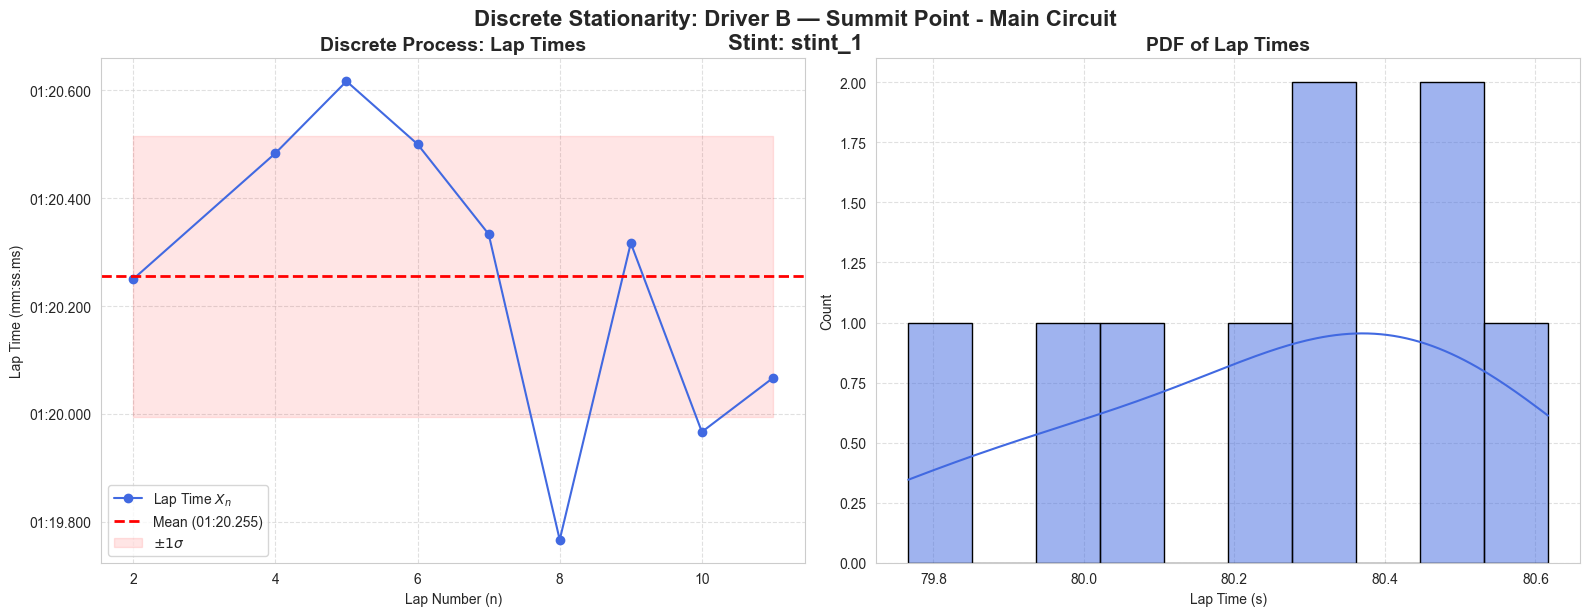

📊 Discrete Stationarity: Driver C (stint_2)
  ✅ Saved | μ=82.813s  σ=1.430s


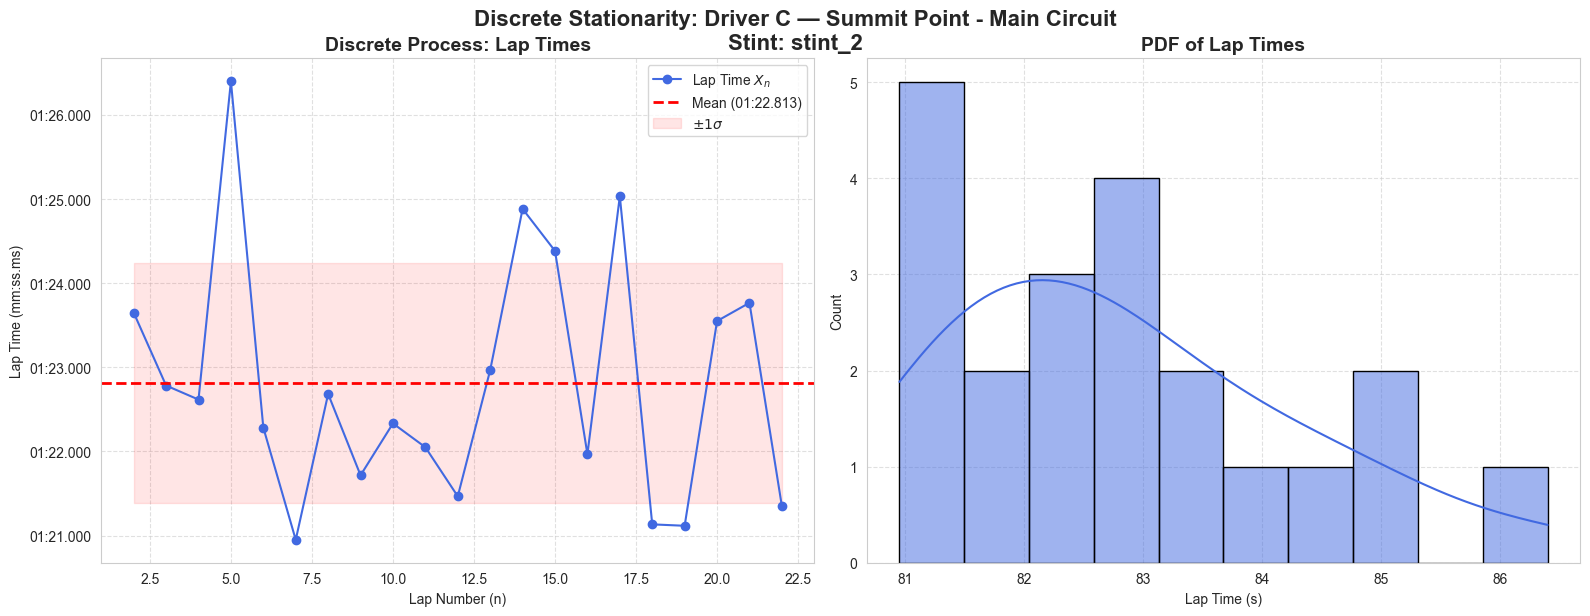

In [1022]:
pilotos_para_analise = [
    (driver_a, STINT_REF,  df_ref_clean),
    (driver_b, STINT_TEST, df_test_clean),
]

for label, stint, df in pilotos_para_analise:
    if df is None or df.empty: continue
    print(f"📊 Discrete Stationarity: {label} ({stint})")
    fig, mu, sigma = analyze_discrete_stationarity(df, COL_LAP, COL_TIME)
    fig.suptitle(f"Discrete Stationarity: {label} — {TRACK_NAME}\nStint: {stint}",
                 fontsize=16, fontweight='bold', y=1.02)
    fname = f"stationarity_{label.lower()}_{stint.lower()}_{track_id}.pdf"
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    print(f"  ✅ Saved | μ={mu:.3f}s  σ={sigma:.3f}s")
    plt.show()

## Cyclo-Stationary Analysis

### Throttle Position (%)

In [1023]:
#compare_cyclostationarity(df_ref_clean, df_test_clean,
#                           target_col='Throttle_Pct', clip_range=(0, 100))

### Brake Position (%)

In [1024]:
#compare_cyclostationarity(df_ref_clean, df_test_clean,
#                           target_col='Brake_Pct', filter_zeros=True, clip_range=(0, 100))

### Speed (km/h)

In [1025]:
#max_speed = max(df_ref_clean['Speed_KPH'].max(), df_test_clean['Speed_KPH'].max())
#compare_cyclostationarity(df_ref_clean, df_test_clean,
#                           target_col='Speed_KPH', clip_range=(0, max_speed + 10))

### Lap Time
#### Autocorrelation

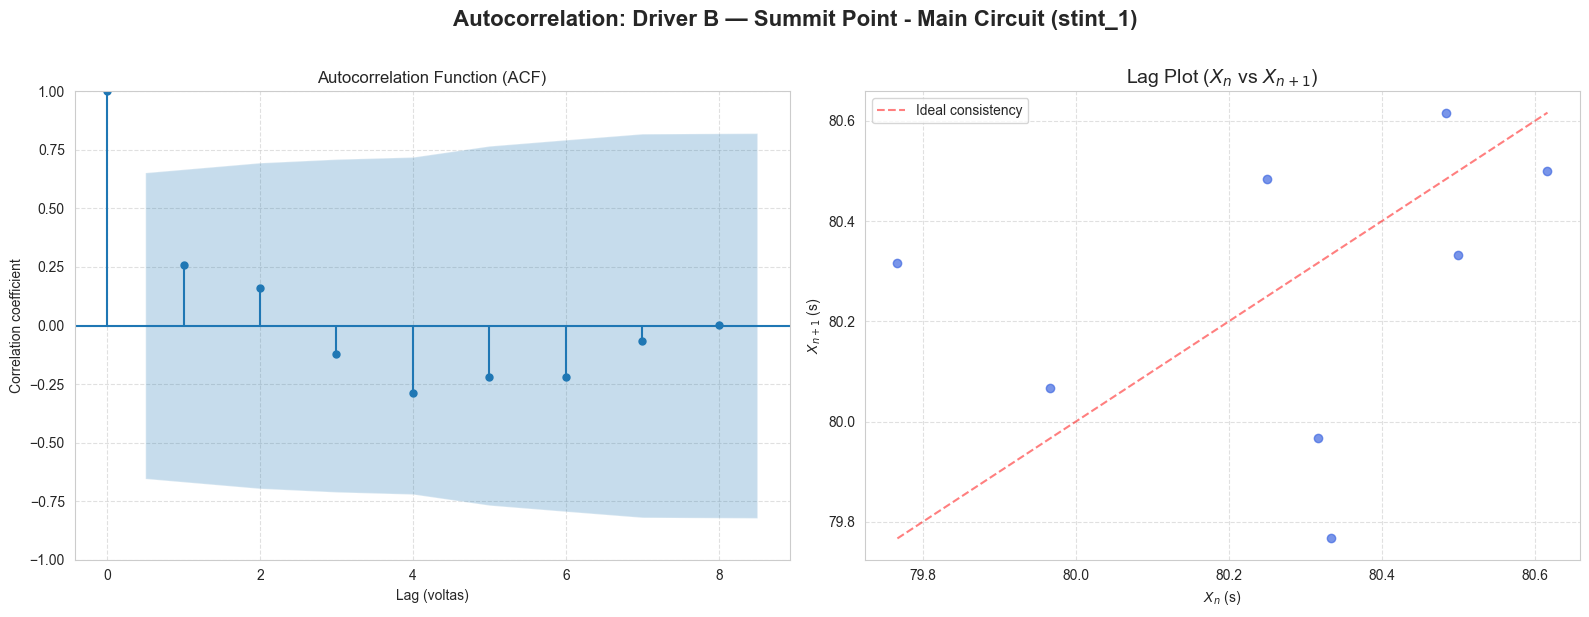

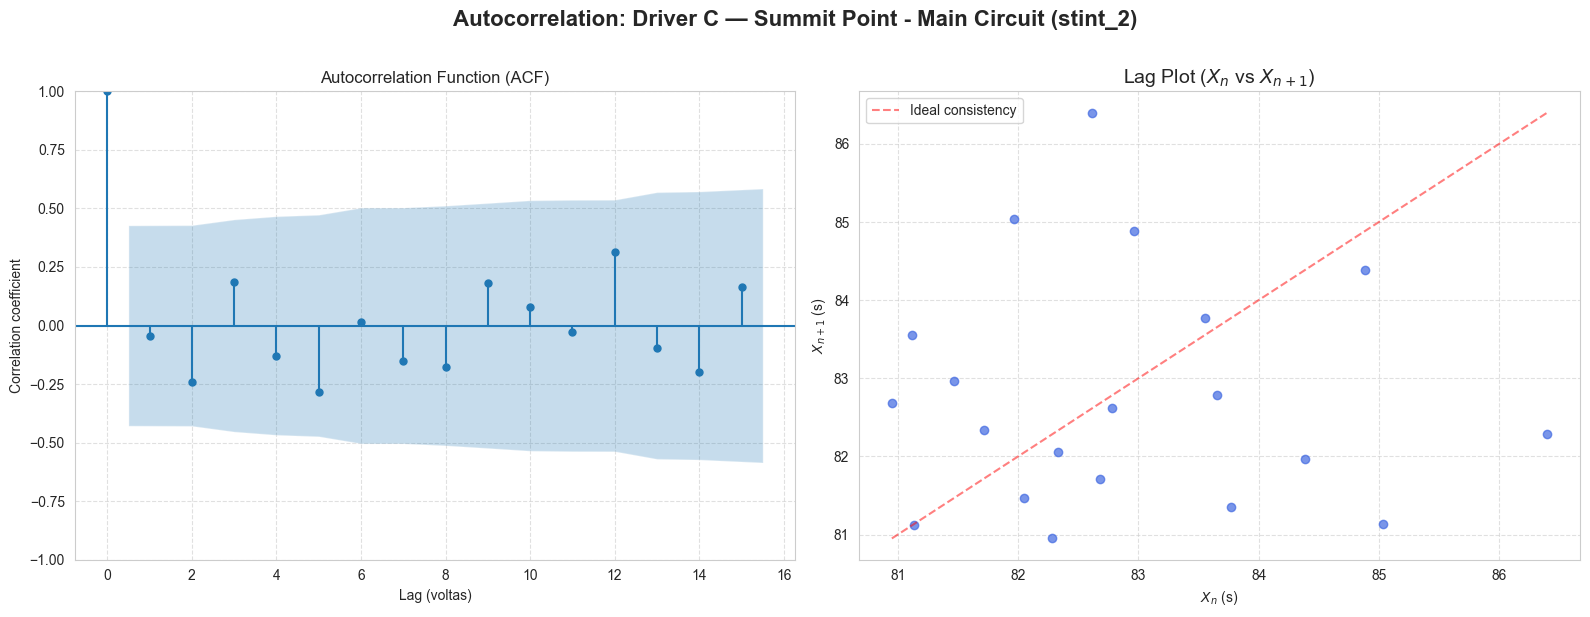

In [1026]:
from statsmodels.graphics.tsaplots import plot_acf
from pandas.plotting import lag_plot

def analyze_lap_autocorrelation(df, lap_col, time_col):
    lap_durations = df.groupby(lap_col)[time_col].apply(lambda x: x.max() - x.min())
    lap_durations = lap_durations[lap_durations > 10]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    max_lags = min(len(lap_durations) - 1, 15)
    plot_acf(lap_durations, ax=ax1, lags=max_lags, alpha=0.05,
             title='Autocorrelation Function (ACF)')
    ax1.set_xlabel('Lag (voltas)'); ax1.set_ylabel('Correlation coefficient')
    ax1.grid(True, linestyle='--', alpha=0.6)
    lag_plot(lap_durations, lag=1, ax=ax2, c='royalblue', alpha=0.7)
    ax2.set_title(r'Lag Plot ($X_n$ vs $X_{n+1}$)', fontsize=14)
    ax2.set_xlabel(r'$X_n$ (s)'); ax2.set_ylabel(r'$X_{n+1}$ (s)')
    ax2.grid(True, linestyle='--', alpha=0.6)
    min_val, max_val = lap_durations.min(), lap_durations.max()
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Ideal consistency')
    ax2.legend(); plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

for label, stint, df_clean in [(driver_a, STINT_REF, df_ref_clean),
                                (driver_b, STINT_TEST, df_test_clean)]:
    if df_clean is None or df_clean.empty: continue
    fig = analyze_lap_autocorrelation(df_clean, COL_LAP, COL_TIME)
    fig.suptitle(f"Autocorrelation: {label} — {TRACK_NAME} ({stint})",
                 fontsize=16, fontweight='bold', y=1.02)
    fname = f"autocorrelation_{label.lower()}_{stint.lower()}_{track_id}.pdf"
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

# Longitudinal and Lateral Accelerations

The G-G diagram maps the driver's use of the tyre friction circle.

$$Acc = \sqrt{A_x^2 + A_y^2}$$

In [1027]:
from matplotlib.colors import LogNorm

def analyze_gg_dynamics(df, label, stint, lat_col='LatAccel_G', long_col='LongAccel_G'):
    df = df.copy()
    for col, axis in [(lat_col, 'LatAccel'), (long_col, 'LongAccel')]:
        if col not in df.columns and axis in df.columns:
            df[col] = df[axis] / 9.81
    total_col   = 'TotalAccel_G'
    df[total_col] = np.sqrt(df[lat_col]**2 + df[long_col]**2)

    fig = plt.figure(figsize=(18, 8))
    gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.2])
    ax1 = fig.add_subplot(gs[0]); ax1.set_facecolor("#fffafa")
    ax1.scatter(df[lat_col], df[long_col], alpha=0.08, s=3, color='red', rasterized=True)
    for g_val, color, ls in [(1.0, 'white', '--'), (1.5, 'yellow', ':')]:
        ax1.add_patch(plt.Circle((0, 0), g_val, color=color, fill=False,
                                  linestyle=ls, alpha=0.5, label=f'{g_val} G'))
    limit = 2
    ax1.set_xlim(-limit, limit); ax1.set_ylim(-limit, limit); ax1.set_aspect('equal')
    ax1.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax1.axvline(0, color='gray', linestyle='-', alpha=0.3)
    ax1.set_title(f'G-G Diagram: {label} ({stint})', fontsize=15, fontweight='bold')
    ax1.set_xlabel('Lateral G'); ax1.set_ylabel('Longitudinal G')
    ax1.legend(loc='upper right', facecolor='black', labelcolor='white', framealpha=0.6)

    ax2 = fig.add_subplot(gs[1])
    sns.histplot(df[total_col], bins=60, kde=True, ax=ax2, color='crimson',
                 stat='density', alpha=0.6)
    max_g = df[total_col].quantile(0.995)
    ax2.axvline(max_g, color='black', linestyle='--', label=f'Grip peak (~{max_g:.2f} G)')
    ax2.set_title(r'Combined Load Distribution ($A = \sqrt{A_x^2 + A_y^2}$)',
                  fontsize=15, fontweight='bold')
    ax2.set_xlabel('Total Acceleration (G)'); ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.3); ax2.set_xlim(0, 3.0)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

"""
for label, stint, df_clean in [(driver_a, STINT_REF, df_ref_clean),
                                (driver_b, STINT_TEST, df_test_clean)]:
    if df_clean is None or df_clean.empty: continue
    fig = analyze_gg_dynamics(df_clean, label, stint)
    fig.suptitle(f"Tyre Dynamics & Grip Envelope — {TRACK_NAME}",
                 fontsize=16, fontweight='bold', y=1.02)
    fname = f"gg_dynamics_{label.lower()}_{stint.lower()}_{track_id}.pdf"
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()
"""    

'\nfor label, stint, df_clean in [(driver_a, STINT_REF, df_ref_clean),\n                                (driver_b, STINT_TEST, df_test_clean)]:\n    if df_clean is None or df_clean.empty: continue\n    fig = analyze_gg_dynamics(df_clean, label, stint)\n    fig.suptitle(f"Tyre Dynamics & Grip Envelope — {TRACK_NAME}",\n                 fontsize=16, fontweight=\'bold\', y=1.02)\n    fname = f"gg_dynamics_{label.lower()}_{stint.lower()}_{track_id}.pdf"\n    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches=\'tight\')\n    plt.show()\n'

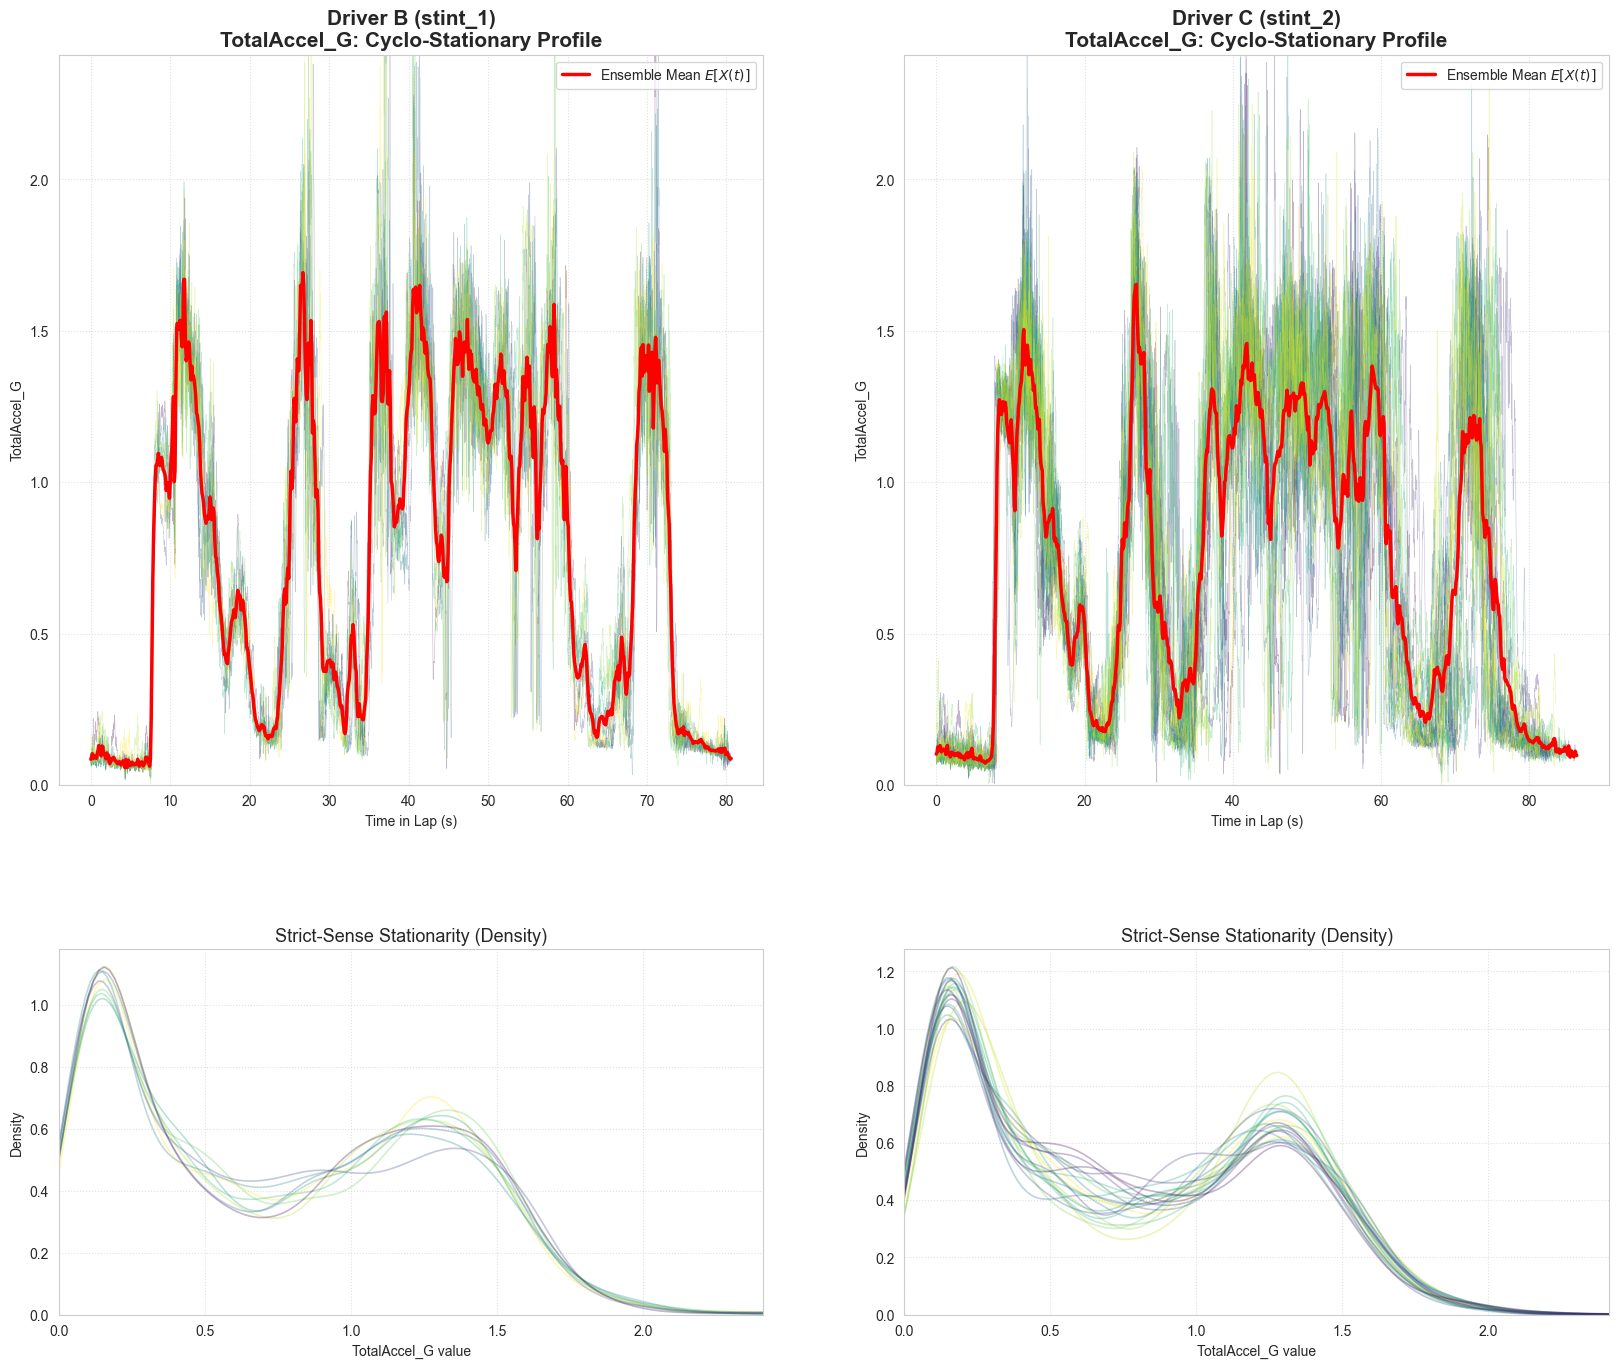

In [1028]:
COL_VAR = 'TotalAccel_G'
for label, df in [("Ref", df_ref_clean), ("Test", df_test_clean)]:
    if COL_VAR not in df.columns:
        if 'LatAccel_G' in df.columns and 'LongAccel_G' in df.columns:
            df[COL_VAR] = np.sqrt(df['LatAccel_G']**2 + df['LongAccel_G']**2)
        else:
            df[COL_VAR] = np.sqrt((df['LatAccel']/9.81)**2 + (df['LongAccel']/9.81)**2)

compare_cyclostationarity(df_ref_clean, df_test_clean,
                           target_col=COL_VAR, filter_zeros=False, clip_range=None)

# Variance (Temporal Uncertainty)

📊 Variance Profile (σ): TotalAccel_G


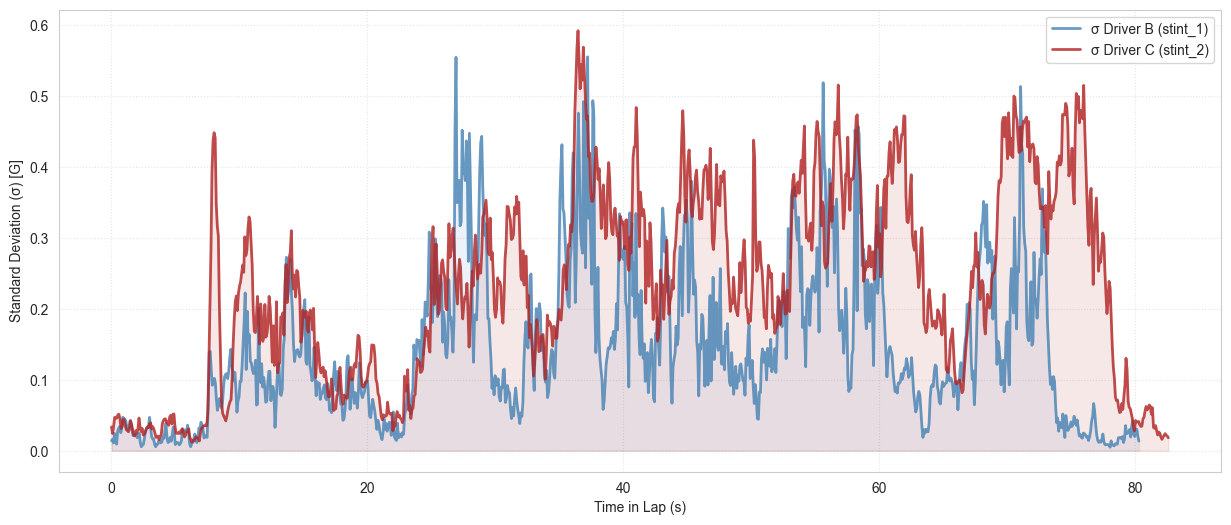

📊 Variance Profile (σ): Throttle_Pct


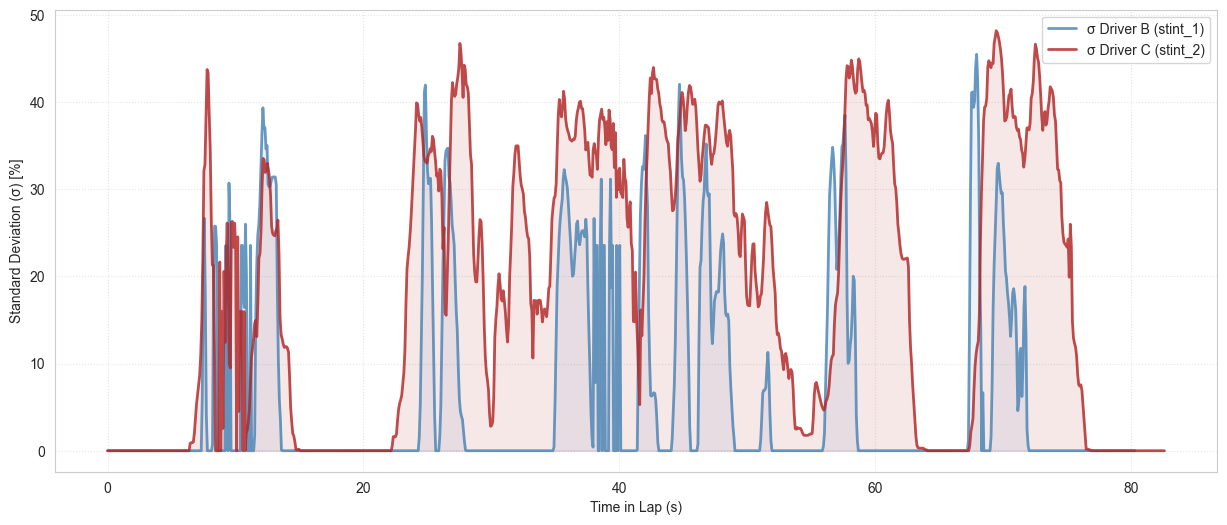

📊 Variance Profile (σ): Brake_Pct


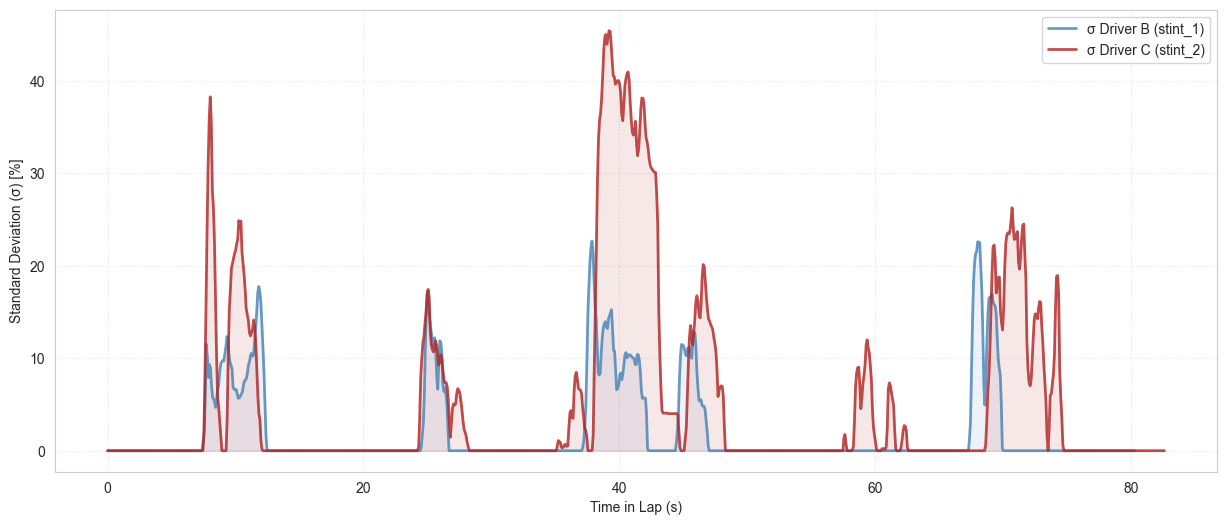

📊 Variance Profile (σ): Speed_KPH


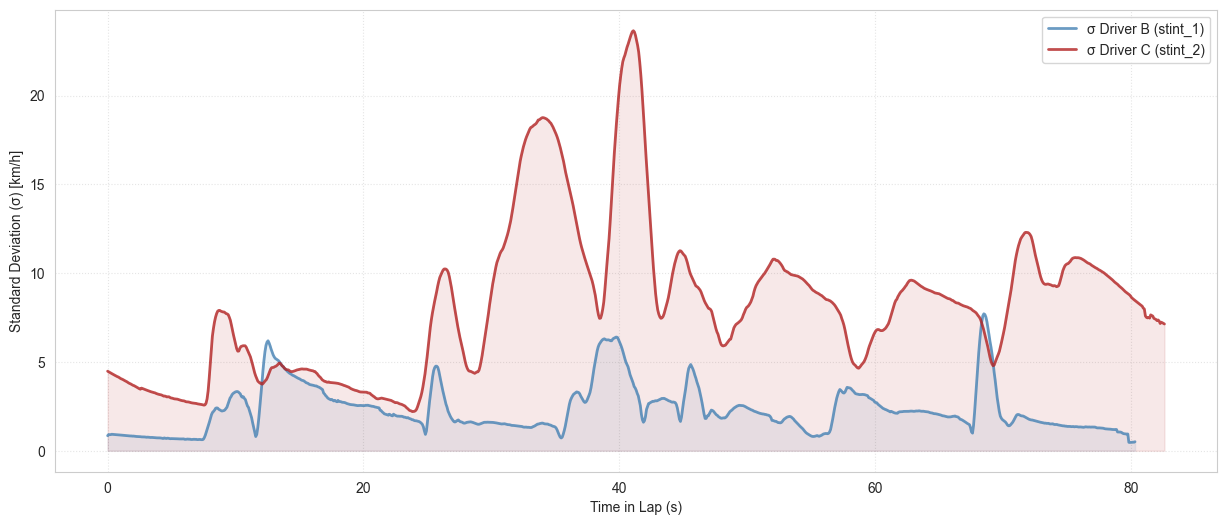

📊 Variance Profile (σ): SteeringWheelAngle


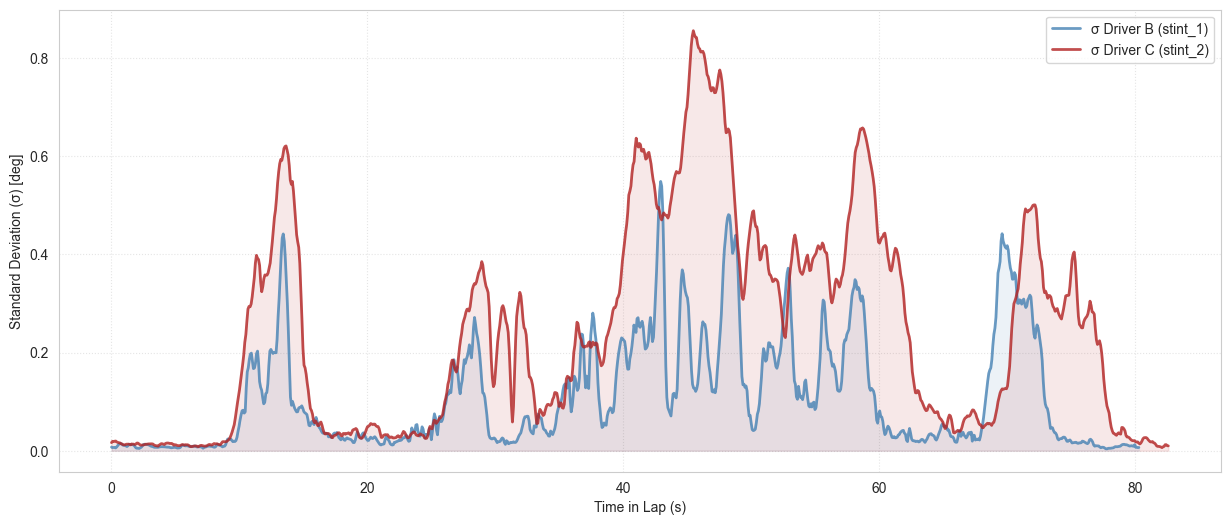

In [1029]:
def plot_comparative_variance(df_ref, df_test, target_col, y_label, unit=""):
    print(f"📊 Variance Profile (σ): {target_col}")

    def get_sigma(df):
        if df is None or df.empty: return None, None
        lap_times   = df.groupby('Lap')['SessionTime'].apply(lambda x: x.max() - x.min())
        common_time = np.linspace(0, lap_times.median(), 1000)
        matrix = []
        for lap in df['Lap'].unique():
            ld = df[df['Lap'] == lap].sort_values('SessionTime')
            if len(ld) > 10:
                t_z = ld['SessionTime'] - ld['SessionTime'].iloc[0]
                matrix.append(np.interp(common_time, t_z, ld[target_col].values, right=np.nan))
        if not matrix: return None, None
        return common_time, np.nanstd(np.array(matrix), axis=0)

    t_ref, s_ref   = get_sigma(df_ref)
    t_test, s_test = get_sigma(df_test)
    fig, ax = plt.subplots(figsize=(15, 6))
    if s_ref  is not None:
        ax.plot(t_ref,  s_ref,  color='steelblue',  lw=2, alpha=0.8,
                label=f'σ {driver_a} ({STINT_REF})')
        ax.fill_between(t_ref,  0, s_ref,  color='steelblue',  alpha=0.1)
    if s_test is not None:
        ax.plot(t_test, s_test, color='firebrick', lw=2, alpha=0.8,
                label=f'σ {driver_b} ({STINT_TEST})')
        ax.fill_between(t_test, 0, s_test, color='firebrick', alpha=0.1)
    ax.set_xlabel('Time in Lap (s)'); ax.set_ylabel(f'Standard Deviation (σ) [{unit}]')
    ax.legend(); ax.grid(True, linestyle=':', alpha=0.5)
    fname = (f"variance_{target_col.lower()}"
             f"_{driver_a}_{STINT_REF}_vs_{driver_b}_{STINT_TEST}_{track_id}.pdf")
    plt.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

variables_var = [
    ('TotalAccel_G',       'Combined G-Force',   'G'),
    ('Throttle_Pct',       'Throttle',           '%'),
    ('Brake_Pct',          'Brake',              '%'),
    ('Speed_KPH',          'Speed',              'km/h'),
    ('SteeringWheelAngle', 'Steering Angle',     'deg'),
]
for col, label, unit in variables_var:
    if col in df_ref_clean.columns or col in df_test_clean.columns:
        plot_comparative_variance(df_ref_clean, df_test_clean, col, label, unit)

---
# ENTROPIA — v2

Esta seção implementa uma análise de entropia completa com cinco camadas progressivas:

| # | Análise | Responde |
|---|---------|---------|
| 0 | Utilitários adaptativos (FD bins) | Base metodológica correta |
| 1 | Ranges globais | Comparabilidade entre drivers/circuitos |
| 2 | Shannon H_norm ∈ [0, 1] | Complexidade por variável ao longo da volta |
| 3 | Tabela JSD + KL | *Quão diferentes* são as distribuições? |
| 4 | Perfil JSD temporal | *Quando* na volta divergem mais? |
| 5 | Mapa espacial JSD | *Onde* no circuito divergem mais? |
| 6 | Mapa de calor H | Complexidade georreferenciada |
| 7 | Correlação H_norm vs Δt | Entropia prediz performance? |
| 8 | Entropia de permutação | Robustez para setores não-estacionários |
| 9 | Entropia de transferência | Acoplamento freio→direção (marcador expert) |
| 10 | Testes estatísticos | Diferenças são significativas? |
| 11 | Tabela resumo | Todas as métricas consolidadas |

## 0. Utilitários: Bins Adaptativos e Divergências

In [1030]:
# ═══════════════════════════════════════════════════════════════════════
# v2.0  Adaptive binning + information-theoretic divergence utilities
# ═══════════════════════════════════════════════════════════════════════

def freedman_diaconis_bins(data: np.ndarray, v_min: float, v_max: float,
                            min_bins: int = 5, max_bins: int = 100) -> int:
    """
    Freedman–Diaconis rule:  bin_width = 2 · IQR · n^(-1/3)
    Advantages over fixed bins:
      - Adapts to sample size (fewer laps → fewer bins, more honest)
      - Adapts to data spread (wide IQR → coarser bins, avoids overfitting)
    Falls back to √n (Rice rule) if IQR = 0.
    """
    data = data[np.isfinite(data)]
    n    = len(data)
    if n < 4:
        return min_bins
    iqr = np.percentile(data, 75) - np.percentile(data, 25)
    if iqr > 0:
        bin_width = 2.0 * iqr * (n ** (-1.0 / 3.0))
        n_bins    = int(np.ceil((v_max - v_min) / bin_width))
    else:
        n_bins = max(min_bins, int(np.ceil(np.sqrt(n))))
    return int(np.clip(n_bins, min_bins, max_bins))


def pmf(data: np.ndarray, n_bins: int, v_range: tuple,
        smoothing: float = 1e-8) -> np.ndarray:
    """
    Probability Mass Function via histogram.

    NOTE: uses density=False (raw counts) then normalises → correct PMF.
    The original v1 code used density=True (probability density, not mass),
    which causes scipy_entropy() to renormalise implicitly and lose the
    information about bin width — fixed here.
    """
    counts, _ = np.histogram(data[np.isfinite(data)], bins=n_bins, range=v_range)
    counts    = counts.astype(float) + smoothing   # Laplace smoothing → no log(0)
    return counts / counts.sum()


def compute_jsd(data_a: np.ndarray, data_b: np.ndarray,
                v_range: tuple) -> tuple:
    """
    Jensen–Shannon Divergence ∈ [0, 1]  (log base-2 / bits).

    JSD = 0  →  identical distributions (same driving pattern)
    JSD = 1  →  completely disjoint distributions (impossible in practice)
    Typical racing range: expert vs novice ~ 0.15–0.45

    scipy.jensenshannon returns JS *distance* = √JSD;
    squaring gives JS *divergence* ∈ [0, 1].

    Returns (jsd_divergence, n_bins_used)
    """
    pooled = np.concatenate([data_a[np.isfinite(data_a)],
                              data_b[np.isfinite(data_b)]])
    n_bins = freedman_diaconis_bins(pooled, *v_range)
    p      = pmf(data_a, n_bins, v_range)
    q      = pmf(data_b, n_bins, v_range)
    jsd_d  = float(jensenshannon(p, q, base=2) ** 2)
    return jsd_d, n_bins


def compute_kl(data_ref: np.ndarray, data_test: np.ndarray,
               v_range: tuple) -> tuple:
    """
    KL Divergence  D_KL(test ∥ ref) ∈ [0, ∞)  (base-2 / bits).
    Asymmetric: measures how much *test* distribution diverges from *ref*.
    Use alongside JSD (symmetric) for directional insight.
    """
    pooled = np.concatenate([data_ref[np.isfinite(data_ref)],
                              data_test[np.isfinite(data_test)]])
    n_bins = freedman_diaconis_bins(pooled, *v_range)
    p_ref  = pmf(data_ref,  n_bins, v_range)
    p_test = pmf(data_test, n_bins, v_range)
    return float(scipy_entropy(p_test, p_ref, base=2)), n_bins


def compute_shannon_normalized(data: np.ndarray, v_range: tuple) -> tuple:
    """
    Normalised Shannon entropy:  H_norm = H / log2(n_bins) ∈ [0, 1]

    H_norm = 0  →  fully deterministic (e.g. always full throttle)
    H_norm = 1  →  perfectly uniform distribution (maximum complexity)

    Normalisation allows comparison between:
      - Different sectors (varying sample size → different FD bins)
      - Different circuits (Charlotte 18 sectors vs Summit 10 sectors)
      - Different signals (throttle vs steering have different scales)

    Returns (H_norm, H_bits, n_bins)
    """
    clean  = data[np.isfinite(data)]
    n_bins = freedman_diaconis_bins(clean, *v_range)
    p      = pmf(clean, n_bins, v_range)
    h_bits = float(scipy_entropy(p, base=2))
    h_max  = float(np.log2(n_bins))
    h_norm = h_bits / h_max if h_max > 0 else 0.0
    return h_norm, h_bits, n_bins

print("✅ v2 entropy utilities loaded")
print("   Functions: freedman_diaconis_bins | pmf | compute_jsd | compute_kl | compute_shannon_normalized")

✅ v2 entropy utilities loaded
   Functions: freedman_diaconis_bins | pmf | compute_jsd | compute_kl | compute_shannon_normalized


## 1. Global Ranges

Computed once from **all** stints/drivers so that every histogram uses the same
support — mandatory for cross-driver comparability of JSD and H_norm.

In [1031]:
VARIABLES_ENTROPY = [
    ('TotalAccel_G',       'Combined G-Force'),
    ('Throttle_Pct',       'Throttle (%)'),
    ('Brake_Pct',          'Brake (%)'),
    ('SteeringWheelAngle', 'Steering Angle (°)'),
]

def compute_global_ranges(datasets: dict, variables: list,
                           track_filter: str = None,
                           lower_pct: float = 1,
                           upper_pct: float = 99) -> dict:
    col_values = {col: [] for col, _ in variables}
    for track_key, track_info in datasets.items():
        if track_filter and track_key != track_filter:
            continue
        base_path = Path(track_info["base_path"])
        for pilot, stints in track_info["sessions"].items():
            for stint_key, filenames in stints.items():
                if isinstance(filenames, str): filenames = [filenames]
                filepaths = [base_path / f for f in filenames]
                try:
                    df_raw = load_from_ibt(filepaths)
                    if df_raw.empty: continue
                    df_tmp = basic_clean_and_units(df_raw)
                    if 'TotalAccel_G' not in df_tmp.columns:
                        df_tmp['TotalAccel_G'] = np.sqrt(
                            (df_tmp['LatAccel']/9.81)**2 + (df_tmp['LongAccel']/9.81)**2)
                    for col, _ in variables:
                        if col in df_tmp.columns:
                            col_values[col].append(df_tmp[col].dropna().values)
                    print(f"  ✅ {track_key} | {pilot} | {stint_key}")
                except Exception as e:
                    print(f"  ⚠  {track_key} | {pilot} | {stint_key} — {e}")

    global_ranges = {}
    for col, _ in variables:
        if col_values[col]:
            all_vals = np.concatenate(col_values[col])
            v_min, v_max = np.percentile(all_vals, [lower_pct, upper_pct])
            global_ranges[col] = (v_min, v_max)
            print(f"  Range '{col}': [{v_min:.3f} — {v_max:.3f}]")
        else:
            print(f"  ⚠  No data for '{col}'")
    return global_ranges

print("📐 Computing global ranges from all stints...")
global_ranges = compute_global_ranges(DATASETS, VARIABLES_ENTROPY, track_filter=TRACK)

📐 Computing global ranges from all stints...
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)
  ✅ summit_point | Tomaz | stint_1
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-28 16-03-13(Morsinaldo).ibt … OK (21,775 samples, laps 2–7)
  ✅ summit_point | Morsinaldo | stint_1
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-30 08-56-59(Morsinaldo).ibt … OK (109,117 samples, laps 1–23)
  ✅ summit_point | Morsinaldo | stint_2
    [1/2] Loading toyotagr86_summit summit raceway 2026-03-01 22-00-14(Rodrigo).ibt … OK (46,538 samples, laps 0–32)
    [2/2] Loading toyotagr86_summit summit raceway 2026-03-01 21-47-29(Rodrigo).ibt … OK (44,508 samples, laps 33–52)
  ✅ summit_point | Rodrigo | stint_1
  Range 'TotalAccel_G': [0.051 — 1.843]
  Range 'Throttle_Pct': [0.000 — 100.000]
  Range 'Brake_Pct': [0.000 — 100.000]
  Range 'SteeringWheelAngle': [-1.841 — 1.664]


## 2. Shannon Entropy Profile H_norm ∈ [0, 1]

**v1 bug fixed:** previous version used `density=True` in `np.histogram`, which
returns a probability *density* (area = 1), not a probability *mass* (sum = 1).
`scipy.stats.entropy` requires a PMF.  The fix uses `density=False` + manual
normalisation via the `pmf()` utility above.

H_norm is normalised by H_max = log₂(n_bins) so values are comparable across
sectors with different sample sizes.

🧬 H_norm profile: TotalAccel_G


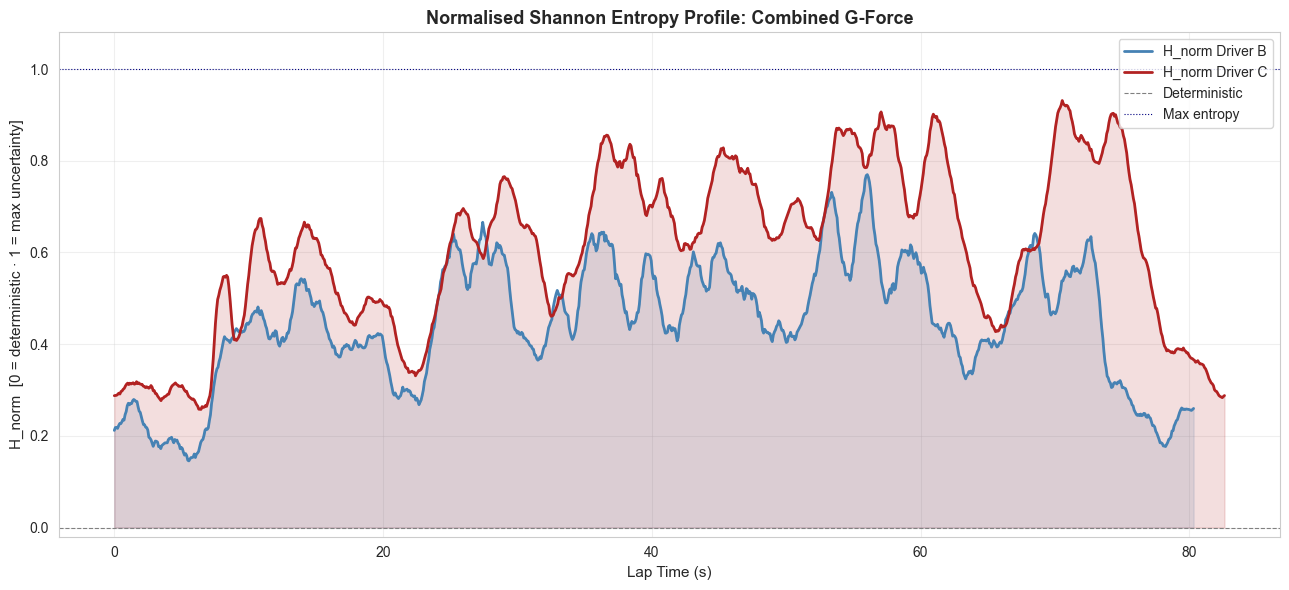

🧬 H_norm profile: Throttle_Pct


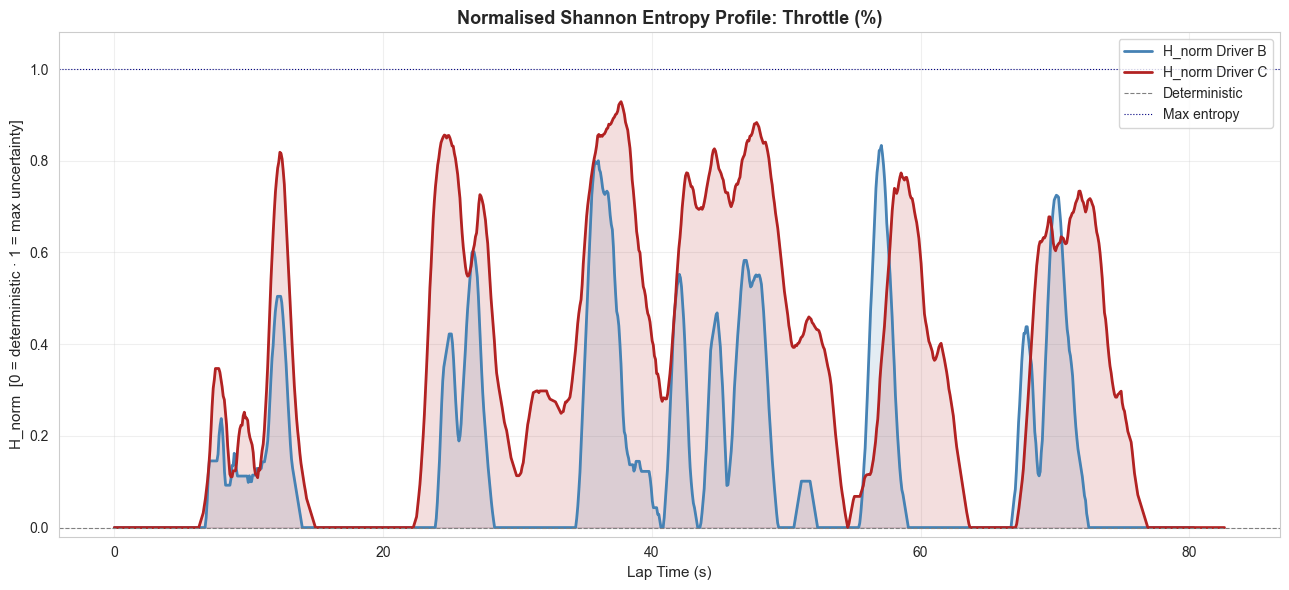

🧬 H_norm profile: Brake_Pct


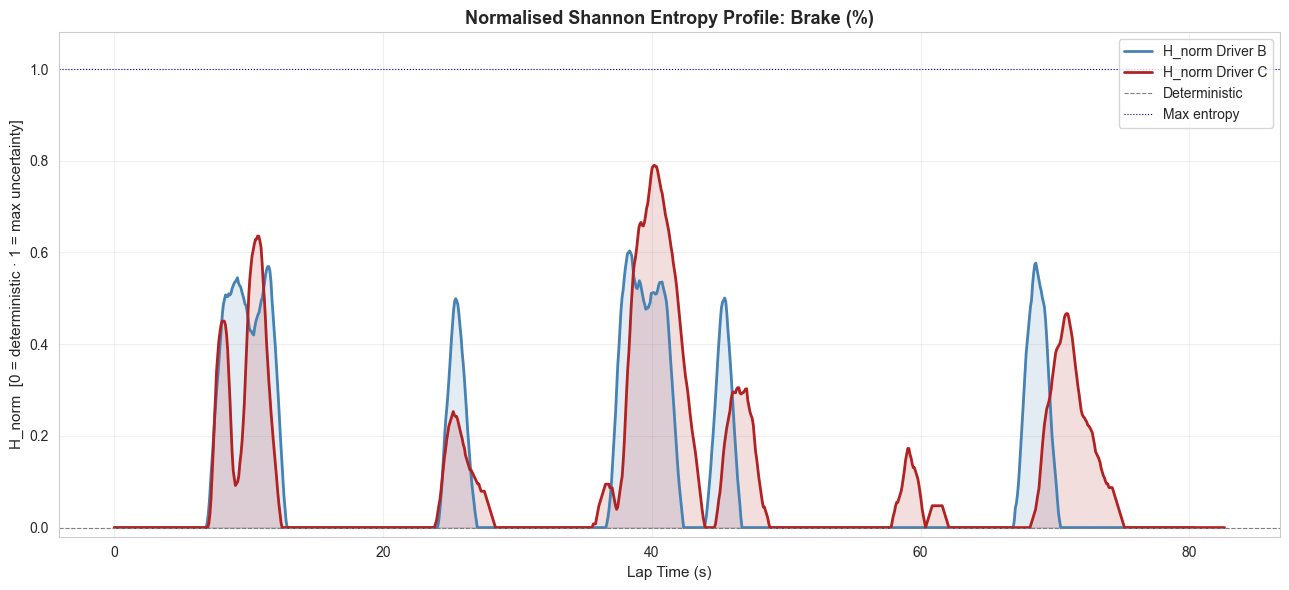

🧬 H_norm profile: SteeringWheelAngle


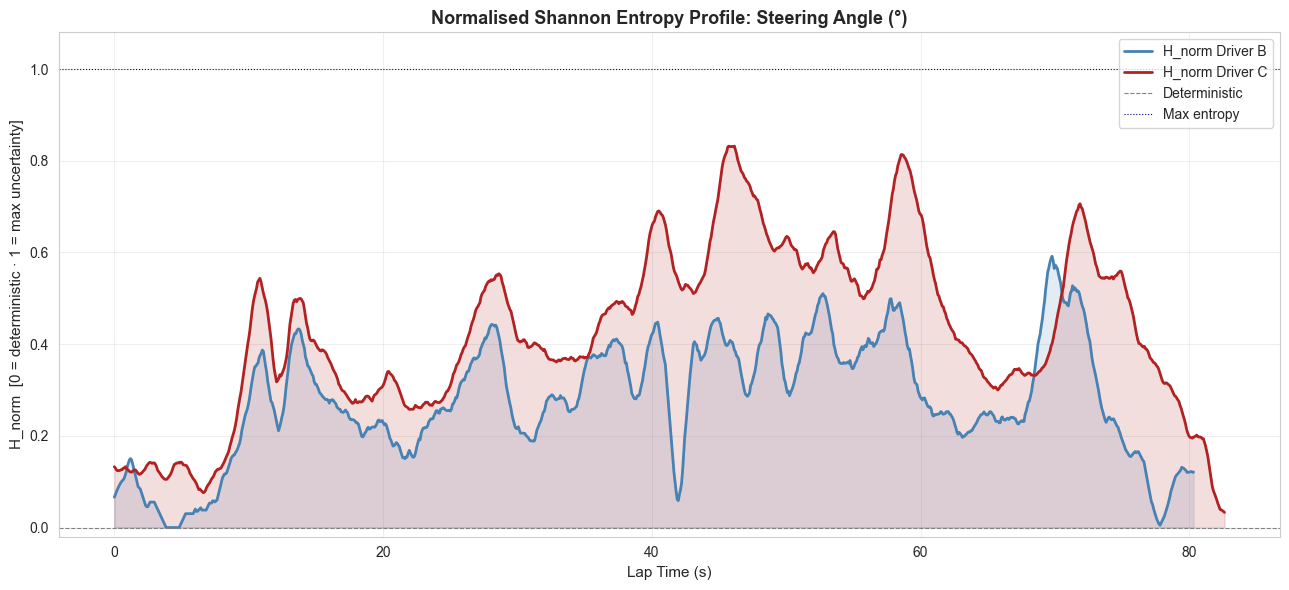

In [1032]:
def plot_comparative_entropy_normalized(df_ref, df_test, target_col, y_label,
                                       smooth_window=15, global_range=None):
    """
    Shannon entropy profile over the lap  — H_norm ∈ [0, 1].
    Uses FD-adaptive bin count at each time slice.
    """
    print(f"🧬 H_norm profile: {target_col}")

    if global_range is None:
        combined  = pd.concat([df_ref[target_col], df_test[target_col]], ignore_index=True)
        v_min, v_max = np.percentile(combined, 1), np.percentile(combined, 99)
    else:
        v_min, v_max = global_range

    def get_profile(df):
        if df is None or df.empty: return None, None
        lap_times   = df.groupby('Lap')['SessionTime'].apply(lambda x: x.max() - x.min())
        common_time = np.linspace(0, lap_times.median(), 1000)
        matrix = []
        for lap in df['Lap'].unique():
            ld = df[df['Lap'] == lap].sort_values('SessionTime')
            if len(ld) > 10:
                t_z = ld['SessionTime'] - ld['SessionTime'].iloc[0]
                matrix.append(np.interp(common_time, t_z, ld[target_col].values, right=np.nan))
        if not matrix: return None, None
        matrix = np.array(matrix)
        h_profile = []
        for t_idx in range(matrix.shape[1]):
            sl = matrix[:, t_idx]; sl = sl[~np.isnan(sl)]
            if len(sl) > 2:
                h_n, _, _ = compute_shannon_normalized(sl, (v_min, v_max))
                h_profile.append(h_n)
            else:
                h_profile.append(np.nan)
        h_s = (pd.Series(h_profile)
                 .rolling(smooth_window, center=True, min_periods=1).mean().values)
        return common_time, h_s

    t_ref,  h_ref  = get_profile(df_ref)
    t_test, h_test = get_profile(df_test)

    fig, ax = plt.subplots(figsize=(13, 6))
    if h_ref is not None:
        ax.plot(t_ref,  h_ref,  color='steelblue',  lw=2, label=f'H_norm {driver_a}')
        ax.fill_between(t_ref,  0, h_ref,  color='steelblue',  alpha=0.15)
    if h_test is not None:
        ax.plot(t_test, h_test, color='firebrick', lw=2, label=f'H_norm {driver_b}')
        ax.fill_between(t_test, 0, h_test, color='firebrick', alpha=0.15)

    ax.axhline(0, color='gray', ls='--', lw=0.8, label='Deterministic')
    ax.axhline(1, color='navy', ls=':', lw=0.8, label='Max entropy')
    ax.set_ylim(-0.02, 1.08)
    ax.set_ylabel('H_norm  [0 = deterministic · 1 = max uncertainty]', fontsize=11)
    ax.set_xlabel('Lap Time (s)', fontsize=11)
    ax.set_title(f'Normalised Shannon Entropy Profile: {y_label}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = (f"entropy_hnorm_{target_col.lower()}"
             f"_{driver_a}_{STINT_REF}_vs_{driver_b}_{STINT_TEST}_{TRACK}.pdf")
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

for col, label in VARIABLES_ENTROPY:
    if col in df_ref_clean.columns:
        plot_comparative_entropy_normalized(
            df_ref_clean, df_test_clean, col, label,
            global_range=global_ranges.get(col))

## 3. Mean Entropy H̄_norm per Driver / Stint

In [1033]:
def compute_mean_entropy_table(datasets, variables, global_ranges_dict,
                               track_filter=None):
    rows = []
    for track_key, track_info in datasets.items():
        if track_filter and track_key != track_filter: continue
        base_path = Path(track_info["base_path"])
        for pilot, stints in track_info["sessions"].items():
            alias = DRIVER_ALIAS.get(pilot, pilot)
            for stint_key, filenames in stints.items():
                if isinstance(filenames, str): filenames = [filenames]
                filepaths = [base_path / f for f in filenames]
                try:
                    df_raw = load_from_ibt(filepaths)
                    if df_raw.empty: continue
                    df_tmp = basic_clean_and_units(df_raw)
                    df_tmp.sort_values(['Lap', 'SessionTime'], inplace=True)
                    if 'TotalAccel_G' not in df_tmp.columns:
                        df_tmp['TotalAccel_G'] = np.sqrt(
                            (df_tmp['LatAccel']/9.81)**2 + (df_tmp['LongAccel']/9.81)**2)
                    validity    = build_lap_validity_table(df_tmp)
                    valid_laps  = validity[validity['Valid']]['Lap'].tolist()
                    df_clean    = df_tmp[df_tmp['Lap'].isin(valid_laps)].copy()
                    if df_clean.empty: continue
                    row = {'Driver': alias, 'Stint': stint_key, 'Valid Laps': len(valid_laps)}
                    for col, col_label in variables:
                        v_range = global_ranges_dict.get(col)
                        if v_range is None or col not in df_clean.columns:
                            row[f'H_norm {col_label}'] = np.nan; continue
                        lap_h = []
                        for lap in valid_laps:
                            d = df_clean[df_clean['Lap'] == lap][col].dropna().values
                            if len(d) > 5:
                                h_n, _, _ = compute_shannon_normalized(d, v_range)
                                lap_h.append(h_n)
                        row[f'H_norm {col_label}'] = round(np.mean(lap_h), 4) if lap_h else np.nan
                    rows.append(row)
                except Exception as e:
                    print(f"  ⚠  {pilot} {stint_key}: {e}")
    return pd.DataFrame(rows)

df_mean_h = compute_mean_entropy_table(DATASETS, VARIABLES_ENTROPY, global_ranges, TRACK)
print("\n📊 Mean H_norm by driver/stint (FD bins, density=False):")
display(df_mean_h)

    [1/1] Loading toyotagr86_summit summit raceway 2026-01-27 22-21-35.ibt … OK (60,130 samples, laps 0–12)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (13 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 9 laps
  🏆 Fastest : Lap 8  (01:19.767)
  ❌ Invalid : 4 laps
     Lap   0  16:39.700  → LapTime=999.7s | GPS=27.0%<100%
     Lap   1  01:22.067  → IQR_outlier
     Lap   3  01:22.783  → IQR_outlier
     Lap  12  01:22.633  → CompletedPct=0.938<0.995 | GPS=94.0%<100%
──────────────────────────────────────────────────────────────
    [1/1] Loading toyotagr86_summit summit raceway 2026-01-28 16-03-13(Morsinaldo).ibt … OK (21,775 samples, laps 2–7)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (6 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 4 laps
  🏆 Fastest : Lap 6  (01:22.500)
  ❌ Invalid : 2 laps
     Lap   2  00:19.800  

,Driver,Stint,Valid Laps,H_norm Combined G-Force,H_norm Throttle (%),H_norm Brake (%),H_norm Steering Angle (°)
0,Driver B,stint_1,9,0.9330,0.3321,0.2475,0.7713
1,Driver C,stint_1,4,0.9370,0.5008,0.2087,0.7561
2,Driver C,stint_2,21,0.9319,0.4754,0.1631,0.7707
3,Driver A,stint_1,13,0.9109,0.2882,0.2217,0.7653


## 4. Distribuição Global — Tabela JSD + KL

**JSD ∈ [0, 1]** (simétrico, base-2):
- < 0.10 → baixa divergência (pilotagem similar)
- 0.10–0.30 → divergência moderada
- > 0.30 → alta divergência (diferença de técnica significativa)

**KL D(test ∥ ref) ∈ [0, ∞)** (assimétrico): mede quanto o piloto teste
diverge do referência.

In [1034]:
print(f"{'Variable':<22} {'FD Bins':>8} {'JSD [0–1]':>12} {'KL(test∥ref)':>14} "
      f"{'H_norm Ref':>12} {'H_norm Test':>12}  Divergence Level")
print("─" * 92)

df_divergence_rows = []
for col, label in VARIABLES_ENTROPY:
    v_range = global_ranges.get(col)
    if v_range is None or col not in df_ref_clean.columns:
        print(f"  ⚠  {label}: skipped"); continue

    arr_ref  = df_ref_clean[col].dropna().values
    arr_test = df_test_clean[col].dropna().values

    js_val, n_bins        = compute_jsd(arr_ref, arr_test, v_range)
    kl_val, _             = compute_kl(arr_ref, arr_test, v_range)
    h_r_n, h_r, _        = compute_shannon_normalized(arr_ref,  v_range)
    h_t_n, h_t, _        = compute_shannon_normalized(arr_test, v_range)

    level = ("🟢 LOW"   if js_val < 0.10 else
             "🟡 MOD"   if js_val < 0.30 else "🔴 HIGH")

    print(f"{label:<22} {n_bins:>8} {js_val:>12.4f} {kl_val:>14.4f} "
          f"{h_r_n:>12.4f} {h_t_n:>12.4f}  {level}")
    df_divergence_rows.append({'Variable': label, 'FD Bins': n_bins,
        'JSD': round(js_val, 4), 'KL D(test∥ref)': round(kl_val, 4),
        'H_norm Ref': round(h_r_n, 4), 'H_norm Test': round(h_t_n, 4)})

df_divergence = pd.DataFrame(df_divergence_rows)
print("─" * 92)
print(f"  JSD: 0 = identical · 1 = fully disjoint")
print(f"  KL is directional (unbounded)")
display(df_divergence)

Variable                FD Bins    JSD [0–1]   KL(test∥ref)   H_norm Ref  H_norm Test  Divergence Level
────────────────────────────────────────────────────────────────────────────────────────────
Combined G-Force             47       0.0038         0.0149       0.9472       0.9500  🟢 LOW
Throttle (%)                 62       0.0125         0.0572       0.3082       0.4371  🟢 LOW
Brake (%)                   100       0.0409         0.2700       0.2483       0.1625  🟢 LOW
Steering Angle (°)          100       0.0125         0.0541       0.7910       0.8015  🟢 LOW
────────────────────────────────────────────────────────────────────────────────────────────
  JSD: 0 = identical · 1 = fully disjoint
  KL is directional (unbounded)


,Variable,FD Bins,JSD,KL D(test∥ref),H_norm Ref,H_norm Test
0,Combined G-Force,47,0.0038,0.0149,0.9472,0.9500
1,Throttle (%),62,0.0125,0.0572,0.3082,0.4371
2,Brake (%),100,0.0409,0.2700,0.2483,0.1625
3,Steering Angle (°),100,0.0125,0.0541,0.7910,0.8015


### 4.1 - Perfil por Setor

✅ Setores detectados: 10 / 10
   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Sector             Variable                Bins      JSD       KL   H_ref  H_test       ΔH  Level
───────────────────────────────────────────────────────────────────────────────────────────────
1                  Combined G-Force         100   0.0781   0.6151  0.3531  0.4088   0.0557  🟢 LOW
1                  Throttle (%)             100   0.0000   0.0000  0.0000  0.0000  -0.0000  🟢 LOW
1                  Brake (%)                100   0.0000   0.0000  0.0000  0.0000  -0.0000  🟢 LOW
1                  Steering Angle (°)       100   0.0222   0.1734  0.0811  0.1383   0.0572  🟢 LOW

2                  Combined G-Force          42   0.0476   0.1999  0.9173  0.8864  -0.0310  🟢 LOW
2                  Throttle (%)              14   0.0096   0.0438  0.4699  0.5198   0.0499  🟢 LOW
2                  Brake (%)                 30   0.1692   6.1861  0.6217  0.3885  -0.2333  🟡 MOD
2                  Steering Angle (°)        49   0.0

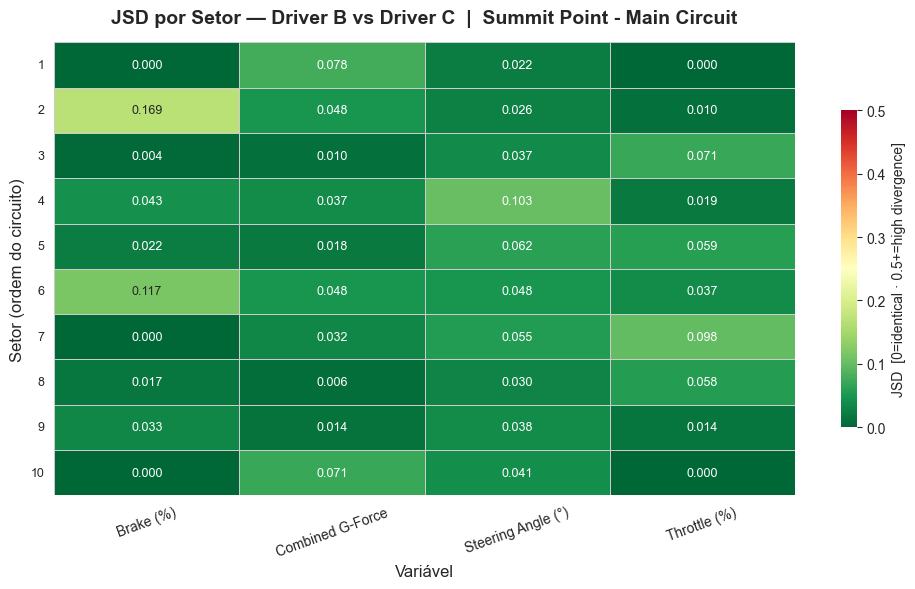

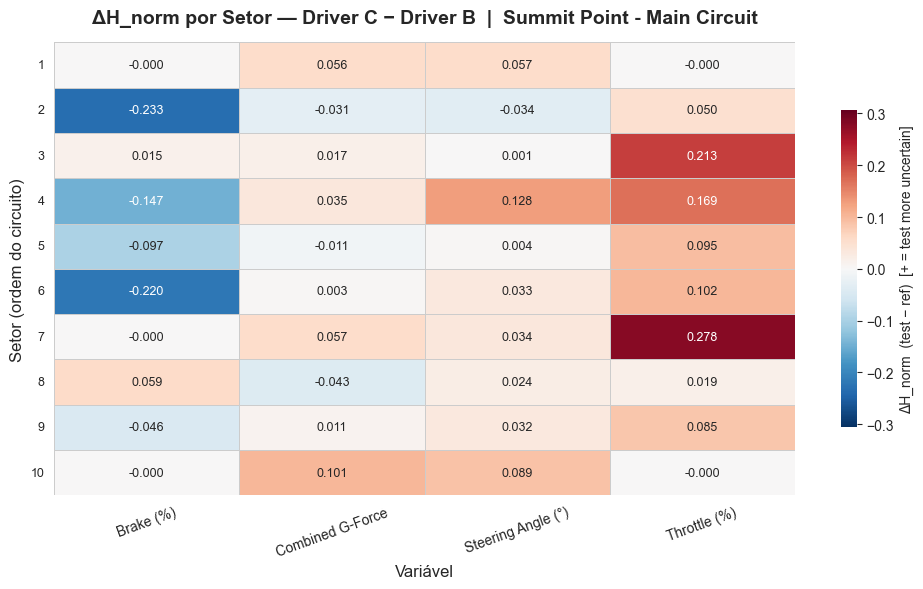


══════════════════════════════════════════════════════════════════════
  TABELA RESUMO — JSD por Setor  (Driver B vs Driver C)
  Pista: Summit Point - Main Circuit  |  Variáveis: 4
══════════════════════════════════════════════════════════════════════


,Sector,JSD_mean,JSD_max,JSD_std,n_vars,Level
0,2,0.0632,0.1692,0.0724,4,🟢 LOW
1,6,0.0625,0.1166,0.0364,4,🟢 LOW
2,4,0.0508,0.1035,0.0366,4,🟢 LOW
3,7,0.0463,0.0978,0.0412,4,🟢 LOW
4,5,0.0404,0.0616,0.0231,4,🟢 LOW
5,3,0.0303,0.0706,0.0305,4,🟢 LOW
6,10,0.0279,0.0706,0.0344,4,🟢 LOW
7,8,0.0278,0.0583,0.0226,4,🟢 LOW
8,1,0.0251,0.0781,0.0369,4,🟢 LOW
9,9,0.0248,0.0385,0.0130,4,🟢 LOW



  Top 3 setores com maior divergência:
    2                   JSD_mean=0.0632  JSD_max=0.1692  🟢 LOW
    6                   JSD_mean=0.0625  JSD_max=0.1166  🟢 LOW
    4                   JSD_mean=0.0508  JSD_max=0.1035  🟢 LOW

  JSD médio global  : 0.0399
  JSD máximo global : 0.1692  ← 2 / Brake (%)
  Setores avaliados : 10 / 10
  Setores HIGH JSD  : 0
  Setores LOW  JSD  : 10
══════════════════════════════════════════════════════════════════════


In [1035]:
# ═══════════════════════════════════════════════════════════════════════
# v2  —  JSD / KL / H_norm  POR SETOR  (substitui a célula 49 da v2)
# ═══════════════════════════════════════════════════════════════════════


# ── 1. Atribuição de setores ────────────────────────────────────────────
df_ref_s  = assign_sectors(df_ref_clean.copy(), CUSTOM_EDGES)
df_test_s = assign_sectors(df_test_clean.copy(), CUSTOM_EDGES)

# assign_sectors adiciona uma coluna 'Sector' (nome string ou índice inteiro).
# Detectamos o nome da coluna automaticamente:
SECTOR_COL = 'Sector' if 'Sector' in df_ref_s.columns else 'sector'

sectors_present = [s for s in SECTOR_NAMES if s in df_ref_s[SECTOR_COL].unique()]
print(f"✅ Setores detectados: {len(sectors_present)} / {len(SECTOR_NAMES)}")
print(f"   {sectors_present}\n")

# ── 2. Cálculo por setor × variável ────────────────────────────────────
MIN_SAMPLES = 10   # mínimo de amostras por setor para calcular JSD

rows = []

for sector in sectors_present:
    ref_s  = df_ref_s[df_ref_s[SECTOR_COL]  == sector]
    test_s = df_test_s[df_test_s[SECTOR_COL] == sector]

    for col, label in VARIABLES_ENTROPY:
        v_range = global_ranges.get(col)
        if v_range is None or col not in ref_s.columns:
            continue

        arr_ref  = ref_s[col].dropna().values
        arr_test = test_s[col].dropna().values

        if len(arr_ref) < MIN_SAMPLES or len(arr_test) < MIN_SAMPLES:
            rows.append({
                'Sector': sector, 'Variable': label,
                'FD Bins': np.nan, 'JSD': np.nan, 'KL D(test∥ref)': np.nan,
                'H_norm Ref': np.nan, 'H_norm Test': np.nan,
                'n_ref': len(arr_ref), 'n_test': len(arr_test),
                'Level': '⚪ N/A'
            })
            continue

        js_val, n_bins         = compute_jsd(arr_ref, arr_test, v_range)
        kl_val, _              = compute_kl(arr_ref, arr_test, v_range)
        h_r_n, _, _           = compute_shannon_normalized(arr_ref,  v_range)
        h_t_n, _, _           = compute_shannon_normalized(arr_test, v_range)
        delta_h                = h_t_n - h_r_n          # + = test more uncertain

        level = ("🟢 LOW"  if js_val < 0.10 else
                 "🟡 MOD"  if js_val < 0.30 else "🔴 HIGH")

        rows.append({
            'Sector': sector, 'Variable': label,
            'FD Bins': n_bins, 'JSD': round(js_val, 4),
            'KL D(test∥ref)': round(kl_val, 4),
            'H_norm Ref': round(h_r_n, 4), 'H_norm Test': round(h_t_n, 4),
            'ΔH (test−ref)': round(delta_h, 4),
            'n_ref': len(arr_ref), 'n_test': len(arr_test),
            'Level': level
        })

df_sector = pd.DataFrame(rows)
df_valid  = df_sector.dropna(subset=['JSD'])

# ── 3. Tabela longa — impressão formatada ──────────────────────────────
print(f"{'Sector':<18} {'Variable':<22} {'Bins':>5} "
      f"{'JSD':>8} {'KL':>8} {'H_ref':>7} {'H_test':>7} {'ΔH':>8}  Level")
print("─" * 95)

_last_sector = None
for _, r in df_sector.iterrows():
    sep = "\n" if r['Sector'] != _last_sector and _last_sector is not None else ""
    _last_sector = r['Sector']
    bins_str = f"{int(r['FD Bins']):>5}" if not pd.isna(r['FD Bins']) else "  N/A"
    jsd_str  = f"{r['JSD']:>8.4f}"       if not pd.isna(r['JSD'])     else "     N/A"
    kl_str   = f"{r['KL D(test∥ref)']:>8.4f}" if not pd.isna(r['KL D(test∥ref)']) else "     N/A"
    hr_str   = f"{r['H_norm Ref']:>7.4f}"  if not pd.isna(r['H_norm Ref'])  else "    N/A"
    ht_str   = f"{r['H_norm Test']:>7.4f}" if not pd.isna(r['H_norm Test']) else "    N/A"
    dh_str   = f"{r['ΔH (test−ref)']:>8.4f}" if 'ΔH (test−ref)' in r and not pd.isna(r.get('ΔH (test−ref)', np.nan)) else "     N/A"
    print(f"{sep}{r['Sector']:<18} {r['Variable']:<22} {bins_str} "
          f"{jsd_str} {kl_str} {hr_str} {ht_str} {dh_str}  {r['Level']}")

print("─" * 95)
print(f"  JSD: 0=identical · 1=fully disjoint  |  ΔH: positive=test more uncertain\n")

# ── 4. Heatmap JSD (setores × variáveis) ───────────────────────────────
pivot_jsd = df_sector.pivot(index='Sector', columns='Variable', values='JSD')
pivot_jsd = pivot_jsd.reindex(sectors_present)     # preserve circuit order

fig, ax = plt.subplots(figsize=(max(10, len(VARIABLES_ENTROPY) * 2.2),
                                max(6,  len(sectors_present) * 0.6)))

mask = pivot_jsd.isna()
sns.heatmap(
    pivot_jsd, ax=ax,
    cmap='RdYlGn_r',       # green=similar · red=divergent
    vmin=0, vmax=0.5,
    annot=True, fmt='.3f', annot_kws={'size': 9},
    linewidths=0.4, linecolor='#cccccc',
    mask=mask,
    cbar_kws={'label': 'JSD  [0=identical · 0.5+=high divergence]',
              'shrink': 0.7}
)

# Mark N/A cells
for (i, j), val in np.ndenumerate(pivot_jsd.values):
    if np.isnan(val):
        ax.text(j + 0.5, i + 0.5, 'N/A', ha='center', va='center',
                fontsize=8, color='#999999')

ax.set_title(
    f"JSD por Setor — {driver_a} vs {driver_b}  |  {TRACK_NAME}",
    fontsize=14, fontweight='bold', pad=14
)
ax.set_xlabel('Variável', fontsize=12)
ax.set_ylabel('Setor (ordem do circuito)', fontsize=12)
ax.tick_params(axis='x', labelsize=10, rotation=20)
ax.tick_params(axis='y', labelsize=9,  rotation=0)
plt.tight_layout()
fig.savefig(SAVE_DIR / f"jsd_heatmap_sectors_{TRACK}_{DRIVER_REF}_vs_{DRIVER_TEST}_{STINT_TEST}.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ── 5. Heatmap ΔH (setores × variáveis) ────────────────────────────────
pivot_dh = df_sector.pivot(index='Sector', columns='Variable', values='ΔH (test−ref)')
pivot_dh = pivot_dh.reindex(sectors_present)

fig2, ax2 = plt.subplots(figsize=(max(10, len(VARIABLES_ENTROPY) * 2.2),
                                   max(6,  len(sectors_present) * 0.6)))
mask2 = pivot_dh.isna()
vabs  = max(0.05, pivot_dh.abs().max().max() * 1.1) if not pivot_dh.isna().all().all() else 0.3

sns.heatmap(
    pivot_dh, ax=ax2,
    cmap='RdBu_r',          # blue=test less complex · red=test more complex
    vmin=-vabs, vmax=vabs,
    center=0,
    annot=True, fmt='.3f', annot_kws={'size': 9},
    linewidths=0.4, linecolor='#cccccc',
    mask=mask2,
    cbar_kws={'label': 'ΔH_norm  (test − ref)  [+ = test more uncertain]',
              'shrink': 0.7}
)
ax2.set_title(
    f"ΔH_norm por Setor — {driver_b} − {driver_a}  |  {TRACK_NAME}",
    fontsize=14, fontweight='bold', pad=14
)
ax2.set_xlabel('Variável', fontsize=12)
ax2.set_ylabel('Setor (ordem do circuito)', fontsize=12)
ax2.tick_params(axis='x', labelsize=10, rotation=20)
ax2.tick_params(axis='y', labelsize=9,  rotation=0)
plt.tight_layout()
fig2.savefig(SAVE_DIR / f"delta_hnorm_heatmap_sectors_{TRACK}_{DRIVER_REF}_vs_{DRIVER_TEST}_{STINT_TEST}.pdf", dpi=300, bbox_inches='tight')
plt.show()

# ── 6. Ranking de setores por JSD médio (todas as variáveis) ───────────
sector_ranking = (
    df_valid.groupby('Sector')['JSD']
    .agg(JSD_mean='mean', JSD_max='max', JSD_std='std', n_vars='count')
    .round(4)
    .sort_values('JSD_mean', ascending=False)
    .reset_index()
)
sector_ranking['Level'] = sector_ranking['JSD_mean'].apply(
    lambda x: "🔴 HIGH" if x >= 0.30 else ("🟡 MOD" if x >= 0.10 else "🟢 LOW"))

# ── 7. Tabela resumo final ──────────────────────────────────────────────
print("\n" + "═" * 70)
print(f"  TABELA RESUMO — JSD por Setor  ({driver_a} vs {driver_b})")
print(f"  Pista: {TRACK_NAME}  |  Variáveis: {len(VARIABLES_ENTROPY)}")
print("═" * 70)

display(sector_ranking)

print("\n  Top 3 setores com maior divergência:")
for _, r in sector_ranking.head(3).iterrows():
    print(f"    {r['Sector']:<18}  JSD_mean={r['JSD_mean']:.4f}  "
          f"JSD_max={r['JSD_max']:.4f}  {r['Level']}")

print(f"\n  JSD médio global  : {df_valid['JSD'].mean():.4f}")
print(f"  JSD máximo global : {df_valid['JSD'].max():.4f}  "
      f"← {df_valid.loc[df_valid['JSD'].idxmax(), 'Sector']} / "
      f"{df_valid.loc[df_valid['JSD'].idxmax(), 'Variable']}")
print(f"  Setores avaliados : {df_valid['Sector'].nunique()} / {len(sectors_present)}")
print(f"  Setores HIGH JSD  : {(sector_ranking['JSD_mean'] >= 0.30).sum()}")
print(f"  Setores LOW  JSD  : {(sector_ranking['JSD_mean'] <  0.10).sum()}")
print("═" * 70)



## 5. Perfil JSD ao Longo da Volta

Pergunta: **em qual momento da volta os pilotos mais divergem?**

O perfil usa os mesmos bins Freedman-Diaconis calculados sobre o pool de amostras
em cada janela temporal.

C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:40: RuntimeWarning: All-NaN slice encountered
  med_trel_r = np.nanmedian(trel_r, axis=0) if trel_r.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:41: RuntimeWarning: All-NaN slice encountered
  med_trel_t = np.nanmedian(trel_t, axis=0) if trel_t.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:86: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:88: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


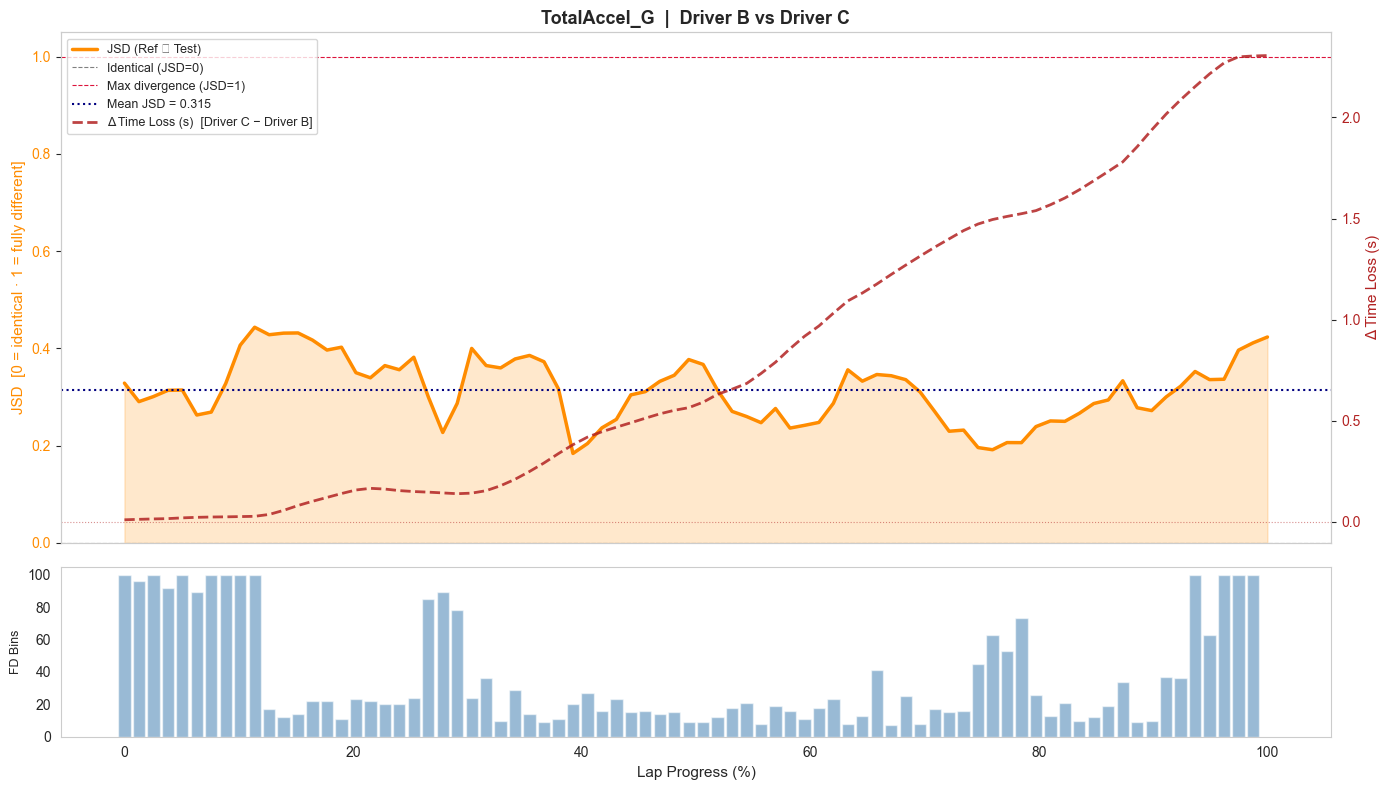

C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:40: RuntimeWarning: All-NaN slice encountered
  med_trel_r = np.nanmedian(trel_r, axis=0) if trel_r.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:41: RuntimeWarning: All-NaN slice encountered
  med_trel_t = np.nanmedian(trel_t, axis=0) if trel_t.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:86: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:88: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


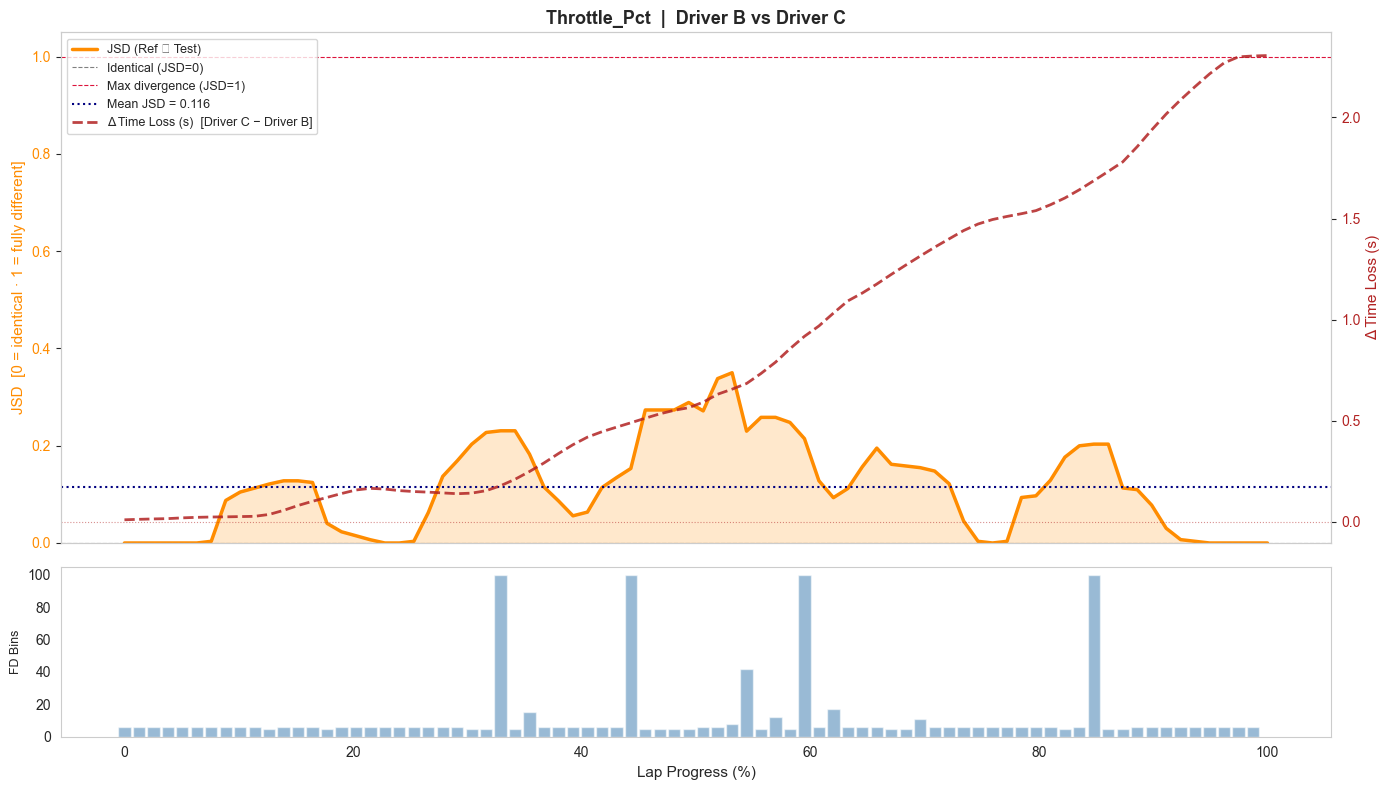

C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:40: RuntimeWarning: All-NaN slice encountered
  med_trel_r = np.nanmedian(trel_r, axis=0) if trel_r.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:41: RuntimeWarning: All-NaN slice encountered
  med_trel_t = np.nanmedian(trel_t, axis=0) if trel_t.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:86: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:88: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


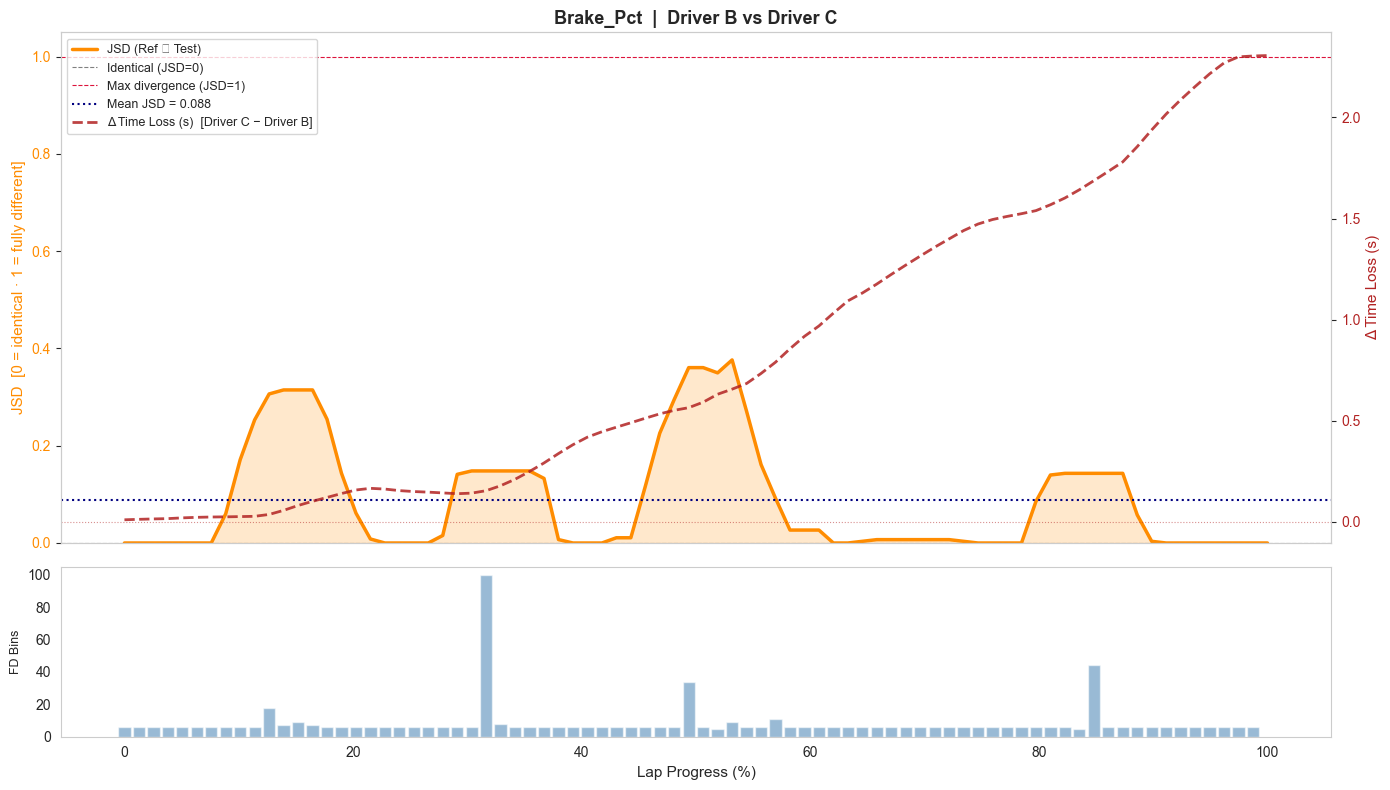

C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:40: RuntimeWarning: All-NaN slice encountered
  med_trel_r = np.nanmedian(trel_r, axis=0) if trel_r.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:41: RuntimeWarning: All-NaN slice encountered
  med_trel_t = np.nanmedian(trel_t, axis=0) if trel_t.size else np.full(n_windows, np.nan)
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:86: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2558805063.py:88: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8741 (\N{PARALLEL TO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


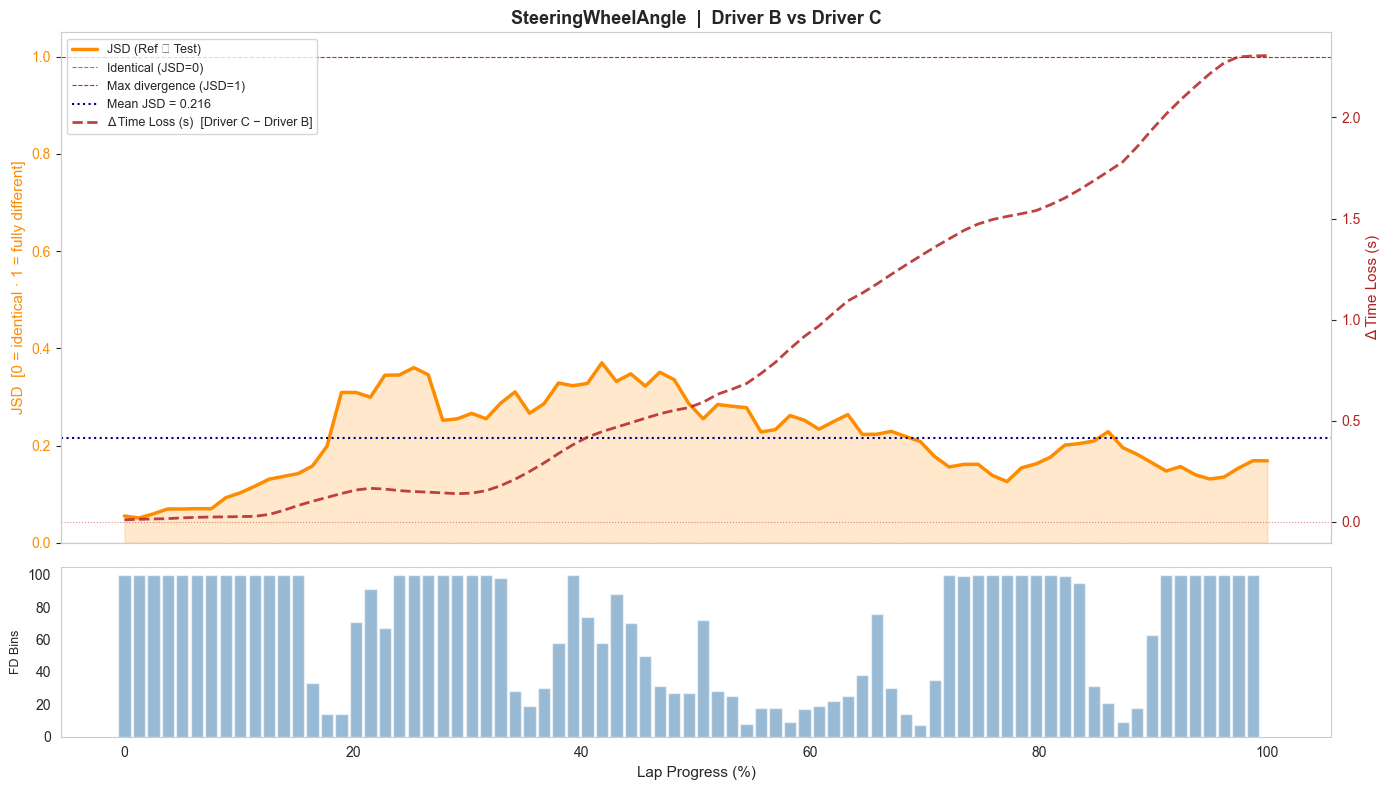

In [1036]:
def plot_jsd_profile(df_ref, df_test, target_col, v_range,
                     n_windows: int = 80, smooth_window: int = 7,
                     label_ref: str = 'Ref', label_test: str = 'Test'):
    """JSD between driver distributions at each time window over the lap."""

    def build_ensemble_by_dist(df):
        """Ensemble matrix over LapDistPct bins + t_rel for delta_time."""
        common_d = np.linspace(0, 1, n_windows)
        sig_mat, trel_mat = [], []
        for lap in df['Lap'].unique():
            ld = (df[df['Lap'] == lap]
                  .sort_values('LapDistPct')
                  .drop_duplicates('LapDistPct'))
            if len(ld) < 5: continue
            x = ld['LapDistPct'].values
            if x.max() - x.min() < 0.5: continue   # incomplete lap guard
            t_z = (ld['SessionTime'] - ld['SessionTime'].iloc[0]).values
            sig_mat.append(np.interp(common_d, x, ld[target_col].values, right=np.nan))
            trel_mat.append(np.interp(common_d, x, t_z, right=np.nan))
        return np.array(sig_mat), np.array(trel_mat), common_d

    mat_r, trel_r, d = build_ensemble_by_dist(df_ref)
    mat_t, trel_t, _ = build_ensemble_by_dist(df_test)
    t = d   # alias kept for FD-bins panel

    jsd_vals, bins_used = [], []
    for i in range(n_windows):
        a = mat_r[:, i]; a = a[~np.isnan(a)]
        b = mat_t[:, i]; b = b[~np.isnan(b)]
        if len(a) > 2 and len(b) > 2:
            jv, nb = compute_jsd(a, b, v_range)
            jsd_vals.append(jv); bins_used.append(nb)
        else:
            jsd_vals.append(np.nan); bins_used.append(0)

    jsd_s = (pd.Series(jsd_vals)
               .rolling(smooth_window, center=True, min_periods=1).mean().values)

    # ── Δ Time Loss: median t_rel(test) − median t_rel(ref) per dist bin ──
    med_trel_r = np.nanmedian(trel_r, axis=0) if trel_r.size else np.full(n_windows, np.nan)
    med_trel_t = np.nanmedian(trel_t, axis=0) if trel_t.size else np.full(n_windows, np.nan)
    time_delta   = med_trel_t - med_trel_r
    time_delta_s = (pd.Series(time_delta)
                      .rolling(smooth_window, center=True, min_periods=1).mean().values)

    x_pct = d * 100.0   # x-axis in % lap progress

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                    gridspec_kw={'height_ratios': [3, 1]})

    # JSD — left y-axis (orange)
    ax1.fill_between(x_pct, 0, jsd_s, color='darkorange', alpha=0.2)
    ax1.plot(x_pct, jsd_s, color='darkorange', lw=2.5, label='JSD (Ref ∥ Test)')
    ax1.axhline(0.0,  color='gray',    ls='--', lw=0.8, label='Identical (JSD=0)')
    ax1.axhline(1.0,  color='crimson', ls='--', lw=0.8, label='Max divergence (JSD=1)')
    mean_jsd = np.nanmean(jsd_s)
    ax1.axhline(mean_jsd, color='navy', ls=':', lw=1.5,
                label=f'Mean JSD = {mean_jsd:.3f}')
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('JSD  [0 = identical · 1 = fully different]',
                   fontsize=11, color='darkorange')
    ax1.tick_params(axis='y', labelcolor='darkorange')

    # Δ Time Loss — right y-axis (twin, red dashed)
    ax1b = ax1.twinx()
    ax1b.plot(x_pct, time_delta_s, color='firebrick', lw=2.0, ls='--', alpha=0.85,
              label=f'Δ Time Loss (s)  [{label_test} − {label_ref}]')
    ax1b.axhline(0, color='firebrick', ls=':', lw=0.8, alpha=0.5)
    ax1b.set_ylabel('Δ Time Loss (s)', fontsize=11, color='firebrick')
    ax1b.tick_params(axis='y', labelcolor='firebrick')

    # combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax1b.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='upper left')
    ax1.grid(False)
    ax1b.grid(False)
    ax1.set_title(f'{target_col}  |  {label_ref} vs {label_test}', fontsize=13, fontweight='bold')

    bar_w = (x_pct[1] - x_pct[0]) * 0.85
    ax2.bar(x_pct, bins_used, width=bar_w, color='steelblue', alpha=0.55)
    ax2.set_ylabel('FD Bins', fontsize=9)
    ax2.set_xlabel('Lap Progress (%)', fontsize=11)
    ax2.grid(False)

    plt.tight_layout()
    fname = f"jsd_profile_{target_col.lower()}_{TRACK}_{DRIVER_REF}_vs_{DRIVER_TEST}_{STINT_TEST}.pdf"
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()
    return t, jsd_s


for col, label in VARIABLES_ENTROPY:
    v_range = global_ranges.get(col)
    if v_range and col in df_ref_clean.columns:
        plot_jsd_profile(df_ref_clean, df_test_clean, col, v_range,
                         label_ref=driver_a, label_test=driver_b)



### 5.1 Correlação JSD × Δ Time Loss

Pergunta: **a divergência comportamental medida pelo JSD de cada variável
prediz a perda de tempo por setor?**

O eixo horizontal de cada heatmap representa as variáveis de JSD mais o
`DeltaTime_s`. O coeficiente de interesse é a linha/coluna `DeltaTime_s`.

**Pearson r** — correlação linear;  
**Spearman ρ** — correlação de ranks, robusta a outliers e relações monotônicas
não-lineares.

Além disso, três métodos complementares são discutidos abaixo para confirmar
ou refinar a conclusão.


Setores com dados completos para correlação: 10


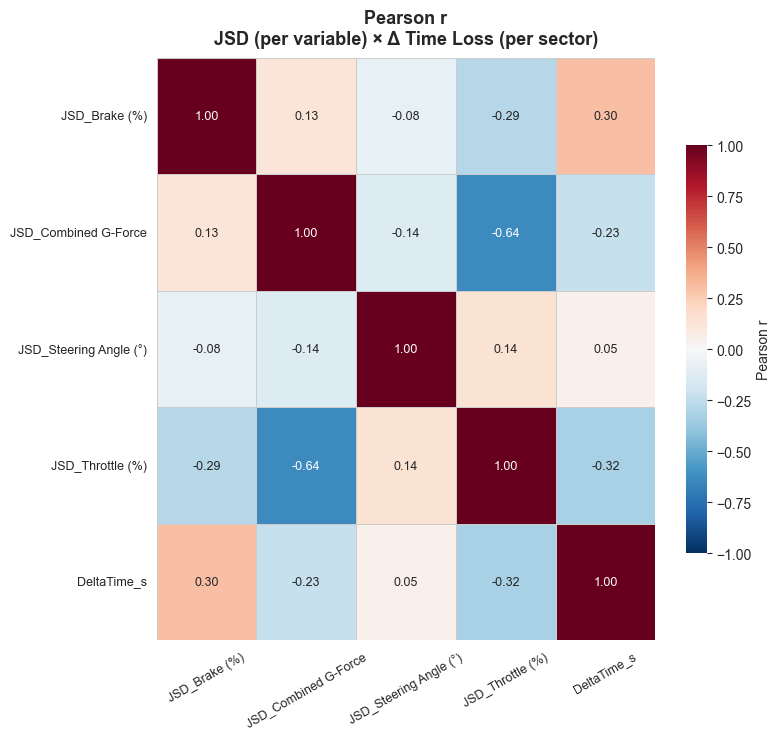


═══════════════════════════════════════════════════════════════════════════
  CORRELAÇÃO JSD × Δ Time Loss  —  Driver B vs Driver C  |  Summit Point - Main Circuit
═══════════════════════════════════════════════════════════════════════════


,Variable,Pearson r,p (Pearson),Strength
3,Throttle (%),-0.321,0.366,weak
0,Brake (%),0.300,0.399,weak
1,Combined G-Force,-0.234,0.515,weak
2,Steering Angle (°),0.050,0.890,weak



  Variável com maior influência: Throttle (%)
  Pearson r = -0.321
  Interpretação: JSD de Throttle (%) explica a perda de tempo por setor.


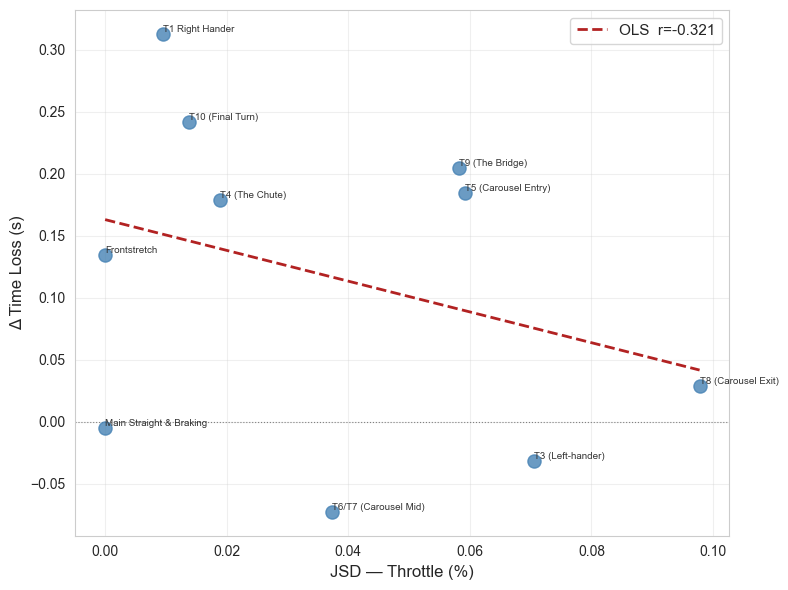


═══════════════════════════════════════════════════════════════════════════
  MÉTODOS COMPLEMENTARES
═══════════════════════════════════════════════════════════════════════════


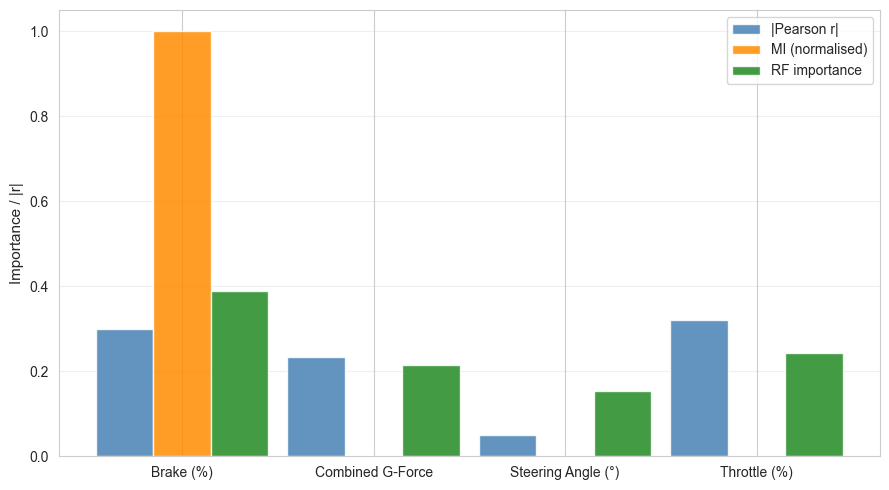

  (a) Mutual Information (normalised):
      Brake (%)                       MI_norm = 1.000
      Combined G-Force                MI_norm = 0.000
      Steering Angle (°)              MI_norm = 0.000
      Throttle (%)                    MI_norm = 0.000

  (b) Random Forest feature importance:
      Brake (%)                       imp     = 0.388
      Throttle (%)                    imp     = 0.243
      Combined G-Force                imp     = 0.214
      Steering Angle (°)              imp     = 0.154

  RF R² (leave-1-out proxy): 0.773  ← overfit risk with n=10 sectors


In [1037]:
# ══════════════════════════════════════════════════════════════════════════
#  Seção 11 — Correlação JSD × Δ Time Loss
#  Depende de:
#    • df_sector       (seção 4 — JSD por setor × variável)
#    • sectors_present (seção 4 — lista de setores em ordem de circuito)
#    • CUSTOM_EDGES, SECTOR_NAMES
#    • align_lap_by_dist (célula 9)
#    • df_ref_clean, df_test_clean
# ══════════════════════════════════════════════════════════════════════════

from scipy.stats import pearsonr
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor

# ── 1. Compute sector Δ time from best laps ─────────────────────────────────
_grid = np.linspace(0.0, 1.0, 2000)

def _best_lap_interp(df):
    validity = build_lap_validity_table(df, verbose=False)
    best_row  = validity[validity['Valid']].sort_values('LapTime_s').iloc[0]
    g = df[df['Lap'] == int(best_row['Lap'])]
    return align_lap_by_dist(g, _grid)

_ir = _best_lap_interp(df_ref_clean)
_it = _best_lap_interp(df_test_clean)

if not _ir or not _it:
    raise RuntimeError("Could not align best laps — check df_ref_clean / df_test_clean")

_loss     = _it['t_rel'] - _ir['t_rel']
_lap_dist = _ir['LapDistPct']

_sector_delta = []
for s_id in sorted(sectors_present):          # integer sector IDs
    if s_id > len(CUSTOM_EDGES) - 1: continue
    s0   = CUSTOM_EDGES[s_id - 1]
    s1   = CUSTOM_EDGES[s_id]
    mask = (_lap_dist >= s0) & (_lap_dist <= s1)
    if not np.any(mask): continue
    pts   = np.flatnonzero(mask)
    delta = float(_loss[pts[-1]] - _loss[pts[0]])
    _sector_delta.append({'Sector': s_id, 'DeltaTime_s': delta})

df_delta = pd.DataFrame(_sector_delta)

# ── 2. Pivot JSD: one row per sector, one column per variable ───────────────
jsd_pivot = (df_sector[df_sector['JSD'].notna()]
             .pivot(index='Sector', columns='Variable', values='JSD')
             .reset_index())
jsd_pivot.columns = ['Sector'] + [f'JSD_{c}' for c in jsd_pivot.columns[1:]]

# ── 3. Merge ────────────────────────────────────────────────────────────────
df_cm = jsd_pivot.merge(df_delta, on='Sector').dropna()
jsd_cols = [c for c in df_cm.columns if c.startswith('JSD_')]
target   = 'DeltaTime_s'
all_cols = jsd_cols + [target]
n_valid  = len(df_cm)

print(f"Setores com dados completos para correlação: {n_valid}")
if n_valid < 5:
    print("⚠  Poucos setores — interprete os coeficientes com cautela.")

# ── 4. Pearson correlation matrix ───────────────────────────────────────────
corr_pearson  = df_cm[all_cols].corr(method='pearson')

# ── 5. Plot: heatmap ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(max(8, len(all_cols) * 1.5),
                                max(7,  len(all_cols) * 1.5)))

_hm_kw = dict(
    annot=True, fmt='.2f', annot_kws={'size': 9},
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='#cccccc',
    cbar_kws={'label': 'Pearson r', 'shrink': 0.7}
)

sns.heatmap(corr_pearson, ax=ax, **_hm_kw)

ax.set_title('Pearson r\nJSD (per variable) × Δ Time Loss (per sector)',
             fontsize=13, fontweight='bold', pad=10)
ax.tick_params(axis='x', labelsize=9,  rotation=30)
ax.tick_params(axis='y', labelsize=9,  rotation=0)

# highlight the DeltaTime_s row
dt_idx = list(corr_pearson.columns).index(target)
for patch in ax.patches:
    pass   # seaborn doesn't expose easy row highlighting; skip for now

plt.tight_layout()
fig.savefig(SAVE_DIR / f"jsd_vs_deltaloss_correlation_{TRACK}_{DRIVER_REF}_vs_{DRIVER_TEST}_{STINT_TEST}.pdf",
            dpi=300, bbox_inches='tight')
plt.show()

# ── 6. Summary table: correlation with DeltaTime_s ──────────────────────────
summary_rows = []
for col in jsd_cols:
    r_p, p_p   = pearsonr(df_cm[col],  df_cm[target])
    var_label  = col.replace('JSD_', '')
    strength   = ("|r| > 0.5 → moderate" if abs(r_p) >= 0.5 else "weak")
    summary_rows.append({'Variable': var_label,
                         'Pearson r': round(r_p, 3), 'p (Pearson)': round(p_p, 3),
                         'Strength': strength})

df_summary = (pd.DataFrame(summary_rows)
              .sort_values('Pearson r', key=abs, ascending=False))

print("\n" + "═" * 75)
print(f"  CORRELAÇÃO JSD × Δ Time Loss  —  {driver_a} vs {driver_b}  |  {TRACK_NAME}")
print("═" * 75)
display(df_summary)

best_var  = df_summary.iloc[0]['Variable']
best_r    = df_summary.iloc[0]['Pearson r']
print(f"\n  Variável com maior influência: {best_var}")
print(f"  Pearson r = {best_r:+.3f}")
print(f"  Interpretação: JSD de {best_var} {'explica' if abs(best_r) > 0.3 else 'tem relação fraca com'}"
      f" a perda de tempo por setor.")

# ── 7. Scatter: most-correlated variable vs DeltaTime_s ─────────────────────
best_col  = f'JSD_{best_var}'
fig2, ax2 = plt.subplots(figsize=(8, 6))
for _, row in df_cm.iterrows():
    ax2.scatter(row[best_col], row[target], s=90, color='steelblue', alpha=0.8, zorder=3)
    ax2.annotate(SECTOR_NAMES.get(int(row['Sector']), str(row['Sector'])),
                 (row[best_col], row[target]),
                 fontsize=7, ha='left', va='bottom', color='#333333')

# regression line
_x = df_cm[best_col].values
_y = df_cm[target].values
_m, _b = np.polyfit(_x[np.isfinite(_x) & np.isfinite(_y)],
                     _y[np.isfinite(_x) & np.isfinite(_y)], 1)
_xs = np.linspace(_x.min(), _x.max(), 50)
ax2.plot(_xs, _m * _xs + _b, color='firebrick', lw=2, ls='--',
         label=f'OLS  r={best_r:+.3f}')

ax2.axhline(0, color='gray', ls=':', lw=0.8)
ax2.set_xlabel(f'JSD — {best_var}', fontsize=12)
ax2.set_ylabel('Δ Time Loss (s)', fontsize=12)
#ax2.set_title(f'Scatter: JSD {best_var} × Δ Time Loss\n'
#              f'{driver_a} vs {driver_b}  |  {TRACK_NAME}',
#              fontsize=13, fontweight='bold')
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3)
plt.tight_layout()
fig2.savefig(SAVE_DIR / f"jsd_{best_var.lower().replace(' ','_')}_vs_deltaloss_scatter_{TRACK}_{driver_a}_vs_{driver_b}_{STINT_TEST}.pdf",
             dpi=300, bbox_inches='tight')
plt.show()

# ── 8. Alternative methods ───────────────────────────────────────────────────
print("\n" + "═" * 75)
print("  MÉTODOS COMPLEMENTARES")
print("═" * 75)

X = df_cm[jsd_cols].values
y = df_cm[target].values
valid = np.all(np.isfinite(X), axis=1) & np.isfinite(y)
X_v, y_v = X[valid], y[valid]

if len(y_v) >= 5:

    # --- (a) Mutual Information (sklearn) ----------------------------------
    mi_vals = mutual_info_regression(X_v, y_v, n_neighbors=min(3, len(y_v)-1),
                                      random_state=42)
    mi_norm  = mi_vals / (mi_vals.sum() + 1e-12)

    # --- (b) Random Forest feature importance ------------------------------
    rf = RandomForestRegressor(n_estimators=200, random_state=42,
                                min_samples_leaf=1)
    rf.fit(X_v, y_v)
    rf_imp = rf.feature_importances_

    # --- Combined bar chart ------------------------------------------------
    method_labels = [c.replace('JSD_', '') for c in jsd_cols]
    x_idx = np.arange(len(method_labels))
    bar_w = 0.30

    fig3, ax3 = plt.subplots(figsize=(max(9, len(method_labels) * 1.8), 5))
    ax3.bar(x_idx - bar_w, np.abs([df_summary.set_index('Variable').loc[l, 'Pearson r']
                                    for l in method_labels]),
            bar_w, label='|Pearson r|',  color='steelblue', alpha=0.85)
    ax3.bar(x_idx,         mi_norm,   bar_w, label='MI (normalised)',   color='darkorange', alpha=0.85)
    ax3.bar(x_idx + bar_w, rf_imp,    bar_w, label='RF importance',     color='forestgreen', alpha=0.85)

    ax3.set_xticks(x_idx); ax3.set_xticklabels(method_labels, fontsize=10)
    ax3.set_ylabel('Importance / |r|', fontsize=11)
    
    ax3.legend(fontsize=10); ax3.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    fig3.savefig(SAVE_DIR / f"jsd_importance_{TRACK}_{driver_a}_vs_{driver_b}_{STINT_TEST}.pdf",
                 dpi=300, bbox_inches='tight')
    plt.show()

    print("  (a) Mutual Information (normalised):")
    for lbl, mi in sorted(zip(method_labels, mi_norm), key=lambda x: -x[1]):
        print(f"      {lbl:<30}  MI_norm = {mi:.3f}")

    print("\n  (b) Random Forest feature importance:")
    for lbl, imp in sorted(zip(method_labels, rf_imp), key=lambda x: -x[1]):
        print(f"      {lbl:<30}  imp     = {imp:.3f}")

    print(f"\n  RF R² (leave-1-out proxy): {rf.score(X_v, y_v):.3f}  "
          f"← overfit risk with n={len(y_v)} sectors")

else:
    print("  ⚠  Insufficient sectors for MI / RF — need ≥ 5 valid rows.")

### Outros métodos para tirar a mesma conclusão

| Método | O que mede | Quando usar |
|--------|-----------|-------------|
| **Pearson r** (acima) | Correlação linear | Relação aproximadamente linear, distribuição normal |
| **Spearman ρ** (acima) | Correlação monotônica de ranks | Outliers ou relação não-linear mas ordenada |
| **Mutual Information** (acima) | Dependência genérica (linear + não-linear) | Qualquer relação, incluindo multi-modal |
| **Random Forest importance** (acima) | Redução de impureza ao dividir em cada variável | Captura interações entre variáveis JSD |
| **Partial correlation** | Correlação controlando pelas outras variáveis JSD | Verificar se a influência de uma variável é real ou devida à co-correlação |
| **SHAP values** | Contribuição local de cada feature para cada predição | Entender *quais setores* são mais afetados pela variável X |
| **Transfer Entropy** (seção 10) | Fluxo direcional de informação entre sinais | JSD de variável X no setor n *causa* perda no setor n+1? |
| **Granger causality** | JSD passado prediz delta_time futuro? | Analisar efeito de legado entre setores consecutivos |

**Recomendação prática:** usar Pearson/Spearman como triagem rápida e Mutual Information
como confirmação não-linear. Se o RF importance concordar com ambos, a conclusão é robusta.
O SHAP é o passo seguinte natural — permite ver *em quais setores específicos*
a variável identificada como mais influente realmente impacta o tempo.


## 6. Mapa Espacial de JSD no Circuito

Pergunta: **onde no circuito os pilotos mais divergem?**

Verde = comportamento similar · Vermelho = divergência máxima

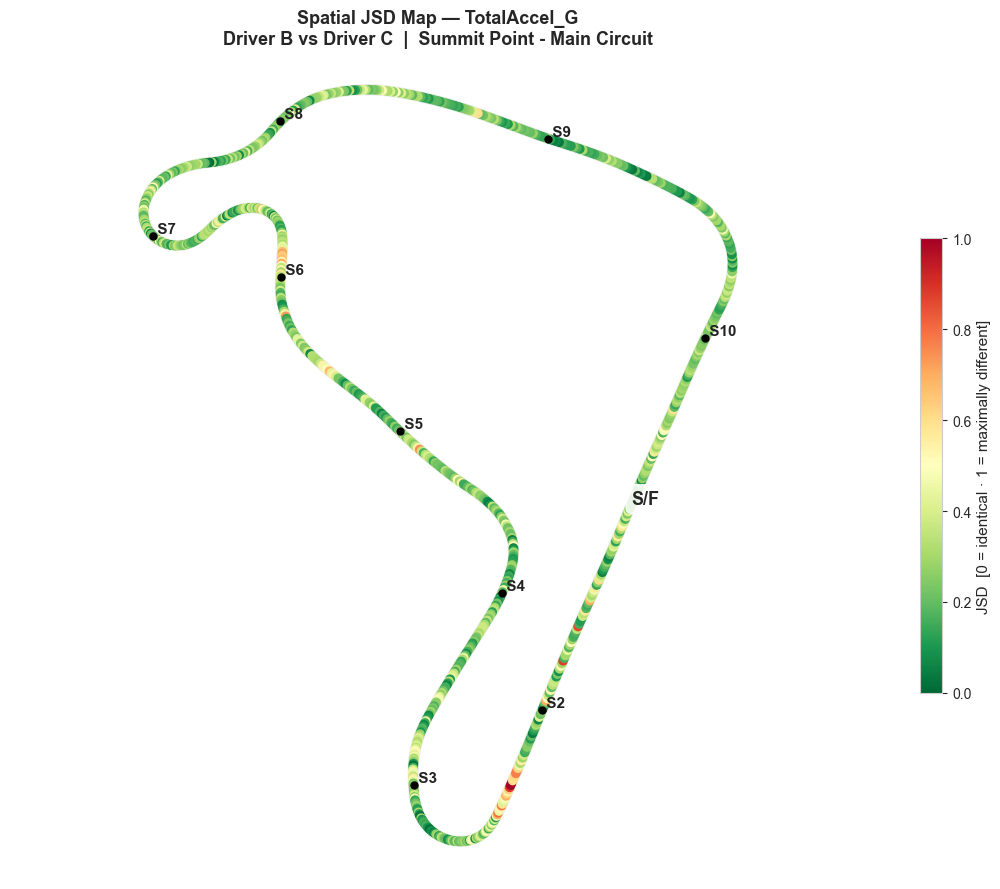


📊 JSD Map — TotalAccel_G
  Mean JSD : 0.2735
  Max  JSD : 1.0000  ← most divergent zone
  Min  JSD : 0.0046  ← most similar zone
  Interpretation: MODERATE divergence


In [1038]:
import numpy as np
import matplotlib.pyplot as plt

def plot_jsd_track_map(df_ref, df_test, target_col='TotalAccel_G', 
                       global_range=None, n_points: int = 1000,
                       sector_edges: list = None):
    v_range = global_range or (
        float(np.percentile(
            np.concatenate([df_ref[target_col].dropna(), df_test[target_col].dropna()]), 1)),
        float(np.percentile(
            np.concatenate([df_ref[target_col].dropna(), df_test[target_col].dropna()]), 99)))

    def build_gps_ensemble(df):
        lap_times = df.groupby('Lap')['SessionTime'].apply(lambda x: x.max() - x.min())
        common_t  = np.linspace(0, lap_times.median(), n_points)
        matrix    = [
            np.interp(common_t,
                      df[df['Lap'] == lap].sort_values('SessionTime')['SessionTime']
                        - df[df['Lap'] == lap]['SessionTime'].min(),
                      df[df['Lap'] == lap].sort_values('SessionTime')[target_col].values,
                      right=np.nan)
            for lap in df['Lap'].unique()
            if len(df[df['Lap'] == lap]) > 10
        ]
        validity = build_lap_validity_table(df, verbose=False)
        fastest  = int(validity[validity['Valid']].sort_values('LapTime_s').iloc[0]['Lap'])
        best     = df[df['Lap'] == fastest].sort_values('SessionTime').copy()
        for c in ['Lat', 'Lon']:
            best[c] = best[c].interpolate(limit_direction='both')
        best = best.dropna(subset=['Lat', 'Lon'])
        t_l  = best['SessionTime'] - best['SessionTime'].iloc[0]
        return (np.array(matrix),
                np.interp(common_t, t_l, best['Lat']),
                np.interp(common_t, t_l, best['Lon']),
                best)

    mat_r, lat, lon, lap_best = build_gps_ensemble(df_ref)
    mat_t, _, _, _            = build_gps_ensemble(df_test)

    jsd_map = np.array([
        compute_jsd(mat_r[:, i][~np.isnan(mat_r[:, i])],
                    mat_t[:, i][~np.isnan(mat_t[:, i])], v_range)[0]
        if (~np.isnan(mat_r[:, i])).sum() > 2 and (~np.isnan(mat_t[:, i])).sum() > 2
        else np.nan
        for i in range(n_points)
    ])

    fig, ax = plt.subplots(figsize=(11, 9))
    ax.plot(lon, lat, color='silver', alpha=0.3, lw=8, zorder=1)
    
    # Plot do Heatmap JSD
    sc = ax.scatter(lon[::-1], lat[::-1], c=jsd_map[::-1], cmap='RdYlGn_r',
                    vmin=0, vmax=1.0, s=35, zorder=2)
    
    # Linha de Chegada / Setor 1
    p0 = lap_best.iloc[0]
    ax.text(p0['Lon'], p0['Lat'], 'S/F', fontsize=13, fontweight='bold',
            bbox=dict(boxstyle='round', fc='white', alpha=0.85), zorder=5)

    # ── NOVO: Ticks minimalistas dos setores ─────────────────────────────────
    if sector_edges is not None and 'LapDistPct' in lap_best.columns:
        # Ordenar e remover duplicatas para garantir que a interpolação funcione sem erros
        lap_sorted = lap_best.sort_values('LapDistPct').drop_duplicates('LapDistPct')
        
        # Ignoramos o primeiro (0.0) e o último (1.0) pois correspondem ao S/F
        for i, edge in enumerate(sector_edges[1:-1], start=2):
            edge_lat = np.interp(edge, lap_sorted['LapDistPct'], lap_sorted['Lat'])
            edge_lon = np.interp(edge, lap_sorted['LapDistPct'], lap_sorted['Lon'])

            # Ponto de marcação
            ax.plot(edge_lon, edge_lat, marker='o', color='black', markersize=5, zorder=4)
            
            # Texto da marcação com pequeno deslocamento e outline limpo
            ax.text(edge_lon, edge_lat, f" S{i}", fontsize=11, fontweight='bold', 
                    color='#222222', va='bottom', ha='left', zorder=5)
    # ─────────────────────────────────────────────────────────────────────────

    cbar = fig.colorbar(sc, ax=ax, shrink=0.55)
    cbar.set_label('JSD  [0 = identical · 1 = maximally different]', fontsize=11)
    ax.set_title(f"Spatial JSD Map — {target_col}\n"
                 f"{driver_a} vs {driver_b}  |  {TRACK_NAME}",
                 fontsize=13, fontweight='bold')
    ax.axis('equal')
    ax.axis('off')
    plt.tight_layout()
    
    fname = f"jsd_map_{target_col.lower()}_{driver_a}_vs_{driver_b}_{TRACK}_{STINT_TEST}.pdf"
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    
    plt.show()

    valid = jsd_map[~np.isnan(jsd_map)]
    print(f"\n📊 JSD Map — {target_col}")
    print(f"  Mean JSD : {valid.mean():.4f}")
    print(f"  Max  JSD : {valid.max():.4f}  ← most divergent zone")
    print(f"  Min  JSD : {valid.min():.4f}  ← most similar zone")
    level = ('LOW divergence' if valid.mean() < 0.10 else
             'MODERATE divergence' if valid.mean() < 0.30 else 'HIGH divergence')
    print(f"  Interpretation: {level}")
    
plot_jsd_track_map(
df_ref_clean, 
df_test_clean,
global_range=global_ranges.get('TotalAccel_G'),
sector_edges=CUSTOM_EDGES
)

## 7. Mapa de Calor de Entropia H_norm no Circuito

Versão corrigida do mapa original — usa H_norm ∈ [0, 1] e FD bins.

  [Driver B] Geometry: Lap 8  (01:19.767)
  [Driver C] Geometry: Lap 7  (01:20.950)


C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\2165591760.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


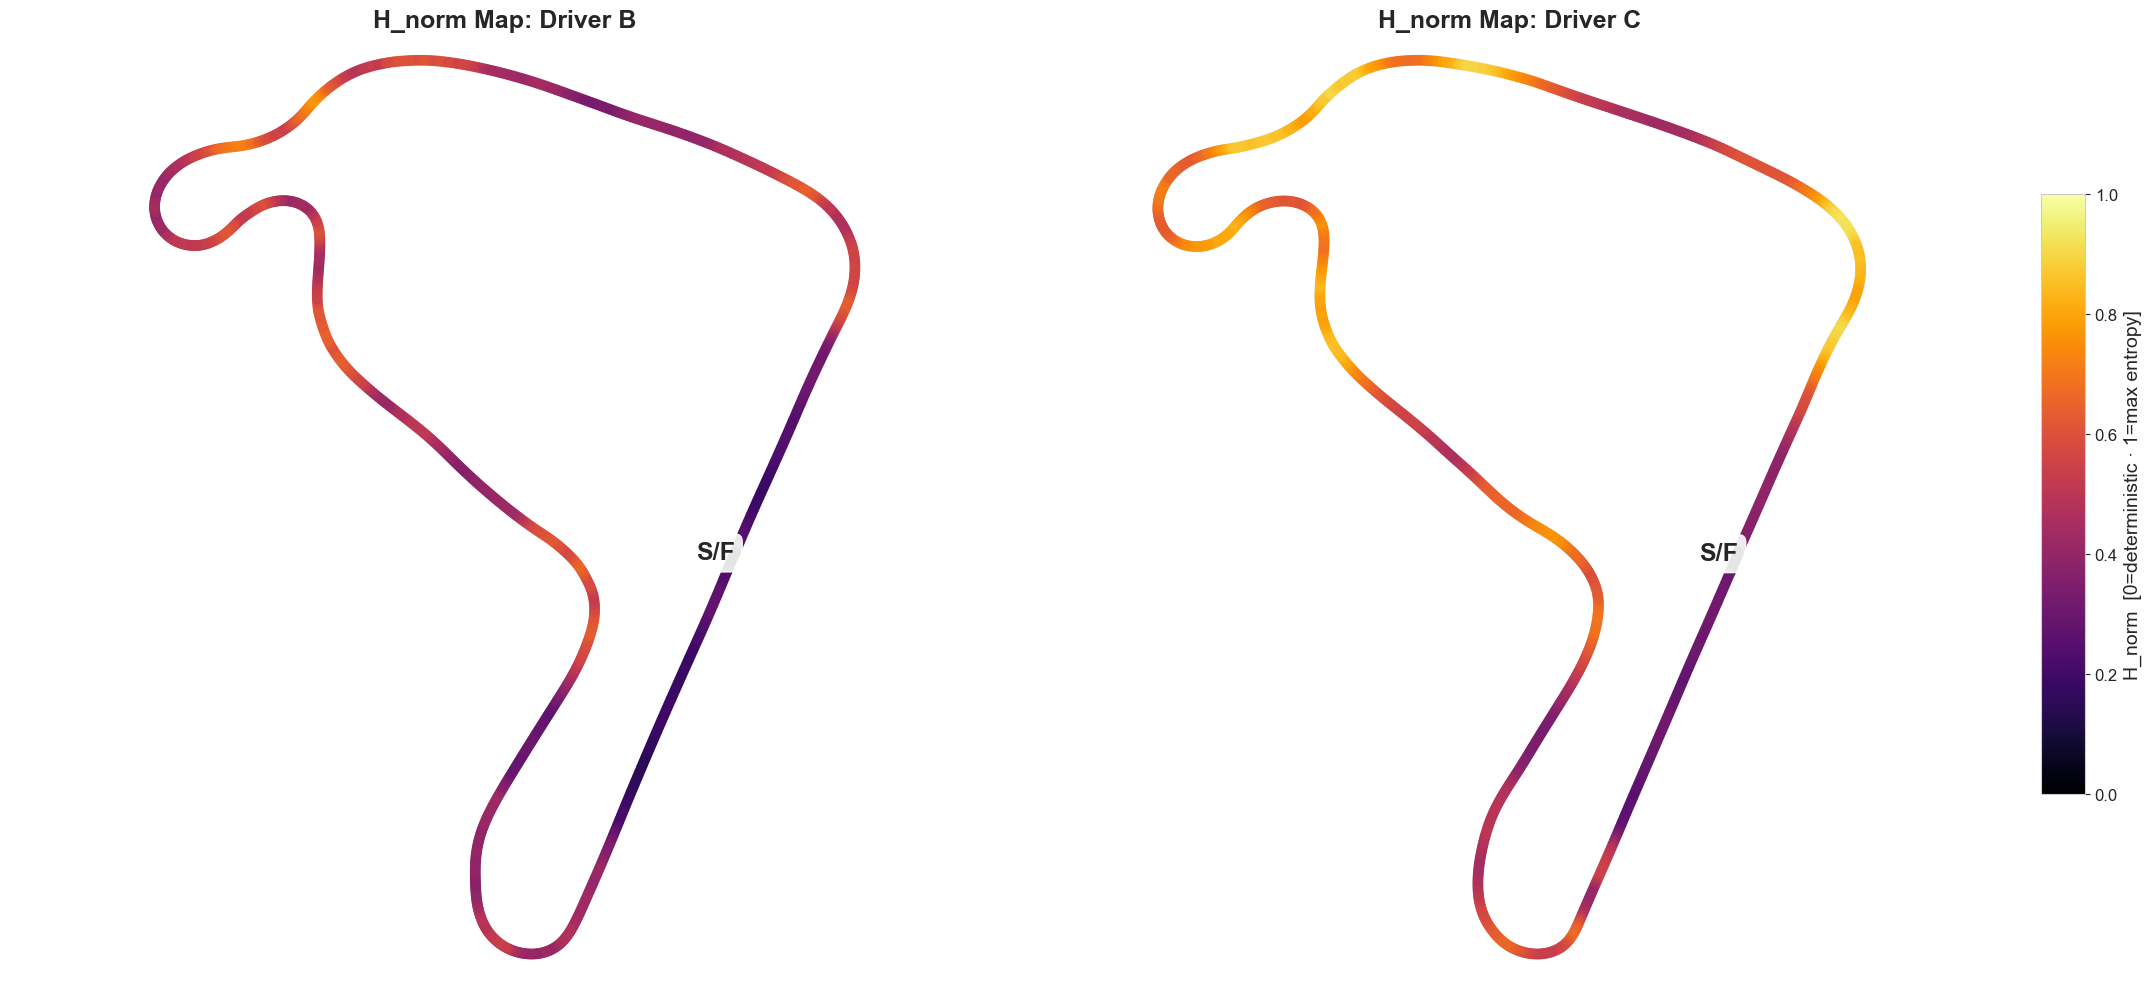

In [1039]:
def plot_comparative_track_entropy_v2(df_ref, df_test, target_col='TotalAccel_G',
                                       global_range=None):
    """Spatial entropy heatmap — H_norm, FD bins, density=False."""
    import math
    if global_range is None:
        combined = pd.concat([df_ref[target_col], df_test[target_col]], ignore_index=True)
        v_min, v_max = np.percentile(combined, 1), np.percentile(combined, 99)
    else:
        v_min, v_max = global_range

    def get_data_for_map(df, driver_name=""):
        lap_times   = df.groupby('Lap')['SessionTime'].apply(lambda x: x.max() - x.min())
        common_time = np.linspace(0, lap_times.median(), 1000)
        matrix = []
        for lap in df['Lap'].unique():
            ld = df[df['Lap'] == lap].sort_values('SessionTime')
            if len(ld) > 10:
                t_z = ld['SessionTime'] - ld['SessionTime'].iloc[0]
                matrix.append(np.interp(common_time, t_z, ld[target_col], right=np.nan))
        matrix = np.array(matrix)
        h_profile = []
        for t_idx in range(matrix.shape[1]):
            sl = matrix[:, t_idx]; sl = sl[~np.isnan(sl)]
            if len(sl) > 1:
                h_n, _, _ = compute_shannon_normalized(sl, (v_min, v_max))
                h_profile.append(h_n)
            else:
                h_profile.append(0)
        h_smooth = (pd.Series(h_profile)
                      .rolling(window=15, center=True).mean().fillna(0).values)
        validity    = build_lap_validity_table(df, verbose=False)
        valid_rows  = validity[validity["Valid"]]
        if valid_rows.empty: raise RuntimeError(f"[{driver_name}] No valid laps.")
        fastest_lap = int(valid_rows.sort_values("LapTime_s").iloc[0]["Lap"])
        fastest_t   = valid_rows.sort_values("LapTime_s").iloc[0]["LapTime_s"]
        mins, secs  = int(fastest_t // 60), fastest_t % 60
        print(f"  [{driver_name}] Geometry: Lap {fastest_lap}  ({mins:02d}:{secs:06.3f})")
        best = df[df['Lap'] == fastest_lap].sort_values('SessionTime').copy()
        for c in ['Lat', 'Lon']:
            best[c] = best[c].interpolate(method='linear', limit_direction='both')
        best = best.dropna(subset=['Lat', 'Lon'])
        t_lap = best['SessionTime'] - best['SessionTime'].iloc[0]
        return (np.interp(common_time, t_lap, best['Lon']),
                np.interp(common_time, t_lap, best['Lat']),
                h_smooth, best)

    lon_r, lat_r, h_r, lap_r = get_data_for_map(df_ref,  driver_name=driver_a)
    lon_t, lat_t, h_t, lap_t = get_data_for_map(df_test, driver_name=driver_b)

    fig, axes = plt.subplots(1, 2, figsize=(22, 10))
    pilotos_data = [(lon_r, lat_r, h_r, lap_r, driver_a),
                    (lon_t, lat_t, h_t, lap_t, driver_b)]

    for i, (lon, lat, h_vals, lap_data, name) in enumerate(pilotos_data):
        ax = axes[i]
        ax.plot(lap_data['Lon'], lap_data['Lat'], color='silver', alpha=0.3, lw=8, zorder=1)
        sc = ax.scatter(lon, lat, c=h_vals, cmap='inferno', s=45, vmin=0, vmax=1.0, zorder=2)
        p0 = lap_data.iloc[0]
        ax.text(p0['Lon'], p0['Lat'], 'S/F', fontsize=18, fontweight='bold',
                ha='right', va='center', bbox=dict(boxstyle="round", fc="white", alpha=0.9))
        ax.set_title(f"H_norm Map: {name}", fontsize=18, fontweight='bold')
        ax.axis('equal'); ax.axis('off')

    cbar_ax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
    cbar    = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label('H_norm  [0=deterministic · 1=max entropy]', fontsize=14)
    cbar.ax.tick_params(labelsize=12)
    plt.tight_layout(rect=[0, 0, 0.92, 1])

    fname = (f"entropy_map_hnorm_{driver_a}_{STINT_REF}_vs_{driver_b}_{STINT_TEST}_{track_id}.pdf")
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_comparative_track_entropy_v2(df_ref_clean, df_test_clean,
                                   global_range=global_ranges.get('TotalAccel_G'))

## 8. Correlação H_norm vs Tempo de Volta

Pergunta: **entropia prediz performance?**

Versão corrigida: usa H_norm (não bits brutos) e PMF correcta.

📉 Computing per-lap H_norm: Driver B (stint_1)
📉 Computing per-lap H_norm: Driver C (stint_2)
  Driver B (stint_1): r=0.413  p=2.6949e-01
  Driver C (stint_2): r=0.493  p=2.3034e-02
Saved plot to correlation_hnorm_performance_summit_point.pdf


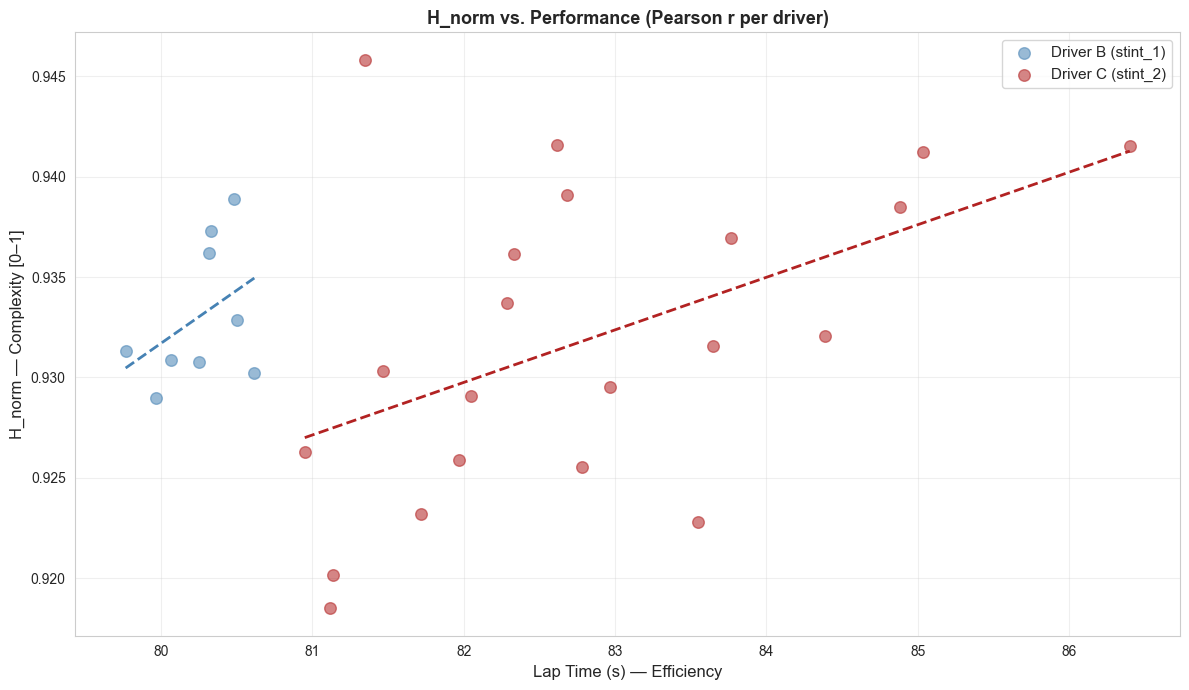

In [1040]:
def plot_entropy_correlation_v2(pilotos_lista):
    """H_norm per lap vs lap time — correlation with correct PMF."""
    all_data = []
    for label, stint, df in pilotos_lista:
        if df is None or df.empty: continue
        print(f"📉 Computing per-lap H_norm: {label} ({stint})")
        v_range = global_ranges.get('TotalAccel_G', (0, 3.0))
        for lap in df['Lap'].unique():
            subset   = df[df['Lap'] == lap]
            lap_time = subset['SessionTime'].max() - subset['SessionTime'].min()
            d        = subset['TotalAccel_G'].dropna().values
            if len(d) > 5:
                h_n, _, _ = compute_shannon_normalized(d, v_range)
                all_data.append({'Driver': f"{label} ({stint})",
                                  'Lap Time (s)': lap_time, 'H_norm': h_n})

    df_corr  = pd.DataFrame(all_data)
    median_t = df_corr['Lap Time (s)'].median()
    df_corr  = df_corr[df_corr['Lap Time (s)'] < median_t * 1.15]

    fig, ax = plt.subplots(figsize=(12, 7))
    colors  = {'steelblue': 0, 'firebrick': 1}
    palette = dict(zip(df_corr['Driver'].unique(), ['steelblue', 'firebrick']))

    for drv, grp in df_corr.groupby('Driver'):
        color = palette.get(drv, 'gray')
        ax.scatter(grp['Lap Time (s)'], grp['H_norm'], alpha=0.55, s=70, color=color,
                   label=drv, zorder=3)
        m, b = np.polyfit(grp['Lap Time (s)'], grp['H_norm'], 1)
        x_l  = np.linspace(grp['Lap Time (s)'].min(), grp['Lap Time (s)'].max(), 100)
        ax.plot(x_l, m * x_l + b, color=color, lw=2, ls='--')
        r, p = pearsonr(grp['Lap Time (s)'], grp['H_norm'])
        print(f"  {drv}: r={r:.3f}  p={p:.4e}")

    ax.set_xlabel('Lap Time (s) — Efficiency', fontsize=12)
    ax.set_ylabel('H_norm — Complexity [0–1]', fontsize=12)
    ax.set_title('H_norm vs. Performance (Pearson r per driver)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"correlation_hnorm_performance_{track_id}.pdf"
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    print(f"Saved plot to {fname}")
    plt.show()

plot_entropy_correlation_v2(pilotos_analise)

## 9. Entropia de Permutação (PE)

PE é calculada sobre **padrões ordinais** da série temporal — não pressupõe
estacionaridade. Ideal para os ~22% de setores que falham no ADF/KPSS.

PE_norm ∈ [0, 1]:
- PE ≈ 0 → sinal altamente repetitivo / ordenado
- PE ≈ 1 → sinal completamente aleatório

🔀 Calculando PE por setor  (order=3, delay=1, min_samples=5)
   10 setores × 4 variáveis

Sector             Variable                 PE_ref     ±σ  PE_test     ±σ      ΔPE  Interp.
────────────────────────────────────────────────────────────────────────────────────────────
1                  Combined G-Force         0.9940 0.0049   0.9929 0.0067  -0.0012  ⚪ similar

2                  Combined G-Force         0.9751 0.0047   0.9671 0.0112  -0.0080  ⚪ similar

3                  Combined G-Force         0.9607 0.0099   0.9690 0.0103   0.0084  ⚪ similar

4                  Combined G-Force         0.9641 0.0080   0.9687 0.0095   0.0046  ⚪ similar

5                  Combined G-Force         0.9539 0.0110   0.9658 0.0143   0.0119  ⚪ similar

6                  Combined G-Force         0.9510 0.0068   0.9518 0.0119   0.0008  ⚪ similar

7                  Combined G-Force         0.9439 0.0100   0.9457 0.0125   0.0018  ⚪ similar

8                  Combined G-Force         0.9695 0.0045   

C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\3962057636.py:173: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


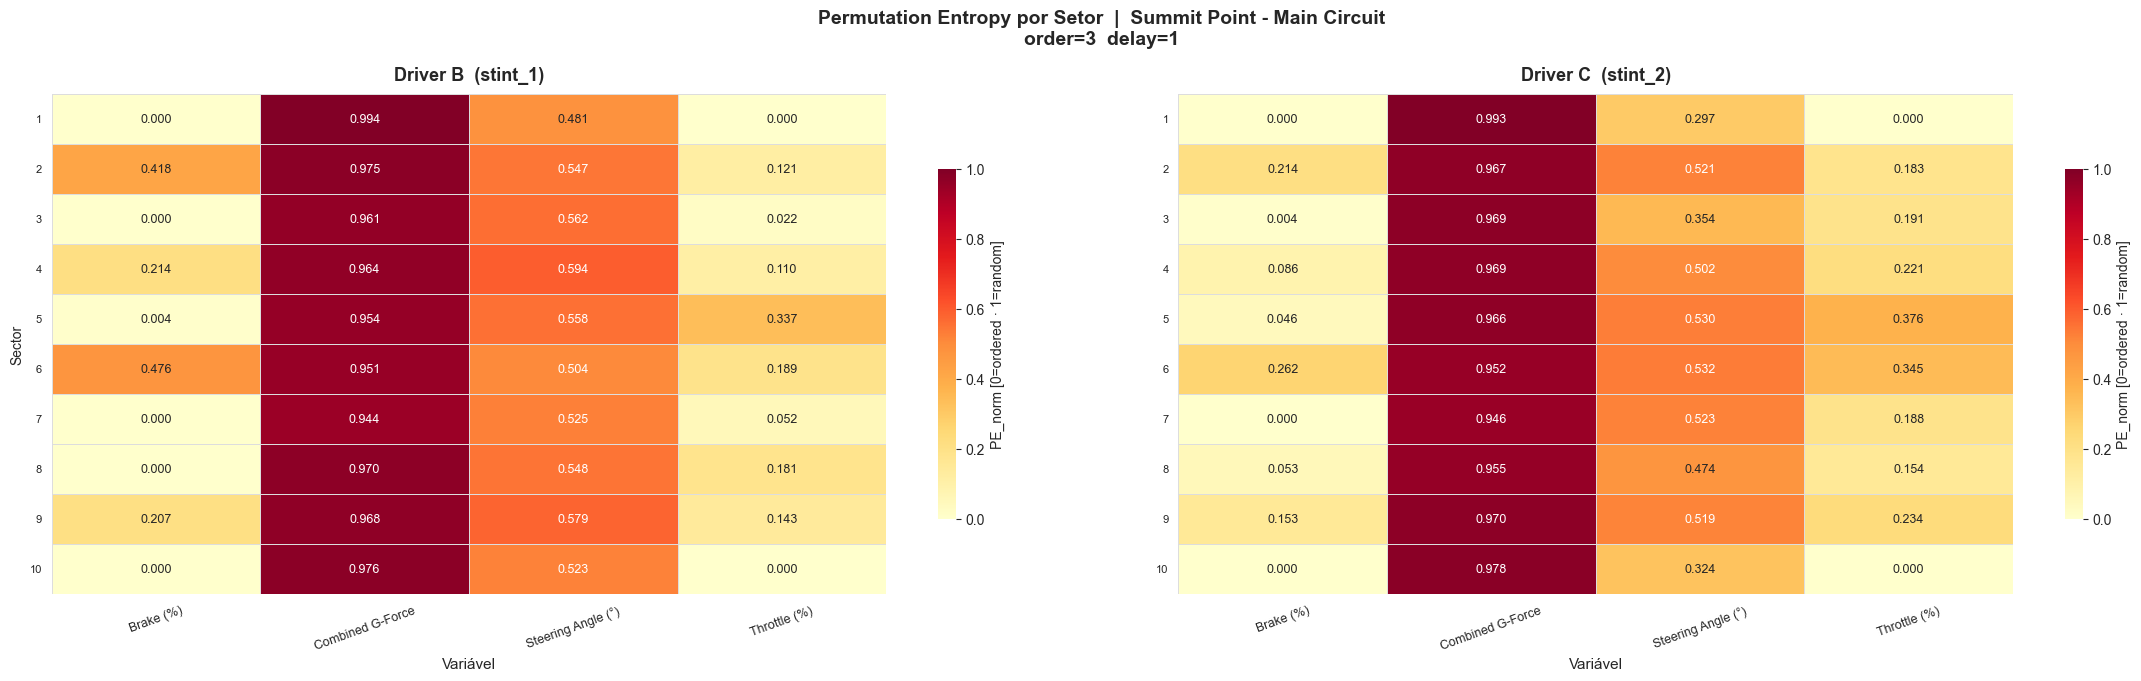

c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.draw()
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\3962057636.py:207: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig2.savefig(SAVE_DIR / f"delta_pe_heatmap_sectors_{TRACK}_{STINT_TEST}.pdf",
C:\Users\to_fi\AppData\Local\Temp\ipykernel_32668\3962057636.py:207: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) Arial.
  fig2.savefig(SAVE_DIR / f"delta_pe_heatmap_sectors_{TRACK}_{STINT_TEST}.pdf",
c:\Users\to_fi\anaconda3\envs\p_estocastico\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) Arial.
  fig.canvas.pr

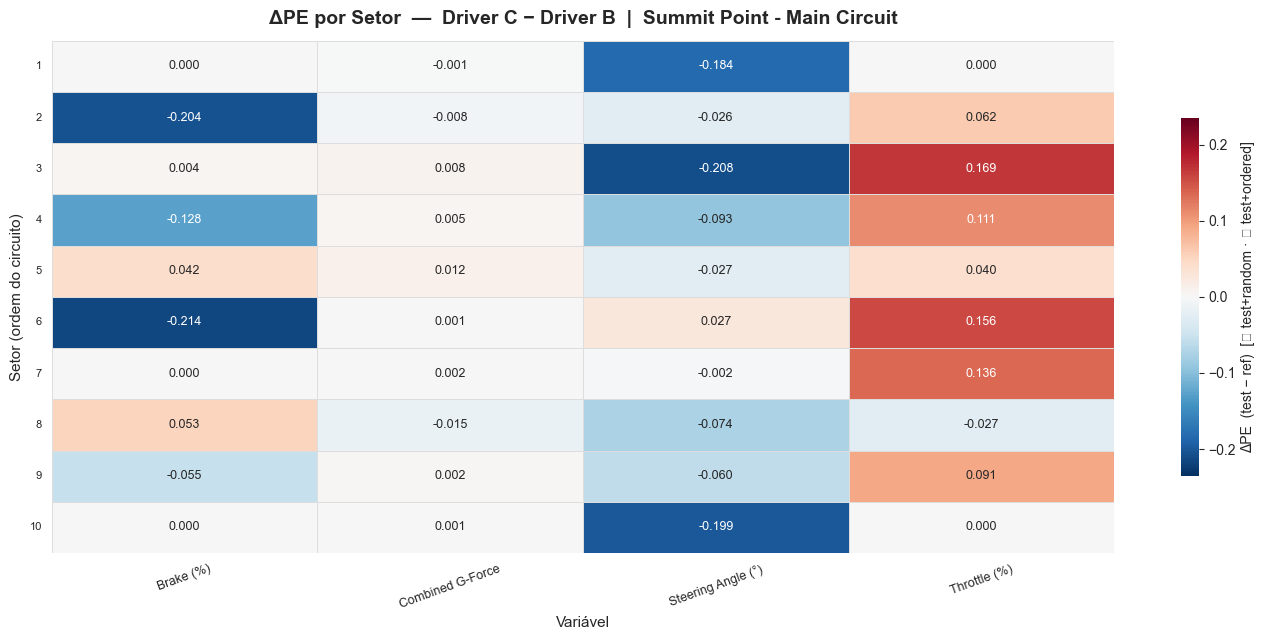


════════════════════════════════════════════════════════════════════════
  TABELA RESUMO — PE por Setor  (Driver B vs Driver C)
  Pista: Summit Point - Main Circuit  |  PE médio sobre 4 variáveis
════════════════════════════════════════════════════════════════════════


,Sector,PĒ Driver B,σ_ref,PĒ Driver C,σ_test,ΔPĒ,N vars,Behavior
0,1,0.3687,0.0178,0.3224,0.0216,-0.0462,4,⚪ similar
1,2,0.5152,0.0234,0.4713,0.0346,-0.0440,4,⚪ similar
2,3,0.3862,0.0155,0.3796,0.0448,-0.0066,4,⚪ similar
3,4,0.4708,0.0193,0.4444,0.0616,-0.0264,4,⚪ similar
4,5,0.4631,0.0274,0.4796,0.0492,0.0165,4,⚪ similar
5,6,0.5302,0.0293,0.5227,0.0436,-0.0074,4,⚪ similar
6,7,0.3802,0.0299,0.4141,0.0357,0.0339,4,⚪ similar
7,8,0.4246,0.0148,0.4091,0.0446,-0.0155,4,⚪ similar
8,9,0.4745,0.0247,0.4690,0.0368,-0.0054,4,⚪ similar
9,10,0.3748,0.0165,0.3254,0.0202,-0.0495,4,⚪ similar



  PE médio global — Driver B  : 0.4388
  PE médio global — Driver C : 0.4238
  ΔPE médio global              : -0.0151
  Setores com test+random       : 0
  Setores com test+ordered      : 0
════════════════════════════════════════════════════════════════════════

✅ Tabela completa salva: C:\Users\to_fi\OneDrive\Documents\GitHub\Doutorado\Racing4all\Iracing\img\summit_point\summit_point_Driver B_vs_Driver C\stint_1_vs_stint_2\entropy\pe_by_sector_summit_point_Driver B_vs_Driver C_stint_2.csv


In [1041]:
# ═══════════════════════════════════════════════════════════════════════════════
# v2  —  PERMUTATION ENTROPY POR SETOR
#         PE_norm ∈ [0, 1]  |  0 = padrão ordenado · 1 = máxima aleatoriedade
#         Calcula PE por volta dentro de cada setor → agrega (média ± dp)
# ═══════════════════════════════════════════════════════════════════════════════

if not ANTROPY_AVAILABLE:
    print("⚠  antropy não instalado.  Execute:  pip install antropy")
else:
    # ── Garantir DataFrames com coluna de setor ─────────────────────────────
    # Reutiliza df_ref_s / df_test_s da célula JSD por setor se disponíveis;
    # caso contrário, aplica assign_sectors novamente.
    if 'df_ref_s' not in vars() or SECTOR_COL not in df_ref_s.columns:
        df_ref_s  = assign_sectors(df_ref_clean.copy(),  CUSTOM_EDGES, SECTOR_NAMES)
        df_test_s = assign_sectors(df_test_clean.copy(), CUSTOM_EDGES, SECTOR_NAMES)
        SECTOR_COL = 'Sector' if 'Sector' in df_ref_s.columns else 'sector'

    sectors_present = [s for s in SECTOR_NAMES
                       if s in df_ref_s[SECTOR_COL].unique()]

    # ── Parâmetros ──────────────────────────────────────────────────────────
    PE_ORDER     = 3   # padrões ordinais de comprimento 3 (3! = 6 permutações)
    PE_DELAY     = 1   # atraso entre amostras consecutivas
    MIN_SAMPLES  = PE_ORDER * PE_DELAY + 2   # mínimo por lap×setor

    # ── Função auxiliar ─────────────────────────────────────────────────────
    def compute_pe_by_sector(df, target_col, sectors, sector_col,
                              order=3, delay=1, min_samples=5):
        """
        PE por volta dentro de cada setor → retorna dict com estatísticas.

        Fluxo por setor:
          1. Filtra df pelo setor (dados já em ordem cronológica)
          2. Para cada volta, extrai a série temporal do canal dentro do setor
          3. Calcula PE (normalize=True → PE ∈ [0, 1])
          4. Agrega: média, desvio-padrão, n_laps válidas
        """
        results = {}
        for sector in sectors:
            sector_df = (df[df[sector_col] == sector]
                           .sort_values(['Lap', 'SessionTime']))
            lap_pe = []
            for lap in sector_df['Lap'].unique():
                series = (sector_df[sector_df['Lap'] == lap][target_col]
                            .dropna().values)
                if len(series) >= min_samples:
                    pe_val = ant.perm_entropy(series, order=order,
                                              delay=delay, normalize=True)
                    lap_pe.append(float(pe_val))

            if lap_pe:
                results[sector] = {
                    'pe_mean': float(np.mean(lap_pe)),
                    'pe_std':  float(np.std(lap_pe)),
                    'pe_min':  float(np.min(lap_pe)),
                    'pe_max':  float(np.max(lap_pe)),
                    'n_laps':  len(lap_pe),
                }
            else:
                results[sector] = {
                    'pe_mean': np.nan, 'pe_std': np.nan,
                    'pe_min':  np.nan, 'pe_max': np.nan,
                    'n_laps':  0,
                }
        return results

    # ── Cálculo principal: setor × variável ─────────────────────────────────
    print(f"🔀 Calculando PE por setor  "
          f"(order={PE_ORDER}, delay={PE_DELAY}, min_samples={MIN_SAMPLES})")
    print(f"   {len(sectors_present)} setores × {len(VARIABLES_ENTROPY)} variáveis\n")

    rows_pe = []

    for col, label in VARIABLES_ENTROPY:
        if col not in df_ref_s.columns:
            print(f"  ⚠  {label}: coluna ausente — pulando"); continue

        pe_ref  = compute_pe_by_sector(df_ref_s,  col, sectors_present,
                                        SECTOR_COL, PE_ORDER, PE_DELAY, MIN_SAMPLES)
        pe_test = compute_pe_by_sector(df_test_s, col, sectors_present,
                                        SECTOR_COL, PE_ORDER, PE_DELAY, MIN_SAMPLES)

        for sector in sectors_present:
            r_stats = pe_ref[sector]
            t_stats = pe_test[sector]
            pe_r    = r_stats['pe_mean']
            pe_t    = t_stats['pe_mean']
            delta   = (pe_t - pe_r
                       if not (np.isnan(pe_r) or np.isnan(pe_t))
                       else np.nan)

            rows_pe.append({
                'Sector':          sector,
                'Variable':        label,
                'PE_ref':          round(pe_r, 4) if not np.isnan(pe_r) else np.nan,
                'PE_ref_std':      round(r_stats['pe_std'],  4),
                'PE_test':         round(pe_t, 4) if not np.isnan(pe_t) else np.nan,
                'PE_test_std':     round(t_stats['pe_std'],  4),
                'ΔPE (test−ref)':  round(delta, 4) if not np.isnan(delta) else np.nan,
                'n_laps_ref':      r_stats['n_laps'],
                'n_laps_test':     t_stats['n_laps'],
            })

    df_pe = pd.DataFrame(rows_pe)
    df_pe_valid = df_pe.dropna(subset=['PE_ref', 'PE_test'])

    # ── Impressão da tabela longa ────────────────────────────────────────────
    print(f"{'Sector':<18} {'Variable':<22} "
          f"{'PE_ref':>8} {'±σ':>6} {'PE_test':>8} {'±σ':>6} "
          f"{'ΔPE':>8}  Interp.")
    print("─" * 92)

    _prev = None
    for _, r in df_pe.iterrows():
        if r['Sector'] != _prev and _prev is not None:
            print()
        _prev = r['Sector']

        def _fmt(v): return f"{v:>8.4f}" if not pd.isna(v) else "     N/A"
        def _fms(v): return f"{v:>6.4f}" if not pd.isna(v) else "   N/A"

        if not pd.isna(r['ΔPE (test−ref)']):
            interp = ("🔴 test+random" if  r['ΔPE (test−ref)'] >  0.05 else
                      "🔵 test+ordered" if r['ΔPE (test−ref)'] < -0.05 else
                      "⚪ similar")
        else:
            interp = "⚪ N/A"

        print(f"{r['Sector']:<18} {r['Variable']:<22} "
              f"{_fmt(r['PE_ref'])} {_fms(r['PE_ref_std'])} "
              f"{_fmt(r['PE_test'])} {_fms(r['PE_test_std'])} "
              f"{_fmt(r['ΔPE (test−ref)'])}  {interp}")

    print("─" * 92)
    print("  ΔPE > +0.05 → test mais aleatório  |  ΔPE < −0.05 → test mais ordenado\n")

    # ── Figura 1: Heatmaps PE_ref | PE_test (lado a lado) ───────────────────
    pivot_ref  = (df_pe.pivot(index='Sector', columns='Variable', values='PE_ref')
                       .reindex(sectors_present))
    pivot_test = (df_pe.pivot(index='Sector', columns='Variable', values='PE_test')
                       .reindex(sectors_present))

    n_vars = len(VARIABLES_ENTROPY)
    n_sec  = len(sectors_present)
    w      = max(14, n_vars * 2.5)
    h      = max(6,  n_sec  * 0.65)

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(w * 2, h),
                                      gridspec_kw={'wspace': 0.08})

    hm_kw = dict(cmap='YlOrRd', vmin=0, vmax=1,
                 annot=True, fmt='.3f', annot_kws={'size': 9},
                 linewidths=0.4, linecolor='#dddddd',
                 cbar_kws={'label': 'PE_norm [0=ordered · 1=random]', 'shrink': 0.7})

    sns.heatmap(pivot_ref,  ax=ax_l, mask=pivot_ref.isna(),  **hm_kw)
    sns.heatmap(pivot_test, ax=ax_r, mask=pivot_test.isna(), **hm_kw)

    for ax_i, title in [(ax_l, f"{driver_a}  ({STINT_REF})"),
                         (ax_r, f"{driver_b}  ({STINT_TEST})")]:
        ax_i.set_title(title, fontsize=13, fontweight='bold', pad=10)
        ax_i.set_xlabel('Variável', fontsize=11)
        ax_i.tick_params(axis='x', labelsize=9, rotation=20)
        ax_i.tick_params(axis='y', labelsize=8, rotation=0)

    ax_r.set_ylabel('')   # remove duplicate y-label on right panel

    fig.suptitle(
        f"Permutation Entropy por Setor  |  {TRACK_NAME}\n"
        f"order={PE_ORDER}  delay={PE_DELAY}",
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    fig.savefig(SAVE_DIR / f"pe_heatmap_by_sector_{TRACK}.pdf",
                dpi=300, bbox_inches='tight')
    plt.show()

    # ── Figura 2: Heatmap ΔPE ───────────────────────────────────────────────
    pivot_dpe = (df_pe.pivot(index='Sector', columns='Variable', values='ΔPE (test−ref)')
                      .reindex(sectors_present))

    vabs = max(0.05, pivot_dpe.abs().max().max() * 1.1
               if not pivot_dpe.isna().all().all() else 0.2)

    fig2, ax2 = plt.subplots(figsize=(w, h))
    sns.heatmap(
        pivot_dpe, ax=ax2,
        cmap='RdBu_r',
        vmin=-vabs, vmax=vabs, center=0,
        annot=True, fmt='.3f', annot_kws={'size': 9},
        linewidths=0.4, linecolor='#dddddd',
        mask=pivot_dpe.isna(),
        cbar_kws={
            'label': 'ΔPE  (test − ref)  [🔴 test+random · 🔵 test+ordered]',
            'shrink': 0.7
        }
    )
    ax2.set_title(
        f"ΔPE por Setor  —  {driver_b} − {driver_a}  |  {TRACK_NAME}",
        fontsize=14, fontweight='bold', pad=12
    )
    ax2.set_xlabel('Variável', fontsize=11)
    ax2.set_ylabel('Setor (ordem do circuito)', fontsize=11)
    ax2.tick_params(axis='x', labelsize=9, rotation=20)
    ax2.tick_params(axis='y', labelsize=8, rotation=0)
    plt.tight_layout()
    fig2.savefig(SAVE_DIR / f"delta_pe_heatmap_sectors_{TRACK}_{STINT_TEST}.pdf",
                 dpi=300, bbox_inches='tight')
    plt.show()

    # ── Tabela resumo por setor (média das variáveis) ────────────────────────
    sector_pe_summary = (
        df_pe_valid
        .groupby('Sector')
        .agg(
            PE_ref_mean  =('PE_ref',         'mean'),
            PE_ref_std   =('PE_ref_std',      'mean'),
            PE_test_mean =('PE_test',         'mean'),
            PE_test_std  =('PE_test_std',     'mean'),
            dPE_mean     =('ΔPE (test−ref)', 'mean'),
            n_vars       =('Variable',        'count'),
        )
        .round(4)
        .reindex(sectors_present)   # ordem do circuito
        .reset_index()
    )

    sector_pe_summary['Behavior'] = sector_pe_summary['dPE_mean'].apply(
        lambda x: "🔴 test+random"  if x >  0.05 else
                  "🔵 test+ordered" if x < -0.05 else
                  "⚪ similar"      if not np.isnan(x) else "⚪ N/A")

    print("\n" + "═" * 72)
    print(f"  TABELA RESUMO — PE por Setor  ({driver_a} vs {driver_b})")
    print(f"  Pista: {TRACK_NAME}  |  PE médio sobre {len(VARIABLES_ENTROPY)} variáveis")
    print("═" * 72)
    display(sector_pe_summary.rename(columns={
        'PE_ref_mean':  f'PĒ {driver_a}',
        'PE_ref_std':   'σ_ref',
        'PE_test_mean': f'PĒ {driver_b}',
        'PE_test_std':  'σ_test',
        'dPE_mean':     'ΔPĒ',
        'n_vars':       'N vars',
    }))

    print(f"\n  PE médio global — {driver_a}  : "
          f"{df_pe_valid['PE_ref'].mean():.4f}")
    print(f"  PE médio global — {driver_b} : "
          f"{df_pe_valid['PE_test'].mean():.4f}")
    print(f"  ΔPE médio global              : "
          f"{df_pe_valid['ΔPE (test−ref)'].mean():+.4f}")
    print(f"  Setores com test+random       : "
          f"{(sector_pe_summary['dPE_mean'] > 0.05).sum()}")
    print(f"  Setores com test+ordered      : "
          f"{(sector_pe_summary['dPE_mean'] < -0.05).sum()}")
    print("═" * 72)

    # Salva CSV
    csv_pe = SAVE_DIR / f"pe_by_sector_{TRACK}_{driver_a}_vs_{driver_b}_{STINT_TEST}.csv"
    df_pe.to_csv(csv_pe, index=False)
    print(f"\n✅ Tabela completa salva: {csv_pe}")

🔀 Preparando dados para correlação ΔPE × Δ Time Loss...
 ↳ Setores com dados completos para correlação: 10


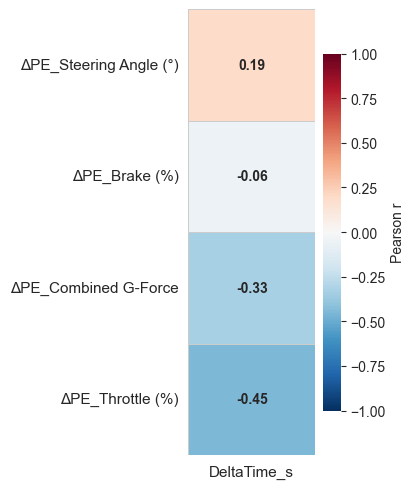


═══════════════════════════════════════════════════════════════════════════
  CORRELAÇÃO ΔPE × Δ Time Loss  —  Driver B vs Driver C  |  Summit Point - Main Circuit
═══════════════════════════════════════════════════════════════════════════


,Variável,Pearson r,p-value,Força
3,Throttle (%),-0.449,0.193,|r| > 0.3 → Moderada
1,Combined G-Force,-0.329,0.353,|r| > 0.3 → Moderada
2,Steering Angle (°),0.191,0.598,Fraca
0,Brake (%),-0.061,0.866,Fraca



 ↳ Variável com entropia mais correlacionada ao tempo: Throttle (%) (r = -0.449)


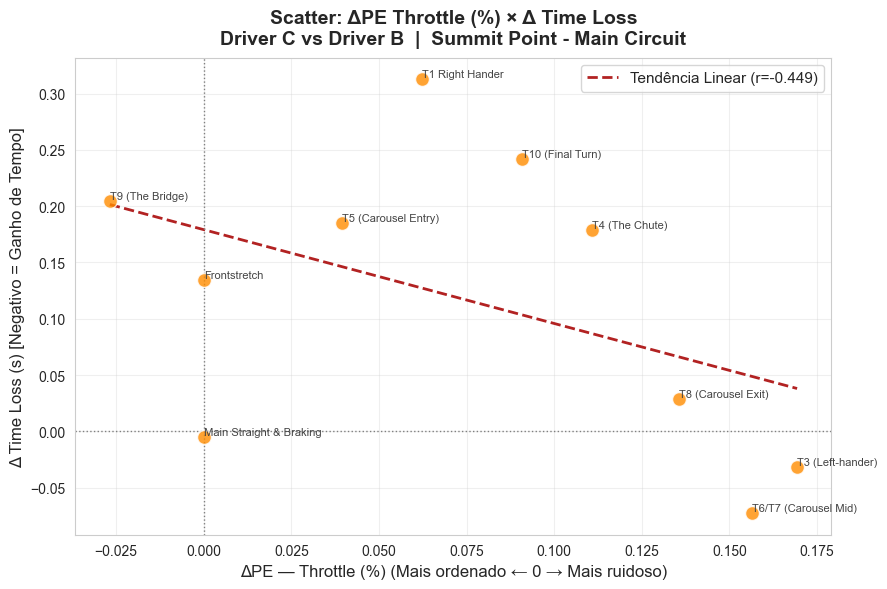

In [1042]:
# ══════════════════════════════════════════════════════════════════════════
#  Seção 12 — Correlação ΔPE × Δ Time Loss
#  Depende de:
#    • df_pe         (tabela longa gerada na seção de Permutation Entropy)
#    • df_delta      (calculado na seção 11 — perdas de tempo por setor)
#    • SECTOR_NAMES, SAVE_DIR, TRACK, driver_a, driver_b
# ══════════════════════════════════════════════════════════════════════════

from scipy.stats import pearsonr
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("🔀 Preparando dados para correlação ΔPE × Δ Time Loss...")

# ── 1. Pivotar a tabela de PE: uma linha por setor, uma coluna por variável ──
# Filtramos apenas as linhas com ΔPE válido
df_dpe_clean = df_pe.dropna(subset=['ΔPE (test−ref)']).copy()

dpe_pivot = (df_dpe_clean.pivot(index='Sector', columns='Variable', values='ΔPE (test−ref)')
             .reset_index())

# Renomear as colunas para facilitar a identificação
dpe_pivot.columns = ['Sector'] + [f'ΔPE_{c}' for c in dpe_pivot.columns[1:]]

# ── 2. Merge com os dados de Δ Time Loss ────────────────────────────────────
if 'df_delta' not in vars():
    raise NameError("⚠ A variável 'df_delta' não foi encontrada. Certifique-se de rodar a Seção 11 primeiro.")

df_pe_corr = dpe_pivot.merge(df_delta, on='Sector').dropna()
dpe_cols = [c for c in df_pe_corr.columns if c.startswith('ΔPE_')]
target   = 'DeltaTime_s'
all_cols_pe = dpe_cols + [target]
n_valid_pe  = len(df_pe_corr)

print(f" ↳ Setores com dados completos para correlação: {n_valid_pe}")

# ── 3. Matriz de Correlação de Pearson (Focada no Target) ───────────────────
# Calcula a correlação completa com todas as colunas
corr_completa = df_pe_corr[all_cols_pe].corr(method='pearson')

# Filtra: pega apenas as linhas das variáveis PE e apenas a coluna do Target
# Em seguida, ordena do maior para o menor para facilitar a visualização
corr_target = corr_completa.loc[dpe_cols, [target]].sort_values(by=target, ascending=False)

# ── 4. Plot: Heatmap de Correlação ──────────────────────────────────────────
# A figura agora pode ser mais estreita e alta (ex: 1 coluna x várias linhas)
fig_corr, ax_corr = plt.subplots(figsize=(4, max(5, len(dpe_cols) * 0.8)))

hm_kw_pe = dict(
    annot=True, fmt='.2f', annot_kws={'size': 10, 'weight': 'bold'},
    cmap='RdBu_r', vmin=-1, vmax=1, center=0,
    linewidths=0.5, linecolor='#cccccc',
    cbar_kws={'label': 'Pearson r', 'shrink': 0.8}
)

sns.heatmap(corr_target, ax=ax_corr, **hm_kw_pe)

# Rotacionar os eixos para facilitar a leitura no formato vertical
ax_corr.tick_params(axis='x', labelsize=11, rotation=0)
ax_corr.tick_params(axis='y', labelsize=11, rotation=0)

plt.tight_layout()
fig_corr.savefig(SAVE_DIR / f"delta_pe_vs_deltaloss_correlation_{TRACK}_{STINT_TEST}.pdf",
            dpi=300, bbox_inches='tight')
plt.show()

# ── 5. Tabela Resumo da Correlação ──────────────────────────────────────────
summary_rows_pe = []
for col in dpe_cols:
    r_p, p_p   = pearsonr(df_pe_corr[col], df_pe_corr[target])
    var_label  = col.replace('ΔPE_', '')
    strength   = ("|r| > 0.5 → Forte" if abs(r_p) >= 0.5 else 
                  "|r| > 0.3 → Moderada" if abs(r_p) >= 0.3 else "Fraca")
    
    summary_rows_pe.append({
        'Variável': var_label,
        'Pearson r': round(r_p, 3), 
        'p-value': round(p_p, 3),
        'Força': strength
    })

df_summary_pe = (pd.DataFrame(summary_rows_pe)
                 .sort_values('Pearson r', key=abs, ascending=False))

print("\n" + "═" * 75)
print(f"  CORRELAÇÃO ΔPE × Δ Time Loss  —  {driver_a} vs {driver_b}  |  {TRACK_NAME}")
print("═" * 75)
display(df_summary_pe)

# ── 6. Plot: Scatter da Variável de Maior Influência ────────────────────────
best_var_pe  = df_summary_pe.iloc[0]['Variável']
best_r_pe    = df_summary_pe.iloc[0]['Pearson r']
best_col_pe  = f'ΔPE_{best_var_pe}'

print(f"\n ↳ Variável com entropia mais correlacionada ao tempo: {best_var_pe} (r = {best_r_pe:+.3f})")

fig_scat, ax_scat = plt.subplots(figsize=(9, 6))

for _, row in df_pe_corr.iterrows():
    ax_scat.scatter(row[best_col_pe], row[target], s=100, color='darkorange', alpha=0.8, edgecolor='white', zorder=3)
    # Anotar o número do setor em cada ponto
    sector_label = SECTOR_NAMES.get(int(row['Sector']), str(row['Sector']))
    ax_scat.annotate(sector_label, (row[best_col_pe], row[target]),
                 fontsize=8, ha='left', va='bottom', color='#444444')

# Linha de tendência (OLS)
_x = df_pe_corr[best_col_pe].values
_y = df_pe_corr[target].values
valid_mask = np.isfinite(_x) & np.isfinite(_y)

if valid_mask.sum() > 1:
    _m, _b = np.polyfit(_x[valid_mask], _y[valid_mask], 1)
    _xs = np.linspace(_x[valid_mask].min(), _x[valid_mask].max(), 50)
    ax_scat.plot(_xs, _m * _xs + _b, color='firebrick', lw=2, ls='--',
             label=f'Tendência Linear (r={best_r_pe:+.3f})')

ax_scat.axhline(0, color='gray', ls=':', lw=1)
ax_scat.axvline(0, color='gray', ls=':', lw=1)

ax_scat.set_xlabel(f'ΔPE — {best_var_pe} (Mais ordenado ← 0 → Mais ruidoso)', fontsize=12)
ax_scat.set_ylabel('Δ Time Loss (s) [Negativo = Ganho de Tempo]', fontsize=12)
ax_scat.set_title(f'Scatter: ΔPE {best_var_pe} × Δ Time Loss\n'
              f'{driver_b} vs {driver_a}  |  {TRACK_NAME}',
              fontsize=14, fontweight='bold', pad=10)

ax_scat.legend(fontsize=11)
ax_scat.grid(True, alpha=0.3)

plt.tight_layout()
fig_scat.savefig(SAVE_DIR / f"delta_pe_{best_var_pe.lower().replace(' ','_')}_vs_deltaloss_scatter_{TRACK}_{STINT_TEST}.pdf",
             dpi=300, bbox_inches='tight')
plt.show()

## 10. Entropia de Transferência T(Freio → Direção)

T(Brake→Steering) mede quanto o **estado passado do freio** reduz a incerteza sobre
o estado **futuro da direção** — além do que a direção passada já reduz sozinha.

**Interpretação física:**
- T alto → piloto usa trail braking acoplado: freio e curva sobrepostos (técnica expert)
- T baixo → canais desacoplados: freia antes, direciona depois (técnica novato)

Implementação via entropia condicional (sem dependências externas):

$$T(X \rightarrow Y) = H(Y_t | Y_{t-1}) - H(Y_t | Y_{t-1}, X_{t-1})$$

🔗 Transfer Entropy T(Brake → Steering):
  Driver B (stint_1): mean T(Brake_Pct→SteeringWheelAngle) = 0.0029 bits
  Driver C (stint_2): mean T(Brake_Pct→SteeringWheelAngle) = 0.0021 bits


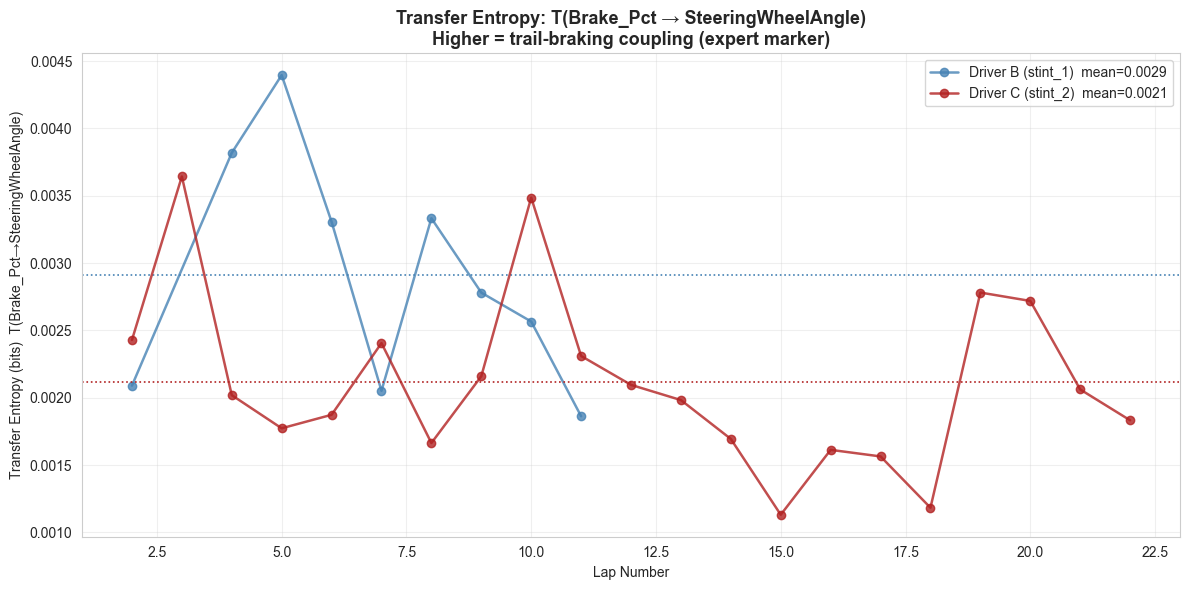


🔗 Transfer Entropy T(Throttle → Steering):
  Driver B (stint_1): mean T(Throttle_Pct→SteeringWheelAngle) = 0.0058 bits
  Driver C (stint_2): mean T(Throttle_Pct→SteeringWheelAngle) = 0.0065 bits


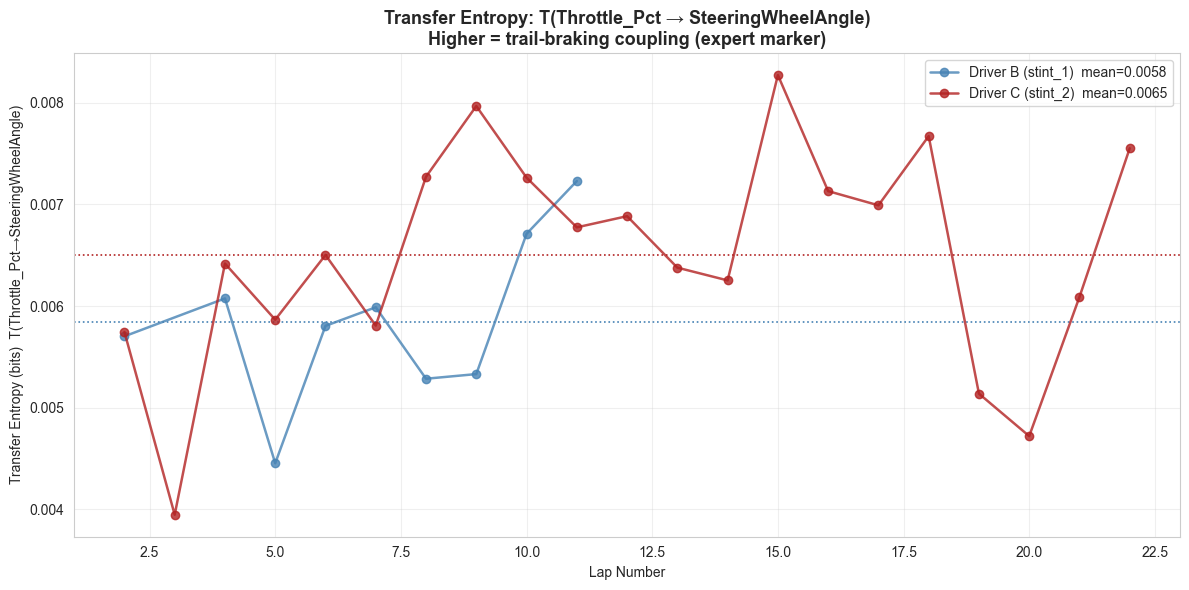

In [1043]:
def _discretize(arr: np.ndarray, n_bins: int) -> np.ndarray:
    """Uniform binning → integer labels for TE calculation."""
    edges = np.linspace(arr.min() - 1e-10, arr.max() + 1e-10, n_bins + 1)
    return np.digitize(arr, edges[1:-1])


def transfer_entropy(source: np.ndarray, target: np.ndarray,
                     n_bins: int = 5, lag: int = 1) -> float:
    """
    Transfer entropy T(source → target) in bits.

    T(X→Y) = H(Y_future | Y_past) - H(Y_future | Y_past, X_past)

    Computed via joint frequency tables (histogram method).
    Returns value in bits [0, ∞) — 0 means no information flow.
    """
    min_len = min(len(source), len(target))
    source  = _discretize(source[:min_len], n_bins)
    target  = _discretize(target[:min_len], n_bins)

    y_fut   = target[lag:]
    y_past  = target[:-lag]
    x_past  = source[:-lag]

    def joint_counts(*arrays):
        c = Counter(zip(*arrays))
        total = sum(c.values())
        return {k: v / total for k, v in c.items()}

    def marginal_counts(*arrays):
        return joint_counts(*arrays)

    p_yf_yp    = joint_counts(y_fut, y_past)
    p_yp       = marginal_counts(y_past)
    p_yf_yp_xp = joint_counts(y_fut, y_past, x_past)
    p_yp_xp    = marginal_counts(y_past, x_past)

    # H(Y_fut | Y_past)
    h_y_given_ypast = sum(
        -p * np.log2(p / p_yp.get((b,), 1e-12))
        for (a, b), p in p_yf_yp.items())

    # H(Y_fut | Y_past, X_past)
    h_y_given_ypast_xpast = sum(
        -p * np.log2(p / p_yp_xp.get((b, c), 1e-12))
        for (a, b, c), p in p_yf_yp_xp.items())

    return max(0.0, h_y_given_ypast - h_y_given_ypast_xpast)


def compute_te_comparison(df_ref, df_test,
                           source_col='Brake_Pct',
                           target_col='SteeringWheelAngle',
                           n_bins: int = 5, lag: int = 1):
    """Computes T(source→target) per lap for both drivers and plots."""
    results = []
    for name, stint, df in [(driver_a, STINT_REF, df_ref),
                              (driver_b, STINT_TEST, df_test)]:
        lap_te = []
        for lap in df['Lap'].unique():
            ld = df[df['Lap'] == lap].sort_values('SessionTime')
            src = ld[source_col].dropna().values
            tgt = ld[target_col].dropna().values
            min_len = min(len(src), len(tgt))
            if min_len > 20:
                te_val = transfer_entropy(src[:min_len], tgt[:min_len], n_bins, lag)
                lap_te.append({'Lap': lap, 'TE': te_val, 'Driver': f'{name} ({stint})'})
        results.extend(lap_te)
        if lap_te:
            mean_te = np.mean([r['TE'] for r in lap_te])
            print(f"  {name} ({stint}): mean T({source_col}→{target_col}) = {mean_te:.4f} bits")

    if not results:
        print("⚠  Insufficient data for TE calculation.")
        return

    df_te = pd.DataFrame(results)
    fig, ax = plt.subplots(figsize=(12, 6))
    palette = dict(zip(df_te['Driver'].unique(), ['steelblue', 'firebrick']))
    for drv, grp in df_te.groupby('Driver'):
        color = palette.get(drv, 'gray')
        ax.plot(grp['Lap'], grp['TE'], 'o-', color=color, lw=1.8, ms=6,
                alpha=0.8, label=f'{drv}  mean={grp["TE"].mean():.4f}')
        ax.axhline(grp['TE'].mean(), color=color, ls=':', lw=1.2)

    ax.set_xlabel('Lap Number')
    ax.set_ylabel(f'Transfer Entropy (bits)  T({source_col}→{target_col})')
    ax.set_title(f'Transfer Entropy: T({source_col} → {target_col})\n'
                 f'Higher = trail-braking coupling (expert marker)',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"transfer_entropy_{source_col.lower()}_to_{target_col.lower()}_{TRACK}.pdf"
    fig.savefig(SAVE_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

print("🔗 Transfer Entropy T(Brake → Steering):")
compute_te_comparison(df_ref_clean, df_test_clean,
                       source_col='Brake_Pct', target_col='SteeringWheelAngle')

print("\n🔗 Transfer Entropy T(Throttle → Steering):")
compute_te_comparison(df_ref_clean, df_test_clean,
                       source_col='Throttle_Pct', target_col='SteeringWheelAngle')

## 11. Testes Estatísticos — Mann-Whitney U

**Por que Mann-Whitney?**
- Não pressupõe normalidade da distribuição de H_norm por volta
- Válido mesmo com n=10–20 voltas por driver (pequeno tamanho amostral)
- Effect size r = U / (n₁ × n₂) ∈ [0, 1] — reportável na revista

Hipótese nula H₀: as distribuições per-lap de H_norm dos dois drivers são idênticas.

In [1044]:
def test_entropy_differences(df_ref, df_test, variables, global_ranges_dict):
    """
    Mann-Whitney U test on per-lap H_norm distributions.
    Reportable in Entropy journal: stat, p-value, effect size r.
    """
    print(f"\n{'Variable':<22} {'H̄_ref':>10} {'H̄_test':>10} "
          f"{'U stat':>10} {'p-value':>12} {'r (effect)':>12}  Significant?")
    print("─" * 88)

    rows = []
    for col, label in variables:
        v_range = global_ranges_dict.get(col)
        if v_range is None or col not in df_ref.columns: continue

        def per_lap_h(df):
            results = []
            for lap in df['Lap'].unique():
                d = df[df['Lap'] == lap][col].dropna().values
                if len(d) > 5:
                    h_n, _, _ = compute_shannon_normalized(d, v_range)
                    results.append(h_n)
            return np.array(results)

        h_ref  = per_lap_h(df_ref)
        h_test = per_lap_h(df_test)

        if len(h_ref) < 3 or len(h_test) < 3:
            print(f"{label:<22} Insufficient laps — skipping"); continue

        stat, p = mannwhitneyu(h_ref, h_test, alternative='two-sided')
        r       = stat / (len(h_ref) * len(h_test))  # effect size
        sig     = "✅ YES" if p < 0.05 else "❌ no"

        print(f"{label:<22} {h_ref.mean():>10.4f} {h_test.mean():>10.4f} "
              f"{stat:>10.1f} {p:>12.4e} {r:>12.4f}  {sig}")
        rows.append({'Variable': label,
                     f'H̄_norm {driver_a}': round(h_ref.mean(), 4),
                     f'H̄_norm {driver_b}': round(h_test.mean(), 4),
                     'U stat': stat, 'p-value': p,
                     'Effect size r': round(r, 4),
                     'p < 0.05': p < 0.05})

    df_stats = pd.DataFrame(rows)
    print("─" * 88)
    print("  Effect size r: 0.1=small  0.3=medium  0.5=large")
    display(df_stats)
    return df_stats

df_stats = test_entropy_differences(df_ref_clean, df_test_clean,
                                     VARIABLES_ENTROPY, global_ranges)


Variable                   H̄_ref    H̄_test     U stat      p-value   r (effect)  Significant?
────────────────────────────────────────────────────────────────────────────────────────
Combined G-Force           0.9330     0.9319      103.0   7.1731e-01       0.5450  ❌ no
Throttle (%)               0.3321     0.4754        2.0   3.1330e-05       0.0106  ✅ YES
Brake (%)                  0.2475     0.1631      189.0   2.0990e-05       1.0000  ✅ YES
Steering Angle (°)         0.7713     0.7707       95.0   1.0000e+00       0.5026  ❌ no
────────────────────────────────────────────────────────────────────────────────────────
  Effect size r: 0.1=small  0.3=medium  0.5=large


,Variable,H̄_norm Driver B,H̄_norm Driver C,U stat,p-value,Effect size r,p < 0.05
0,Combined G-Force,0.9330,0.9319,103.0,0.717314,0.5450,False
1,Throttle (%),0.3321,0.4754,2.0,0.000031,0.0106,True
2,Brake (%),0.2475,0.1631,189.0,0.000021,1.0000,True
3,Steering Angle (°),0.7713,0.7707,95.0,1.000000,0.5026,False


## 12. Tabela Resumo Final — Todas as Métricas

In [1045]:
def generate_comprehensive_summary(pilotos_lista, variables, global_ranges_dict):
    """
    Consolidated table: performance + H_norm + PE + per-driver.
    """
    summary_rows = []

    for label, stint, df in pilotos_lista:
        if df is None or df.empty: continue

        lap_durs  = df.groupby('Lap')['SessionTime'].agg(lambda x: x.max() - x.min())
        clean_dur = lap_durs[lap_durs < lap_durs.median() * 1.1]

        row = {
            'Driver':        label,
            'Stint':         stint,
            'N valid laps':  len(clean_dur),
            'Best Lap (s)':  round(clean_dur.min(), 3),
            'Avg Lap (s)':   round(clean_dur.mean(), 3),
            'Std Lap (s)':   round(clean_dur.std(), 3),
        }

        for col, col_label in variables:
            v_range = global_ranges_dict.get(col)
            if v_range is None or col not in df.columns:
                row[f'H̄_norm {col_label}'] = np.nan
                row[f'PE {col_label}']      = np.nan
                continue

            lap_h, lap_pe = [], []
            for lap in clean_dur.index:
                d = df[df['Lap'] == lap][col].dropna().values
                if len(d) > 5:
                    h_n, _, _ = compute_shannon_normalized(d, v_range)
                    lap_h.append(h_n)
                    if ANTROPY_AVAILABLE and len(d) > 10:
                        pe = ant.perm_entropy(d, order=3, delay=1, normalize=True)
                        lap_pe.append(float(pe))

            row[f'H̄_norm {col_label}'] = round(np.mean(lap_h),  4) if lap_h  else np.nan
            row[f'PE {col_label}']      = round(np.mean(lap_pe), 4) if lap_pe else np.nan

        # Pearson r: H_norm vs lap time (TotalAccel_G)
        col_g   = 'TotalAccel_G'
        v_range = global_ranges_dict.get(col_g)
        if v_range and col_g in df.columns:
            lap_metrics = []
            for lap in clean_dur.index:
                d = df[df['Lap'] == lap][col_g].dropna().values
                if len(d) > 5:
                    h_n, _, _ = compute_shannon_normalized(d, v_range)
                    lap_metrics.append({'Time': clean_dur[lap], 'H_norm': h_n})
            if len(lap_metrics) >= 3:
                df_m  = pd.DataFrame(lap_metrics)
                r, p  = pearsonr(df_m['Time'], df_m['H_norm'])
                row['r (H_norm vs LapTime)'] = round(r, 3)
                row['p-value']               = round(p, 4)

        summary_rows.append(row)

    df_final = pd.DataFrame(summary_rows)
    return df_final

df_final = generate_comprehensive_summary(pilotos_analise, VARIABLES_ENTROPY, global_ranges)
print("\n📋 Comprehensive Summary Table — v2")
display(df_final)




📋 Comprehensive Summary Table — v2


,Driver,Stint,N valid laps,Best Lap (s),Avg Lap (s),Std Lap (s),H̄_norm Combined G-Force,PE Combined G-Force,H̄_norm Throttle (%),PE Throttle (%),H̄_norm Brake (%),PE Brake (%),H̄_norm Steering Angle (°),PE Steering Angle (°),r (H_norm vs LapTime),p-value
0,Driver B,stint_1,9,79.767,80.256,0.276,0.9330,0.9688,0.3321,0.1377,0.2475,0.2035,0.7713,0.5638,0.413,0.2695
1,Driver C,stint_2,21,80.950,82.813,1.465,0.9319,0.9690,0.4754,0.2214,0.1631,0.1183,0.7707,0.4920,0.493,0.0230


## 13. Pipeline Completo — Todas as Pistas

In [1046]:
def preprocess_ibt_dataframe(df):
    """Adds LocalLapTime and TotalAccel_G columns."""
    df = df.copy()
    df.sort_values(['Lap', 'SessionTime'], inplace=True)
    df['LocalLapTime'] = df.groupby('Lap')['SessionTime'].transform(lambda x: x - x.min())
    if 'TotalAccel_G' not in df.columns:
        lat_g = df.get('LatAccel', pd.Series(0, index=df.index)) / 9.81
        lon_g = df.get('LongAccel', pd.Series(0, index=df.index)) / 9.81
        df['TotalAccel_G'] = np.sqrt(lat_g**2 + lon_g**2)
    return df


INVALID_LAPS = set()
all_summaries = []

print("🚀 Full pipeline — all tracks/drivers")

for track_key, config in DATASETS.items():
    base_path           = Path(config['base_path'])
    track_pilotos       = []

    print(f"\n🏁 Track: {track_key.upper()}")

    for driver, stints in config['sessions'].items():
        for stint_name, file_names in stints.items():
            if isinstance(file_names, str): file_names = [file_names]
            full_paths  = [base_path / f for f in file_names]
            valid_paths = [p for p in full_paths if p.exists()]
            if not valid_paths:
                print(f"  ⚠  No files: {driver} ({stint_name})"); continue

            print(f"  📥 Loading: {driver} ({stint_name}) — {len(valid_paths)} file(s)")
            df_raw = load_from_ibt(valid_paths)
            if df_raw.empty: continue
            df_cleaned     = basic_clean_and_units(df_raw)
            validity_table = build_lap_validity_table(df_cleaned, manual_invalid=INVALID_LAPS)
            valid_laps     = validity_table.loc[validity_table['Valid'], 'Lap'].tolist()
            df_clean       = df_cleaned[df_cleaned['Lap'].isin(valid_laps)].copy()
            if df_clean.empty: continue
            df_clean = preprocess_ibt_dataframe(df_clean)
            track_pilotos.append((driver, stint_name, df_clean))
            print(f"     ✅ {len(valid_laps)} valid laps")

    if track_pilotos:
        track_summary = generate_comprehensive_summary(
            track_pilotos, VARIABLES_ENTROPY, global_ranges)
        track_summary['Track'] = track_key
        track_summary['Car']   = config.get('car', 'N/A')
        all_summaries.append(track_summary)

if all_summaries:
    final_table = pd.concat(all_summaries, ignore_index=True)
    display(final_table)
    

🚀 Full pipeline — all tracks/drivers

🏁 Track: CHARLOTTE_ROVAL_2025
  📥 Loading: Tomaz (stint_1) — 1 file(s)
    [1/1] Loading mx5 mx52016_charlotte 2025 roval2025 2025-11-26 13-56-41.ibt … OK (179,705 samples, laps 0–28)
──────────────────────────────────────────────────────────────
  Lap Validity Report  (29 laps total)
──────────────────────────────────────────────────────────────
  ✅ Valid   : 25 laps
  🏆 Fastest : Lap 19  (01:36.733)
  ❌ Invalid : 4 laps
     Lap   0  48:37.467  → FracLowSpeed=0.30 | LapTime=2917.5s | GPS=95.0%<100%
     Lap   5  01:40.250  → IQR_outlier
     Lap  10  01:48.733  → IQR_outlier
     Lap  28  02:57.883  → FracLowSpeed=0.44 | LapTime=177.9s
──────────────────────────────────────────────────────────────
     ✅ 25 valid laps
  📥 Loading: Tomaz (stint_2) — 2 file(s)
    [1/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 17-16-27.ibt … OK (100,476 samples, laps 0–16)
    [2/2] Loading mx5 mx52016_charlotte 2025 roval2025 2026-03-01 16-20-04.ibt

,Driver,Stint,N valid laps,Best Lap (s),Avg Lap (s),Std Lap (s),H̄_norm Combined G-Force,PE Combined G-Force,H̄_norm Throttle (%),PE Throttle (%),H̄_norm Brake (%),PE Brake (%),H̄_norm Steering Angle (°),PE Steering Angle (°),r (H_norm vs LapTime),p-value,Track,Car
0,Tomaz,stint_1,25,96.733,97.875,0.671,0.9463,0.9870,0.4152,0.1157,0.2183,0.1724,0.7813,0.6015,-0.209,0.3171,charlotte_roval_2025,Mazda MX-5
1,Tomaz,stint_2,32,97.050,99.736,3.309,0.9404,0.9876,0.3719,0.1309,0.2137,0.1649,0.8017,0.5923,-0.344,0.0541,charlotte_roval_2025,Mazda MX-5
2,Morsinaldo,stint_1,13,99.000,101.805,3.648,0.9403,0.9859,0.4409,0.1710,0.1687,0.1451,0.8071,0.5506,0.049,0.8738,charlotte_roval_2025,Mazda MX-5
3,Morsinaldo,stint_2,12,98.417,102.921,4.655,0.9444,0.9820,0.4789,0.2037,0.1931,0.1463,0.7747,0.5418,-0.609,0.0355,charlotte_roval_2025,Mazda MX-5
4,Rodrigo,stint_1,36,95.483,97.567,2.281,0.9492,0.9855,0.3410,0.1191,0.2058,0.2241,0.7771,0.6275,-0.379,0.0226,charlotte_roval_2025,Mazda MX-5
5,Tomaz,stint_1,9,79.767,80.256,0.276,0.9330,0.9688,0.3321,0.1377,0.2475,0.2035,0.7713,0.5638,0.413,0.2695,summit_point,Toyota GR86
6,Morsinaldo,stint_1,4,82.500,83.392,0.642,0.9370,0.9655,0.5008,0.2257,0.2087,0.1510,0.7561,0.4914,0.053,0.9475,summit_point,Toyota GR86
7,Morsinaldo,stint_2,21,80.950,82.813,1.465,0.9319,0.9690,0.4754,0.2214,0.1631,0.1183,0.7707,0.4920,0.493,0.0230,summit_point,Toyota GR86
8,Rodrigo,stint_1,13,78.983,79.477,0.559,0.9109,0.9738,0.2882,0.1554,0.2217,0.2397,0.7653,0.6113,0.461,0.1127,summit_point,Toyota GR86
